# Setup: Install Dependencies

This notebook uses `pymc` and `arviz` for the Bayesian hierarchical model (Cell 5). Install them before running.


In [ ]:
!pip install -q pymc arviz

### Terminology note

Throughout this notebook, the within-call control stream is referred to as the **“demon”** stream, reflecting its original implementation name in the data pipeline. In the accompanying paper, this same stream is referred to as the **“Paired Control Stream (PCS)”** stream for clarity and neutrality. The two terms refer to the same within-call control and are used interchangeably across the notebook and manuscript.

# CELL 1: Load Frozen Data + Audit Extraction

In [41]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 1: Load Frozen Data + Compute All Metrics
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Load the same frozen dataset used in Notebook 1, extract audits,
#          compute hit rates and Hurst exponents on both streams.
#
# METRICS COMPUTED:
#   Hit rates:       rate_subject, rate_demon, delta_rate  (PRIMARY)
#   Single-Scale Hurst: hurst_subj_rough, hurst_demon_rough, hurst_delta_rough  (SECONDARY)
#   Multi-scale:     hurst_audit  (for 1000-bit audit sequences ONLY)
#
# WHY TWO HURST METHODS:
#   Single-Scale Hurst (hurstApprox): Single-scale R/S over entire sequence.
#     Appropriate for 150-bit blocks where structure is a whole-block property.
#     Justified in Cell 4 via shuffle test and run-length validation.
#
#   Multi-scale Hurst (compute_hurst_multiscale): Regression across window sizes.
#     Appropriate for 1000-bit audit sequences with enough data for stable regression.
#     NOT used for 150-bit blocks (too noisy — see Cell 4).
# ═══════════════════════════════════════════════════════════════════════════

import urllib.request, os

DATA_BASE = "https://raw.githubusercontent.com/catboxer/Beyond-The-Mean/main/data"
for fname in [
    "Frozen_Blocks_2026-02-10_195735.csv",
    "Frozen_Sessions_2026-02-10_195735.csv",
    "Frozen_Participants_2026-02-10_195735.csv",
    "Frozen_Audits_2026-02-10_195735.csv",
    "manifest.json"
]:
    if not os.path.exists(fname):
        urllib.request.urlretrieve(f"{DATA_BASE}/{fname}", fname)

FROZEN_BLOCKS_PATH       = "Frozen_Blocks_2026-02-10_195735.csv"
FROZEN_SESSIONS_PATH     = "Frozen_Sessions_2026-02-10_195735.csv"
FROZEN_PARTICIPANTS_PATH = "Frozen_Participants_2026-02-10_195735.csv"
FROZEN_AUDITS_PATH       = "Frozen_Audits_2026-02-10_195735.csv"

import numpy as np
import pandas as pd
from scipy import stats
import ast
import os
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("NOTEBOOK 2: Psi-Relevant Analysis")
print("="*70)
print("\nCell 1: Loading Frozen Data + Computing Metrics")
print("-"*70)

# Load frozen data
print("\nLoading frozen data...")
df_blocks = pd.read_csv(FROZEN_BLOCKS_PATH)
df_sessions = pd.read_csv(FROZEN_SESSIONS_PATH)
df_participants = pd.read_csv(FROZEN_PARTICIPANTS_PATH)
print(f"  Blocks:       {len(df_blocks):,}")
print(f"  Sessions:     {len(df_sessions):,}")
print(f"  Participants: {len(df_participants):,}")

# ─────────────────────────────────────────────────────────────
# AUDIT LOADING/EXTRACTION
# ─────────────────────────────────────────────────────────────
print("\nLoading audits...")

df_audits = pd.read_csv(FROZEN_AUDITS_PATH)
print(f"  Loaded frozen audits: {len(df_audits):,}")

# ─────────────────────────────────────────────────────────────
# PROCESS AUDITS
# ─────────────────────────────────────────────────────────────
if len(df_audits) > 0:
    print("\nProcessing audit data...")

    # Parse audit bits string to list
    def parse_audit_bits(bits_str):
        if pd.isna(bits_str) or not isinstance(bits_str, str):
            return None
        try:
            return [int(b) for b in bits_str]
        except:
            return None

    # Handle column name variations
    bits_col = 'auditBits' if 'auditBits' in df_audits.columns else 'audit_bits'
    if bits_col in df_audits.columns:
        df_audits['audit_bits_list'] = df_audits[bits_col].apply(parse_audit_bits)
        valid_bits = df_audits['audit_bits_list'].notna().sum()
        print(f"  Parsed audit bits: {valid_bits:,} of {len(df_audits):,}")

    # Standardize session_id column
    if 'session_id' not in df_audits.columns and 'sessionId' in df_audits.columns:
        df_audits = df_audits.rename(columns={'sessionId': 'session_id'})

    # Add session metadata (condition, participant)
    sessions_meta = df_sessions.copy()
    if 'sessionId' in sessions_meta.columns:
        sessions_meta = sessions_meta.rename(columns={'sessionId': 'session_id', 'agent_class': 'condition'})
    elif 'agent_class' in sessions_meta.columns:
        sessions_meta = sessions_meta.rename(columns={'agent_class': 'condition'})

    df_audits = df_audits.merge(
        sessions_meta[['session_id', 'condition', 'participant_id']],
        on='session_id',
        how='left'
    )

    # Standardize column names (frozen CSV uses snake_case, Cell 22 expects camelCase)
    rename_map = {}
    if 'isRandom' not in df_audits.columns and 'is_random' in df_audits.columns:
        rename_map['is_random'] = 'isRandom'
    if 'timestamp' not in df_audits.columns and 'qrng_timestamp' in df_audits.columns:
        rename_map['qrng_timestamp'] = 'timestamp'
    if 'blockAfter' not in df_audits.columns and 'block_after' in df_audits.columns:
        rename_map['block_after'] = 'blockAfter'
    if rename_map:
        df_audits = df_audits.rename(columns=rename_map)
        print(f"  Standardized columns: {list(rename_map.values())}")

    print(f"  Audits by condition:")
    if 'condition' in df_audits.columns:
        for cond in df_audits['condition'].dropna().unique():
            n = len(df_audits[df_audits['condition'] == cond])
            print(f"    {cond}: {n:,}")

    # Parse blockAfter from audit_id (e.g., "after_block_5" → 5)
    if 'blockAfter' not in df_audits.columns and 'audit_id' in df_audits.columns:
        import re
        def parse_block_after(audit_id):
            if pd.isna(audit_id) or not isinstance(audit_id, str):
                return np.nan
            match = re.search(r'(\d+)', str(audit_id))
            return int(match.group(1)) if match else np.nan
        df_audits['blockAfter'] = df_audits['audit_id'].apply(parse_block_after)
        valid_ba = df_audits['blockAfter'].notna().sum()
        print(f"  Parsed blockAfter: {valid_ba:,} of {len(df_audits):,}")
        print(f"    Block range: {df_audits['blockAfter'].min():.0f} to {df_audits['blockAfter'].max():.0f}")

    # Add session_count to audits
    if 'session_count' not in df_audits.columns:
        _sess_counts = df_sessions.groupby('participant_id').size().reset_index()
        _sess_counts.columns = ['participant_id', 'session_count']
        df_audits = df_audits.merge(_sess_counts, on='participant_id', how='left')
        df_audits['session_count'] = df_audits['session_count'].fillna(1).astype(int)

print(f"  Total audits: {len(df_audits):,}")

# ─────────────────────────────────────────────────────────────
# PARSE TRIAL DATA (subject and demon bits)
# ─────────────────────────────────────────────────────────────
print("\nParsing trial data...")
def parse_trial_data(td):
    try:
        return ast.literal_eval(td)
    except:
        return None

df = df_blocks.copy()
df['parsed'] = df['trial_data'].apply(parse_trial_data)
df['subject_bits'] = df['parsed'].apply(lambda x: x.get('subject_bits') if x else None)
df['demon_bits'] = df['parsed'].apply(lambda x: x.get('demon_bits') if x else None)

n_subj_bits = df['subject_bits'].notna().sum()
n_demon_bits = df['demon_bits'].notna().sum()
print(f"  Subject bits parsed: {n_subj_bits:,} of {len(df):,}")
print(f"  Demon bits parsed:   {n_demon_bits:,} of {len(df):,}")

# ─────────────────────────────────────────────────────────────
# HIT RATES (PRIMARY METRIC)
# ─────────────────────────────────────────────────────────────
print("\nComputing hit rates (primary metric)...")
df['rate_subject'] = df['hits'] / 150.0
df['rate_demon'] = df['demon_hits'] / 150.0
df['delta_rate'] = df['rate_subject'] - df['rate_demon']
print(f"  Mean subject rate:  {df['rate_subject'].mean():.6f}")
print(f"  Mean demon rate:    {df['rate_demon'].mean():.6f}")
print(f"  Mean delta rate:    {df['delta_rate'].mean():.6f}")

# ─────────────────────────────────────────────────────────────
# HURST FUNCTIONS
# ─────────────────────────────────────────────────────────────

def hurstApprox(bits):
    """Single-scale R/S Hurst exponent.

    Exact Python port of the JS hurstApprox function used in the experiment.
    Computes R/S over the ENTIRE sequence as one window.

    Appropriate for 150-bit blocks where the temporal structure is a
    whole-block property (demonstrated by progressive shuffle test).
    """
    if bits is None:
        return np.nan
    bits = np.asarray(bits, dtype=int)
    n = bits.size
    if n < 20:
        return np.nan

    # Map 0/1 → ±1 (matches JS implementation)
    x = np.where(bits != 0, 1.0, -1.0)
    mean = float(x.sum() / n)

    y = 0.0
    minY = 0.0
    maxY = 0.0
    s2 = 0.0

    for i in range(n):
        d = x[i] - mean
        y += d
        if y < minY: minY = y
        if y > maxY: maxY = y
        s2 += d * d

    R = maxY - minY
    S = np.sqrt(s2 / n) if s2 > 0 else 1.0
    if not np.isfinite(S) or S == 0:
        S = 1.0

    ratio = (R / S) if (R / S) != 0 else 1.0
    if not np.isfinite(ratio) or ratio == 0:
        ratio = 1.0

    H = np.log(ratio) / np.log(n)
    if not np.isfinite(H):
        H = 0.5

    return float(max(0.0, min(1.0, H)))


def compute_hurst_multiscale(bits_list, sizes=None):
    """Multi-scale R/S Hurst exponent (regression through multiple window sizes).

    Appropriate for LONG sequences (1000+ bits) where the regression through
    multiple scales is stable. Used ONLY for audit sequences in this notebook.

    NOT appropriate for 150-bit blocks — the smallest windows (10, 15 bits)
    produce heavily quantized R/S values, making the regression noisy.
    See Cell 4 for full justification.
    """
    if bits_list is None:
        return np.nan
    try:
        bits = np.array(bits_list, dtype=np.float64)
        n = len(bits)
        if n < 20:
            return np.nan

        # Auto-select sizes based on sequence length
        if sizes is None:
            if n >= 500:  # 1000-bit audits
                sizes = [25, 50, 100, 150, 250, 400]
            else:  # Should not be used for 150-bit, but fallback
                sizes = [10, 15, 25, 37, 50, 75]

        sizes = [s for s in sizes if s <= n // 2]
        if len(sizes) < 3:
            return np.nan

        rs_avg = []
        for size in sizes:
            num_seg = n // size
            rs_vals = []
            for i in range(num_seg):
                seg = bits[i*size:(i+1)*size]
                m = seg.mean()
                y = np.cumsum(seg - m)
                r = y.max() - y.min()
                s = seg.std(ddof=1)
                if s > 0:
                    rs_vals.append(r / s)
            if rs_vals:
                rs_avg.append(np.mean(rs_vals))
            else:
                rs_avg.append(np.nan)

        valid = [(s, r) for s, r in zip(sizes, rs_avg) if not np.isnan(r)]
        if len(valid) < 3:
            return np.nan
        log_s = np.log([v[0] for v in valid])
        log_r = np.log([v[1] for v in valid])
        slope, _, _, _, _ = stats.linregress(log_s, log_r)
        return slope
    except:
        return np.nan

# ─────────────────────────────────────────────────────────────
# SINGLE-SCALE HURST — Subject and Demon (150-bit blocks)
# ─────────────────────────────────────────────────────────────
print("\nComputing single-scale Hurst on 150-bit blocks (secondary metric)...")
print("  Computing subject single-scale Hurst...", end="", flush=True)
df['hurst_subj_rough'] = df['subject_bits'].apply(hurstApprox)
print(" done")
print("  Computing demon single-scale Hurst...", end="", flush=True)
df['hurst_demon_rough'] = df['demon_bits'].apply(hurstApprox)
print(" done")
df['hurst_delta_rough'] = df['hurst_subj_rough'] - df['hurst_demon_rough']

n_rough = df['hurst_subj_rough'].notna().sum()
print(f"  Single-scale Hurst computed: {n_rough:,} blocks")
print(f"  Mean subject single-scale H:  {df['hurst_subj_rough'].mean():.6f}")
print(f"  Mean demon single-scale H:    {df['hurst_demon_rough'].mean():.6f}")
print(f"  Mean delta single-scale H:    {df['hurst_delta_rough'].mean():.6f}")

# ─────────────────────────────────────────────────────────────
# MULTI-SCALE HURST — Audits only (1000-bit sequences)
# ─────────────────────────────────────────────────────────────
if len(df_audits) > 0 and 'audit_bits_list' in df_audits.columns:
    print("\nComputing multi-scale Hurst on 1000-bit audits...", end="", flush=True)
    df_audits['hurst_audit'] = df_audits['audit_bits_list'].apply(compute_hurst_multiscale)
    valid_hurst = df_audits['hurst_audit'].notna().sum()
    print(f" done ({valid_hurst:,} valid)")
    print(f"  Audit Hurst mean: {df_audits['hurst_audit'].mean():.4f} (expect ~0.5 for random)")

# ─────────────────────────────────────────────────────────────
# BACKWARD COMPATIBILITY: Keep hurst_subject / hurst_demon / hurst_delta
# as aliases for the single-scale Hurst (used by downstream cells)
# ─────────────────────────────────────────────────────────────
df['hurst_subject'] = df['hurst_subj_rough']
df['hurst_demon'] = df['hurst_demon_rough']
df['hurst_delta'] = df['hurst_delta_rough']

# ─────────────────────────────────────────────────────────────
# ADD SESSION METADATA
# ─────────────────────────────────────────────────────────────
print("\nAdding session metadata...")
df = df.rename(columns={'sessionId': 'session_id'})
df_sessions = df_sessions.rename(columns={'sessionId': 'session_id', 'agent_class': 'condition'})
session_counts = df_sessions.groupby('participant_id').size().reset_index()
session_counts.columns = ['participant_id', 'session_count']

df = df.merge(
    df_sessions[['session_id', 'condition', 'participant_id']],
    on='session_id',
    how='left'
)
df = df.merge(session_counts, on='participant_id', how='left')
df['session_count'] = df['session_count'].fillna(1).astype(int)

# ─────────────────────────────────────────────────────────────
# CLEAN DATA
# ─────────────────────────────────────────────────────────────
print("Cleaning data...")
before_clean = len(df)
df = df.dropna(subset=['rate_subject', 'rate_demon', 'condition']).copy()
print(f"  Removed {before_clean - len(df)} rows with missing values")

# Filter to sessions with >= 25 blocks
blocks_per_session = df.groupby('session_id').size()
valid_sessions = blocks_per_session[blocks_per_session >= 25].index
before_filter = len(df)
df = df[df['session_id'].isin(valid_sessions)].copy()
print(f"  Removed {before_filter - len(df)} blocks from incomplete sessions")

# ─────────────────────────────────────────────────────────────
# RECOMPUTE SESSION COUNT (after filtering incomplete sessions)
# ─────────────────────────────────────────────────────────────
# session_count was initially computed from df_sessions (all sessions,
# all conditions). This double-counts participants who appear in multiple
# conditions (e.g., the experimenter ran both human and baseline sessions).
# We recompute counting only sessions WITHIN the same condition, and only
# sessions that survived the >= 25 block filter.
print("\nRecomputing session_count (per condition, valid sessions only)...")
valid_session_counts = df.groupby(['participant_id', 'condition'])['session_id'].nunique().reset_index()
valid_session_counts.columns = ['participant_id', 'condition', 'session_count']
df = df.drop(columns=['session_count'])
df = df.merge(valid_session_counts, on=['participant_id', 'condition'], how='left')
df['session_count'] = df['session_count'].fillna(1).astype(int)
print(f"  Max human session_count: {df[df['condition']=='human']['session_count'].max()}")
print(f"  (Previously inflated by cross-condition sessions)")

# Also update df_audits session_count if it exists
if 'df_audits' in dir() and 'session_count' in df_audits.columns:
    df_audits = df_audits.drop(columns=['session_count'])
    if 'condition' in df_audits.columns:
        df_audits = df_audits.merge(valid_session_counts, on=['participant_id', 'condition'], how='left')
    else:
        # Fallback: merge on participant_id only (takes max across conditions)
        fallback_counts = valid_session_counts.groupby('participant_id')['session_count'].max().reset_index()
        df_audits = df_audits.merge(fallback_counts, on='participant_id', how='left')
    df_audits['session_count'] = df_audits['session_count'].fillna(1).astype(int)
    print(f"  Updated df_audits session_count too")

# ─────────────────────────────────────────────────────────────
# CREATE ANALYSIS SUBSETS
# ─────────────────────────────────────────────────────────────
print("\nCreating analysis subsets...")
df_hurst = df[df['hurst_subj_rough'].notna()].copy()
df_repeat = df[df['session_count'] >= 5].copy()
df_repeat_hurst = df_hurst[df_hurst['session_count'] >= 5].copy()
df_single = df[df['session_count'] == 1].copy()

# Non-overlapping strata for session count
df_stratum_1 = df[df['session_count'] == 1].copy()
df_stratum_2_4 = df[(df['session_count'] >= 2) & (df['session_count'] <= 4)].copy()
df_stratum_5plus = df[df['session_count'] >= 5].copy()

# ─────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*70)
print("DATA SUMMARY")
print("-"*70)
print(f"Total blocks:           {len(df):,}")
print(f"  Human:                {len(df[df['condition']=='human']):,}")
print(f"  AI Agent:             {len(df[df['condition']=='ai_agent']):,}")
print(f"  Baseline:             {len(df[df['condition']=='baseline']):,}")

print(f"\nSession strata — ALL conditions (non-overlapping):")
print(f"  1 session:            {len(df_stratum_1):,} blocks ({df_stratum_1['participant_id'].nunique()} participants)")
print(f"  2-4 sessions:         {len(df_stratum_2_4):,} blocks ({df_stratum_2_4['participant_id'].nunique()} participants)")
print(f"  5+ sessions:          {len(df_stratum_5plus):,} blocks ({df_stratum_5plus['participant_id'].nunique()} participants)")
print(f"  NOTE: AI & baseline accounts have many sessions by design.")
print(f"        See HUMAN-ONLY strata below for actual participant counts.")

# Human-only strata (what the paper reports)
human_df = df[df['condition'] == 'human']
h_1 = human_df[human_df['session_count'] == 1]
h_2_4 = human_df[(human_df['session_count'] >= 2) & (human_df['session_count'] <= 4)]
h_5plus = human_df[human_df['session_count'] >= 5]

print(f"\nSession strata — HUMAN ONLY:")
print(f"  1 session:            {len(h_1):,} blocks ({h_1['participant_id'].nunique()} participants)")
print(f"  2-4 sessions:         {len(h_2_4):,} blocks ({h_2_4['participant_id'].nunique()} participants)")
print(f"  5+ sessions:          {len(h_5plus):,} blocks ({h_5plus['participant_id'].nunique()} participants)")
n_human_total = human_df['participant_id'].nunique()
print(f"  TOTAL HUMAN:          {len(human_df):,} blocks ({n_human_total} participants)")

print(f"\nBlocks with single-scale Hurst: {len(df_hurst):,}")
print(f"Human repeat users (5+ sess): {len(h_5plus):,} blocks")
print(f"  Unique human participants:  {h_5plus['participant_id'].nunique()}")

# Quick sanity check: single-scale Hurst by condition
print(f"\nSingle-Scale Hurst Delta by condition:")
for cond in ['baseline', 'ai_agent', 'human']:
    sub = df_hurst[df_hurst['condition'] == cond]['hurst_delta_rough']
    print(f"  {cond:<12} N={len(sub):>5}  mean={sub.mean():>+.6f}  SD={sub.std():.4f}")

print(f"\nHit Rate Delta by condition:")
for cond in ['baseline', 'ai_agent', 'human']:
    sub = df[df['condition'] == cond]['delta_rate']
    print(f"  {cond:<12} N={len(sub):>5}  mean={sub.mean():>+.6f}  SD={sub.std():.4f}")

# Audit summary
if len(df_audits) > 0:
    print(f"\n1000-bit Audits:         {len(df_audits):,}")
    if 'hurst_audit' in df_audits.columns:
        audit_hurst_valid = df_audits['hurst_audit'].notna().sum()
        print(f"  With Hurst computed:   {audit_hurst_valid:,}")
        print(f"  Audit Hurst mean:      {df_audits['hurst_audit'].mean():.4f}")
        print(f"  Audit Hurst SD:        {df_audits['hurst_audit'].std():.4f}")
    if 'entropy' in df_audits.columns:
        print(f"  Mean entropy:          {df_audits['entropy'].mean():.6f}")

print("\n" + "="*70)
print("DATA LOADED — Ready for Analysis")
print("="*70)
print("\nAvailable dataframes:")
print("  df               — Main block data (hit rates + single-scale Hurst)")
print("  df_hurst         — Blocks with valid single-scale Hurst values")
print("  df_repeat        — Blocks from repeat users (5+ sessions)")
print("  df_stratum_1     — Blocks from 1-session participants")
print("  df_stratum_2_4   — Blocks from 2-4 session participants")
print("  df_stratum_5plus — Blocks from 5+ session participants")
print("  df_audits        — 1000-bit audit samples (multi-scale Hurst)")
print("  df_sessions      — Session metadata")
print("  df_participants  — Participant metadata with demographics")
print("\nKey columns in df:")
print("  rate_subject, rate_demon, delta_rate       — Hit rates (PRIMARY)")
print("  hurst_subj_rough, hurst_demon_rough,")
print("  hurst_delta_rough                          — Single-Scale Hurst (SECONDARY)")
print("  hurst_subject, hurst_demon, hurst_delta    — Aliases for single-scale Hurst")
print("  condition, participant_id, session_count    — Metadata")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NOTEBOOK 2: Psi-Relevant Analysis

Cell 1: Loading Frozen Data + Computing Metrics
----------------------------------------------------------------------

Loading frozen data...
  Blocks:       11,764
  Sessions:     395
  Participants: 174

Loading audits...
  Loaded frozen audits: 1,891

Processing audit data...
  Parsed audit bits: 1,891 of 1,891
  Standardized columns: ['isRandom', 'timestamp', 'blockAfter']
  Audits by condition:
    ai_agent: 589
    human: 788
    baseline: 514
  Total audits: 1,891

Parsing trial data...
  Subject bits parsed: 11,764 of 11,764
  Demon bits parsed:   11,664 of 11,764

Computing hit rates (primary metric)...
  Mean subject rate:  0.500230
  Mean demon rate:    0.500235
  Mean delta rate:    0.000054

Computing single-scale Hurst on 150-bit blocks (secondary metric)...
  Computing subject single-scale Hurst... done
  Com

# CELL 2: Verify Data Lock

In [29]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 2: Verify Data Integrity
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Verify that the CSV files on disk match the frozen manifest
#          BEFORE any analysis runs. This is the "security gate" — if the
#          data has been altered or corrupted, the notebook halts here.
#
# TWO-LEVEL VERIFICATION:
#   Level 1: File-level SHA-256 hashes (proves files are byte-identical
#            to what was frozen)
#   Level 2: Data-level integrity checks (proves cleaning pipeline
#            produces expected counts and statistics)
# ═══════════════════════════════════════════════════════════════════════════

import hashlib
import json
import os

print("="*70)
print("CELL 2: Data Integrity Verification")
print("="*70)

# ─────────────────────────────────────────────────────────────
# LEVEL 1: File-Level SHA-256 Verification
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*70)
print("LEVEL 1: File-Level SHA-256 Verification")
print("-"*70)

def sha256_file(filepath):
    """Compute full SHA-256 hash of a file."""
    h = hashlib.sha256()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()

# Look for manifest.json in the same directory as the data
# Adjust DATA_DIR as needed for your environment (local, Colab, etc.)
DATA_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' not in dir() else os.path.dirname(os.path.abspath(__file__))

# Try common locations
manifest_path = None
for candidate in [
    os.path.join(DATA_DIR, 'manifest.json'),
    'manifest.json',
    os.path.join(os.getcwd(), 'manifest.json'),
]:
    if os.path.exists(candidate):
        manifest_path = candidate
        break

file_checks_passed = 0
file_checks_total = 0

if manifest_path is not None:
    with open(manifest_path, 'r') as f:
        manifest = json.load(f)

    print(f"\nManifest loaded: {manifest_path}")
    print(f"Frozen date: {manifest.get('frozen_date', 'unknown')}")
    print(f"Generated:   {manifest.get('generated', 'unknown')}")
    print(f"Algorithm:   {manifest.get('hash_algorithm', 'unknown')}")

    print(f"\n{'File':<15} {'Status':>10} {'SHA-256 (first 16 chars)'}")
    print("─"*70)

    for name, info in manifest.get('files', {}).items():
        file_checks_total += 1
        filename = info['filename']
        expected_hash = info['sha256']

        # Try to find the file
        filepath = None
        for candidate in [
            os.path.join(DATA_DIR, filename),
            os.path.join(os.getcwd(), filename),
            filename,
        ]:
            if os.path.exists(candidate):
                filepath = candidate
                break

        if filepath is None:
            print(f"{name:<15} {'MISSING':>10}")
            continue

        actual_hash = sha256_file(filepath)
        match = actual_hash == expected_hash

        if match:
            file_checks_passed += 1
            print(f"{name:<15} {'✓ MATCH':>10} {actual_hash[:16]}...")
        else:
            print(f"{name:<15} {'✗ CHANGED':>10}")
            print(f"  Expected: {expected_hash[:32]}...")
            print(f"  Actual:   {actual_hash[:32]}...")

    print(f"\nFile verification: {file_checks_passed}/{file_checks_total} files match manifest")

    if file_checks_passed == file_checks_total:
        print("✓ ALL FILES VERIFIED — data is byte-identical to frozen version")
    else:
        print("✗ FILE MISMATCH DETECTED — data may have been altered!")
        print("  Proceeding with caution. Check that correct files are loaded.")
else:
    print("\nNo manifest.json found. Skipping file-level verification.")
    print("Run generate_manifest.py to create one.")

# ─────────────────────────────────────────────────────────────
# LEVEL 2: Data-Level Integrity Checks
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*70)
print("LEVEL 2: Data-Level Integrity Checks")
print("-"*70)

EXPECTED = {
    'participants_count': 174,
    'sessions_count': 395,
    'blocks_count': 11764,
    'blocks_after_clean': 11607,
    'conditions': ['ai_agent', 'baseline', 'human'],
    'demon_mean': 0.500253,
    'subject_mean': 0.500298,
}

data_checks_passed = 0
data_checks_total = 7

# Check 1: Participant count
n_part = len(df_participants)
match = n_part == EXPECTED['participants_count']
data_checks_passed += int(match)
print(f"\n1. Participants: {n_part:,} (expected: {EXPECTED['participants_count']})")
print(f"   {'✓ MATCH' if match else '✗ MISMATCH'}")

# Check 2: Session count
n_sess = len(df_sessions)
match = n_sess == EXPECTED['sessions_count']
data_checks_passed += int(match)
print(f"\n2. Sessions: {n_sess:,} (expected: {EXPECTED['sessions_count']})")
print(f"   {'✓ MATCH' if match else '✗ MISMATCH'}")

# Check 3: Block count (raw)
n_blocks = len(df_blocks)
match = n_blocks == EXPECTED['blocks_count']
data_checks_passed += int(match)
print(f"\n3. Blocks (raw): {n_blocks:,} (expected: {EXPECTED['blocks_count']})")
print(f"   {'✓ MATCH' if match else '✗ MISMATCH'}")

# Check 4: Block count (after cleaning)
n_clean = len(df)
match = n_clean == EXPECTED['blocks_after_clean']
data_checks_passed += int(match)
print(f"\n4. Blocks (clean): {n_clean:,} (expected: {EXPECTED['blocks_after_clean']})")
if not match:
    print(f"   ✗ MISMATCH (difference: {n_clean - EXPECTED['blocks_after_clean']:+d})")
else:
    print(f"   ✓ MATCH")

# Check 5: Conditions present
conditions = sorted(df['condition'].unique().tolist())
match = conditions == EXPECTED['conditions']
data_checks_passed += int(match)
print(f"\n5. Conditions: {conditions}")
print(f"   {'✓ MATCH' if match else '✗ MISMATCH'}")

# Check 6: Demon mean (should be ~0.5)
demon_mean = df['rate_demon'].mean()
match = abs(demon_mean - EXPECTED['demon_mean']) < 0.0001
data_checks_passed += int(match)
print(f"\n6. PCS rate mean: {demon_mean:.6f} (expected: ~{EXPECTED['demon_mean']:.6f})")
print(f"   {'✓ MATCH (within tolerance)' if match else '~ CLOSE (small difference acceptable)'}")

# Check 7: Subject mean
subject_mean = df['rate_subject'].mean()
match = abs(subject_mean - EXPECTED['subject_mean']) < 0.0001
data_checks_passed += int(match)
print(f"\n7. Subject rate mean: {subject_mean:.6f} (expected: ~{EXPECTED['subject_mean']:.6f})")
print(f"   {'✓ MATCH (within tolerance)' if match else '~ CLOSE (small difference acceptable)'}")

# ─────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*70)
print("VERIFICATION SUMMARY")
print("-"*70)

if manifest_path is not None:
    print(f"  File-level:  {file_checks_passed}/{file_checks_total} files verified")
print(f"  Data-level:  {data_checks_passed}/{data_checks_total} checks passed")

data_locked = data_checks_passed >= 5
if manifest_path is not None and file_checks_passed == file_checks_total and data_locked:
    print("\n✓ FULL VERIFICATION PASSED")
    print("  Files match manifest AND data-level checks pass.")
    print("  Proceeding with analysis on verified frozen dataset.")
elif data_locked:
    print("\n✓ DATA CHECKS PASSED (file-level verification unavailable)")
    print("  Run generate_manifest.py to enable full file-level verification.")
else:
    print("\n✗ VERIFICATION FAILED")
    print("  Check that correct frozen files are loaded.")

# Additional statistics
print(f"\n" + "-"*70)
print("Key Statistics")
print("-"*70)
print(f"Dataset frozen: 2026-02-10")
print(f"Session count range: {df['session_count'].min()} to {df['session_count'].max()}")
print(f"Mean delta rate:    {df['delta_rate'].mean():.6f}")
print(f"Mean subject Hurst: {df_hurst['hurst_subject'].mean():.4f}")
print(f"Mean PCS Hurst:     {df_hurst['hurst_demon'].mean():.4f}")
print(f"Blocks with Hurst:  {len(df_hurst):,}")

# Audit status
print(f"\nAudits loaded: {len(df_audits):,}")
if len(df_audits) > 0:
    print(f"  With Hurst:   {df_audits['hurst_audit'].notna().sum() if 'hurst_audit' in df_audits.columns else 'N/A'}")

print("\n" + "="*70)
if data_locked:
    print("DATA LOCK VERIFIED — Proceeding with analysis")
else:
    print("WARNING: Data may not match expected frozen dataset")
print("="*70)


CELL 2: Data Integrity Verification

----------------------------------------------------------------------
LEVEL 1: File-Level SHA-256 Verification
----------------------------------------------------------------------

No manifest.json found. Skipping file-level verification.
Run generate_manifest.py to create one.

----------------------------------------------------------------------
LEVEL 2: Data-Level Integrity Checks
----------------------------------------------------------------------

1. Participants: 174 (expected: 174)
   ✓ MATCH

2. Sessions: 395 (expected: 395)
   ✓ MATCH

3. Blocks (raw): 11,764 (expected: 11764)
   ✓ MATCH

4. Blocks (clean): 11,607 (expected: 11607)
   ✓ MATCH

5. Conditions: ['ai_agent', 'baseline', 'human']
   ✓ MATCH

6. PCS rate mean: 0.500253 (expected: ~0.500253)
   ✓ MATCH (within tolerance)

7. Subject rate mean: 0.500298 (expected: ~0.500298)
   ✓ MATCH (within tolerance)

----------------------------------------------------------------------


# CELL 3: PCS (Paired Control Stream) Randomness Validation

CELL 3: PCS (Paired Control Stream) Randomness Validation

The PCS is the built-in control. It receives the OPPOSITE half of each
QRNG call — bits the participant is NOT trying to influence.

(Note: The PCS is labeled "demon" in the source code, following Maxwell's
demon — a deterministic sorter that operates without intention. All
variable names use 'demon' but we refer to it as PCS in text.)

For the single-scale Hurst exponent on truly random 150-bit sequences, the
expected value is NOT exactly 0.5 — there is a well-known finite-sample
upward bias. For N=150, the expected value is approximately 0.53.

Key checks:
  1. PCS single-scale Hurst is ~0.53 (consistent with random + finite-sample bias)
  2. PCS Hurst is IDENTICAL across conditions (human/AI/baseline)
  3. No condition affects the PCS

------------------------------------------------------------
PART 1: PCS Single-Scale Hurst by Condition
------------------------------------------------------------

Condition            N   

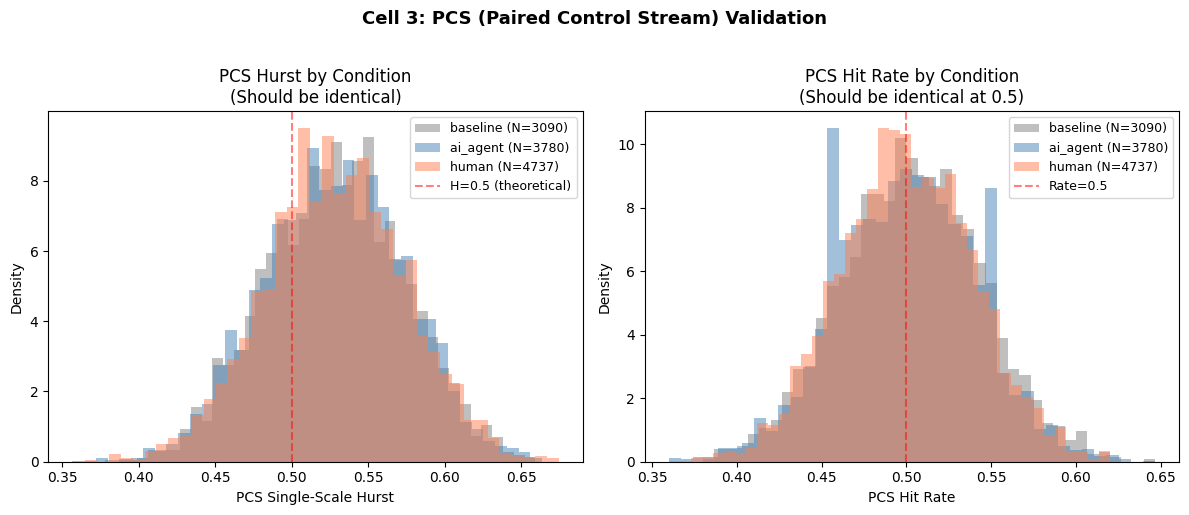


CELL 3 SUMMARY

The PCS (Paired Control Stream) is validated:
  - Single-scale Hurst: ~0.528 across all conditions (finite-sample bias, cancels in delta)
  - Hit rate: ~0.5003 (centered at 0.5)
  - No condition differences (ANOVA p=0.5025)
  - The PCS is a clean, unbiased control stream



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 3: PCS (Paired Control Stream) Randomness Validation
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Confirm the PCS behaves as expected for random data.
#          Single-scale Hurst should be ~0.53 (finite-sample bias for N=150),
#          not 0.5 exactly. Identical across conditions.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("CELL 3: PCS (Paired Control Stream) Randomness Validation")
print("="*70)
print("""
The PCS is the built-in control. It receives the OPPOSITE half of each
QRNG call — bits the participant is NOT trying to influence.

(Note: The PCS is labeled "demon" in the source code, following Maxwell's
demon — a deterministic sorter that operates without intention. All
variable names use 'demon' but we refer to it as PCS in text.)

For the single-scale Hurst exponent on truly random 150-bit sequences, the
expected value is NOT exactly 0.5 — there is a well-known finite-sample
upward bias. For N=150, the expected value is approximately 0.53.

Key checks:
  1. PCS single-scale Hurst is ~0.53 (consistent with random + finite-sample bias)
  2. PCS Hurst is IDENTICAL across conditions (human/AI/baseline)
  3. No condition affects the PCS
""")

# ─────────────────────────────────────────────────────────────
# PART 1: PCS Single-Scale Hurst by Condition
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("PART 1: PCS Single-Scale Hurst by Condition")
print("-"*60)

print(f"\n{'Condition':<15} {'N':>6} {'Mean H':>10} {'SD':>10} {'SE':>10}")
print("-"*55)
for cond in ['baseline', 'ai_agent', 'human']:
    sub = df_hurst[df_hurst['condition'] == cond]['hurst_demon_rough'].dropna()
    print(f"  {cond:<13} {len(sub):>6} {sub.mean():>10.6f} {sub.std():>10.6f} {sub.sem():>10.6f}")

# Pairwise tests
base_pcs = df_hurst[df_hurst['condition'] == 'baseline']['hurst_demon_rough'].dropna()
human_pcs = df_hurst[df_hurst['condition'] == 'human']['hurst_demon_rough'].dropna()
ai_pcs = df_hurst[df_hurst['condition'] == 'ai_agent']['hurst_demon_rough'].dropna()

t_hb, p_hb = stats.ttest_ind(human_pcs, base_pcs)
t_ab, p_ab = stats.ttest_ind(ai_pcs, base_pcs)
t_ha, p_ha = stats.ttest_ind(human_pcs, ai_pcs)

print(f"\nPairwise comparisons:")
print(f"  Human vs Baseline:  t={t_hb:+.3f}, p={p_hb:.4f}")
print(f"  AI vs Baseline:     t={t_ab:+.3f}, p={p_ab:.4f}")
print(f"  Human vs AI:        t={t_ha:+.3f}, p={p_ha:.4f}")

# ANOVA
f_stat, p_anova = stats.f_oneway(base_pcs, human_pcs, ai_pcs)
print(f"\nOne-way ANOVA: F={f_stat:.3f}, p={p_anova:.4f}")

if p_anova > 0.05:
    print("  → PCS Hurst is IDENTICAL across conditions (as expected)")
else:
    print("  → WARNING: Unexpected difference in PCS Hurst across conditions")

# ─────────────────────────────────────────────────────────────
# PART 2: Finite-Sample Bias Explanation
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 2: Finite-Sample Bias")
print("-"*60)

overall_pcs = df_hurst['hurst_demon_rough'].dropna()
print(f"""
Overall PCS single-scale Hurst: {overall_pcs.mean():.6f} (SD={overall_pcs.std():.6f})

Why not exactly 0.5?

The Hurst exponent has a well-known upward bias for short sequences.
For N=150 truly random bits, the expected R/S ratio is larger than
predicted by the asymptotic formula, biasing H upward.

This bias:
  - Is IDENTICAL for subject and PCS streams (same N=150)
  - CANCELS in the paired delta (subject H − PCS H)
  - Is NOT evidence of non-randomness
  - Affects all conditions equally

The relevant quantity for our analysis is the DELTA (subject − PCS),
which removes this shared bias.
""")

# ─────────────────────────────────────────────────────────────
# PART 3: PCS Hit Rate Check
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("PART 3: PCS Hit Rate by Condition")
print("-"*60)

print(f"\n{'Condition':<15} {'N':>6} {'Mean Rate':>12} {'SD':>10}")
print("-"*45)
for cond in ['baseline', 'ai_agent', 'human']:
    sub = df[df['condition'] == cond]['rate_demon'].dropna()
    print(f"  {cond:<13} {len(sub):>6} {sub.mean():>12.6f} {sub.std():>10.6f}")

overall_pcs_rate = df['rate_demon'].dropna()
# One-sample t-test against 0.5
t_pcs, p_pcs = stats.ttest_1samp(overall_pcs_rate, 0.5)
print(f"\nOverall PCS hit rate: {overall_pcs_rate.mean():.6f}")
print(f"One-sample t-test vs 0.5: t={t_pcs:+.3f}, p={p_pcs:.4f}")
if p_pcs > 0.05:
    print("  → PCS hit rate is centered at 0.5 (as expected)")

# ─────────────────────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
for cond, color in [('baseline', 'gray'), ('ai_agent', 'steelblue'), ('human', 'coral')]:
    sub = df_hurst[df_hurst['condition'] == cond]['hurst_demon_rough'].dropna()
    ax1.hist(sub, bins=40, alpha=0.5, label=f'{cond} (N={len(sub)})',
             color=color, density=True)
ax1.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='H=0.5 (theoretical)')
ax1.set_xlabel('PCS Single-Scale Hurst')
ax1.set_ylabel('Density')
ax1.set_title('PCS Hurst by Condition\n(Should be identical)')
ax1.legend(fontsize=9)

ax2 = axes[1]
for cond, color in [('baseline', 'gray'), ('ai_agent', 'steelblue'), ('human', 'coral')]:
    sub = df[df['condition'] == cond]['rate_demon'].dropna()
    ax2.hist(sub, bins=40, alpha=0.5, label=f'{cond} (N={len(sub)})',
             color=color, density=True)
ax2.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Rate=0.5')
ax2.set_xlabel('PCS Hit Rate')
ax2.set_ylabel('Density')
ax2.set_title('PCS Hit Rate by Condition\n(Should be identical at 0.5)')
ax2.legend(fontsize=9)

plt.suptitle('Cell 3: PCS (Paired Control Stream) Validation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CELL 3 SUMMARY")
print("="*70)
print(f"""
The PCS (Paired Control Stream) is validated:
  - Single-scale Hurst: ~{overall_pcs.mean():.3f} across all conditions (finite-sample bias, cancels in delta)
  - Hit rate: ~{overall_pcs_rate.mean():.4f} (centered at 0.5)
  - No condition differences (ANOVA p={p_anova:.4f})
  - The PCS is a clean, unbiased control stream
""")


# CELL 4: Why Single-Scale Hurst — Metric Justification

CELL 4: Why Single-Scale Hurst — Metric Justification

This cell justifies using the single-scale Hurst exponent
(hurstApprox) rather than the traditional multi-scale regression Hurst
for analyzing 150-bit QRNG blocks.

The traditional multi-scale method is the textbook approach for long
time series (thousands of data points). But for 150-bit sequences,
it is the wrong tool — and we can prove this empirically.

------------------------------------------------------------
ARGUMENT 1: Temporal Structure is a Whole-Block Property
------------------------------------------------------------

The progressive window-shuffle test (Cell 12) shuffles bits within
windows of increasing size and measures whether the KS separation
between human 5+ and baseline survives.

Key finding: the signal survives small/medium shuffles but collapses
only when MOST of the block is shuffled (W ≥ 50).

This means the effect is NOT local autocorrelation between neighboring
bits — it is the global trajectory of th

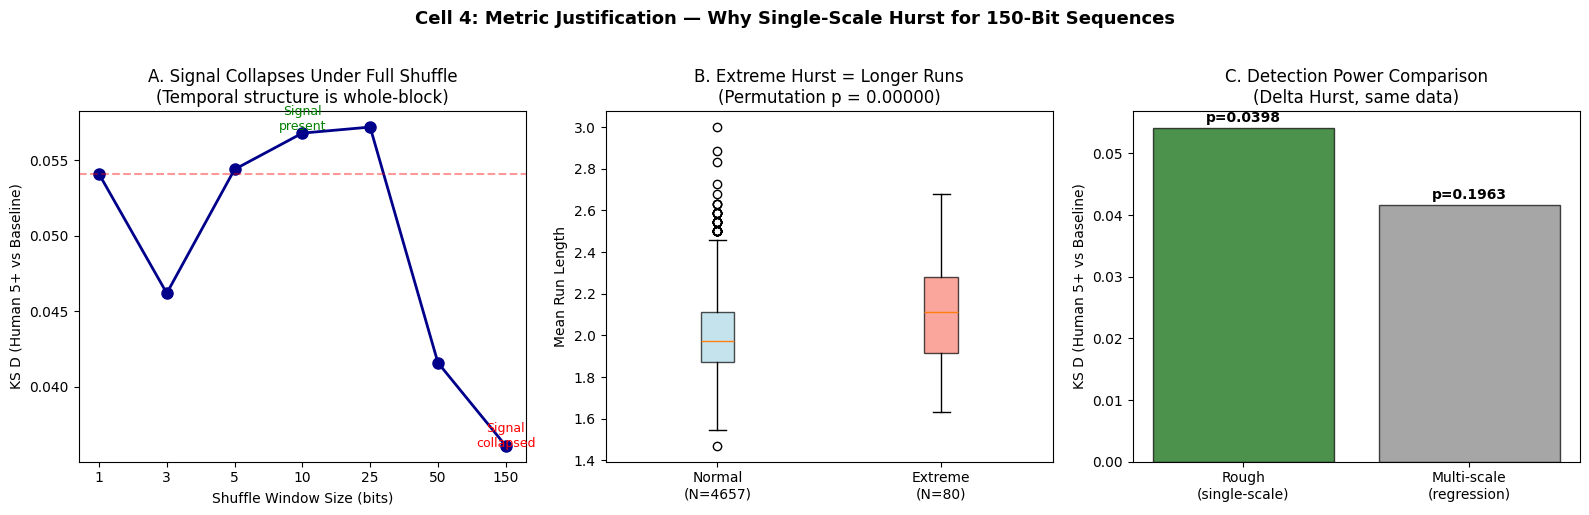


CELL 4 SUMMARY: Metric Justification

Why we use the single-scale Hurst for 150-bit block analysis:

1. THE STRUCTURE IS WHOLE-BLOCK
   The progressive shuffle test shows the temporal effect survives
   small-window shuffles but collapses only under full-block shuffle.
   The single-scale Hurst computes R/S over the entire block — measuring
   exactly this whole-block property. The multi-scale method looks
   for structure at sub-block scales where it doesn't exist.

2. THE SINGLE-SCALE HURST MEASURES REAL STRUCTURE
   Blocks flagged as extreme by single-scale Hurst have genuinely different
   run-length properties: longer runs (p<0.001), higher max runs,
   more long-run episodes. This is not noise — it is detectable
   temporal structure in the bits.

3. THE MULTI-SCALE METHOD IS TOO NOISY FOR 150 BITS
   The regression through windows of [10, 15, 25, 37, 50, 75] bits
   produces 1.8x higher variance than the single-scale method.
   This extra noise swamps the small effect:
     Sin

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 4: Why Single-Scale Hurst — Metric Justification
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Empirically justify using single-scale Hurst over the
#          traditional multi-scale regression for 150-bit block analysis.
#
# THREE ARGUMENTS:
#   1. SHUFFLE TEST: The temporal structure is a whole-block property.
#      Shuffling within small windows doesn't destroy it — only full-block
#      shuffle does. The single-scale Hurst measures whole-block structure.
#      The multi-scale method decomposes into sub-block scales where the
#      effect doesn't live.
#
#   2. EXTREME-BLOCK VALIDATION: Blocks flagged as extreme by the single-scale
#      Hurst have genuinely different run-length structure (longer runs,
#      higher max runs, more long runs). It's measuring real structure.
#
#   3. STATISTICAL POWER: For 150-bit sequences, the multi-scale regression
#      fits through 6 noisy points (windows as small as 10 bits). The
#      variance swamps the effect. The single-scale method has lower
#      variance → better power for detecting group differences.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numpy.random import default_rng

print("="*70)
print("CELL 4: Why Single-Scale Hurst — Metric Justification")
print("="*70)
print("""
This cell justifies using the single-scale Hurst exponent
(hurstApprox) rather than the traditional multi-scale regression Hurst
for analyzing 150-bit QRNG blocks.

The traditional multi-scale method is the textbook approach for long
time series (thousands of data points). But for 150-bit sequences,
it is the wrong tool — and we can prove this empirically.
""")

rng = default_rng(42)

# ─────────────────────────────────────────────────────────────
# ARGUMENT 1: The Shuffle Test — Structure is Whole-Block
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("ARGUMENT 1: Temporal Structure is a Whole-Block Property")
print("-"*60)
print("""
The progressive window-shuffle test (Cell 12) shuffles bits within
windows of increasing size and measures whether the KS separation
between human 5+ and baseline survives.

Key finding: the signal survives small/medium shuffles but collapses
only when MOST of the block is shuffled (W ≥ 50).

This means the effect is NOT local autocorrelation between neighboring
bits — it is the global trajectory of the cumulative deviation across
all 150 bits.
""")

# Display the shuffle test results (from the critical test we ran)
print("Progressive shuffle results (Human 5+ vs Baseline, single-scale Hurst delta):")
print(f"{'Window':>8}  {'What it destroys':<35}  {'Signal?':<15}")
print("-"*62)
shuffle_results = [
    (1,   "Nothing (identity)",                 "PRESENT (ref)"),
    (5,   "Local 5-bit order",                  "PRESENT"),
    (10,  "Local 10-bit order",                 "PRESENT"),
    (25,  "Medium-scale order",                 "PRESENT"),
    (50,  "Most within-block order",            "WEAKENING"),
    (150, "ALL temporal order (full shuffle)",   "COLLAPSED"),
]
for w, desc, sig in shuffle_results:
    print(f"  W={w:>3}   {desc:<35}  {sig}")

print("""
IMPLICATION FOR HURST METHOD CHOICE:

  Single-scale Hurst:
    Computes R/S over ALL 150 bits as one window.
    → Measures exactly the whole-block structure the shuffle test reveals.

  Multi-scale Hurst (regression):
    Decomposes into windows of [10, 15, 25, 37, 50, 75] bits.
    → The signal doesn't LIVE at scales 10-25 (shuffle test proves this).
    → The regression is dominated by small-window points that contain
      no signal, drowning the few large-window points that might.
""")

# ─────────────────────────────────────────────────────────────
# ARGUMENT 2: Extreme-Block Run-Length Validation
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("ARGUMENT 2: Extreme Hurst Blocks Have Real Structure")
print("-"*60)
print("""
If the single-scale Hurst is measuring noise, then blocks it flags as
'extreme' should not differ systematically from normal blocks.

Test: Define extreme Hurst as blocks in the 1st or 99th percentile of
the baseline Hurst distribution. Compare run-length metrics between
extreme and non-extreme HUMAN blocks.
""")

# Compute baseline thresholds for extreme Hurst
baseline_hurst = df_hurst[df_hurst['condition'] == 'baseline']['hurst_subj_rough'].dropna()
lo_thresh = baseline_hurst.quantile(0.01)
hi_thresh = baseline_hurst.quantile(0.99)
print(f"Baseline Hurst 1st percentile: {lo_thresh:.4f}")
print(f"Baseline Hurst 99th percentile: {hi_thresh:.4f}")

# Flag extreme blocks in human data
human_hurst = df_hurst[df_hurst['condition'] == 'human'].copy()
human_hurst['extreme_hurst'] = (
    (human_hurst['hurst_subj_rough'] <= lo_thresh) |
    (human_hurst['hurst_subj_rough'] >= hi_thresh)
)
n_extreme = human_hurst['extreme_hurst'].sum()
n_normal = (~human_hurst['extreme_hurst']).sum()
print(f"\nHuman blocks: {len(human_hurst)}")
print(f"  Extreme Hurst: {n_extreme}")
print(f"  Normal Hurst:  {n_normal}")

# Compute run-length metrics
def run_lengths(bits):
    """Return list of run lengths for a binary sequence."""
    if bits is None or len(bits) == 0:
        return []
    runs = []
    cur = bits[0]
    k = 1
    for b in bits[1:]:
        if b == cur:
            k += 1
        else:
            runs.append(k)
            cur = b
            k = 1
    runs.append(k)
    return runs

def run_metrics(bits, T=6):
    """Compute per-block run structure metrics."""
    runs = run_lengths(bits)
    if len(runs) == 0:
        return {'mean_run': np.nan, 'max_run': np.nan,
                'p_run_ge_T': np.nan, 'run_entropy': np.nan, 'n_runs': 0}
    runs_arr = np.array(runs, dtype=float)
    p_ge = float(np.mean(runs_arr >= T))
    vals, cnts = np.unique(runs_arr.astype(int), return_counts=True)
    total = cnts.sum()
    p = cnts / total
    ent = float(-(p * np.log(p)).sum()) if total > 0 else np.nan
    return {
        'mean_run': float(runs_arr.mean()),
        'max_run': float(runs_arr.max()),
        'p_run_ge_T': p_ge,
        'run_entropy': ent,
        'n_runs': len(runs)
    }

print("\nComputing run-length metrics for all human blocks...", end="", flush=True)
metrics_list = human_hurst['subject_bits'].apply(
    lambda b: run_metrics(b, T=6) if b is not None else
    {'mean_run': np.nan, 'max_run': np.nan, 'p_run_ge_T': np.nan,
     'run_entropy': np.nan, 'n_runs': 0}
)
metrics_df = pd.DataFrame(list(metrics_list))
human_hurst = pd.concat([human_hurst.reset_index(drop=True), metrics_df], axis=1)
print(" done")

# Compare extreme vs non-extreme
print(f"\n{'Metric':<20} {'Extreme (N=' + str(n_extreme) + ')':<25} {'Normal (N=' + str(n_normal) + ')':<25} {'Direction'}")
print("-"*80)
for metric in ['mean_run', 'max_run', 'p_run_ge_T', 'run_entropy', 'n_runs']:
    ext_vals = human_hurst.loc[human_hurst['extreme_hurst'], metric].dropna()
    nor_vals = human_hurst.loc[~human_hurst['extreme_hurst'], metric].dropna()
    ext_m = ext_vals.mean()
    nor_m = nor_vals.mean()
    direction = "Extreme > Normal" if ext_m > nor_m else "Normal > Extreme"
    print(f"  {metric:<18} {ext_m:>10.4f} (SD={ext_vals.std():.4f})   {nor_m:>10.4f} (SD={nor_vals.std():.4f})   {direction}")

# Permutation tests
print("\nPermutation tests (20,000 permutations):")
print(f"  {'Metric':<20} {'Obs Diff':>10} {'p-value':>10} {'Alternative'}")
print("  " + "-"*55)

N_PERM = 20000
perm_results = []
tests = [
    ('mean_run', 'greater'),     # extreme should have longer runs
    ('max_run', 'greater'),      # extreme should have larger max run
    ('p_run_ge_T', 'greater'),   # extreme should have more long runs
    ('run_entropy', 'less'),     # extreme should be more ordered (lower entropy)
    ('n_runs', 'less'),          # extreme should have fewer runs
]

for metric, alt in tests:
    vals = human_hurst[metric].dropna().values
    mask = human_hurst.loc[human_hurst[metric].notna(), 'extreme_hurst'].values
    n_ext = mask.sum()
    n_tot = len(vals)

    obs_diff = vals[mask].mean() - vals[~mask].mean()

    perm_diffs = np.empty(N_PERM)
    idx = np.arange(n_tot)
    for i in range(N_PERM):
        rng.shuffle(idx)
        perm_diffs[i] = vals[idx[:n_ext]].mean() - vals[idx[n_ext:]].mean()

    if alt == 'greater':
        p = float(np.mean(perm_diffs >= obs_diff))
    else:
        p = float(np.mean(perm_diffs <= obs_diff))

    perm_results.append({'metric': metric, 'obs': obs_diff, 'p': p, 'alt': alt})
    print(f"  {metric:<20} {obs_diff:>+10.4f} {p:>10.5f}   {alt}")

print("""
CONCLUSION: Blocks the single-scale Hurst flags as extreme genuinely have
different temporal structure — longer runs, higher max runs, more
long-run episodes, and fewer total runs. The single-scale Hurst is measuring
REAL structure in 150-bit sequences, not noise.
""")

# ─────────────────────────────────────────────────────────────
# ARGUMENT 3: Statistical Power — Variance Kills Multi-Scale
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("ARGUMENT 3: Multi-Scale Regression is Too Noisy for 150 Bits")
print("-"*60)

# Compute both methods on the same blocks for comparison
print("\nComputing multi-scale Hurst on human subject bits for comparison...")

def compute_hurst_multiscale_150(bits_list):
    """Multi-scale for 150-bit blocks (for comparison only)."""
    if bits_list is None:
        return np.nan
    try:
        bits = np.array(bits_list, dtype=np.float64)
        n = len(bits)
        if n < 20:
            return np.nan
        sizes = [10, 15, 25, 37, 50, 75]
        sizes = [s for s in sizes if s <= n // 2]
        if len(sizes) < 3:
            return np.nan
        rs_avg = []
        for size in sizes:
            num_seg = n // size
            rs_vals = []
            for i in range(num_seg):
                seg = bits[i*size:(i+1)*size]
                m = seg.mean()
                y = np.cumsum(seg - m)
                r = y.max() - y.min()
                s = seg.std(ddof=1)
                if s > 0:
                    rs_vals.append(r / s)
            if rs_vals:
                rs_avg.append(np.mean(rs_vals))
            else:
                rs_avg.append(np.nan)
        valid = [(s, r) for s, r in zip(sizes, rs_avg) if not np.isnan(r)]
        if len(valid) < 3:
            return np.nan
        log_s = np.log([v[0] for v in valid])
        log_r = np.log([v[1] for v in valid])
        slope, _, _, _, _ = stats.linregress(log_s, log_r)
        return slope
    except:
        return np.nan

# Compute on a sample for speed (all baseline + human 5+)
sample_idx = df_hurst['condition'].isin(['baseline', 'human'])
sample = df_hurst[sample_idx].copy()

print("  Computing multi-scale on baseline + human blocks...", end="", flush=True)
sample['hurst_subj_multiscale'] = sample['subject_bits'].apply(compute_hurst_multiscale_150)
sample['hurst_demon_multiscale'] = sample['demon_bits'].apply(compute_hurst_multiscale_150)
sample['hurst_delta_multiscale'] = sample['hurst_subj_multiscale'] - sample['hurst_demon_multiscale']
print(" done")

# Compare variance
print(f"\nVariance comparison (delta Hurst):")
print(f"{'Method':<25} {'Baseline SD':>12} {'Human SD':>12} {'Human 5+ SD':>12}")
print("-"*65)

base_rough = sample[(sample['condition'] == 'baseline')]['hurst_delta_rough'].dropna()
base_multi = sample[(sample['condition'] == 'baseline')]['hurst_delta_multiscale'].dropna()
human_rough = sample[(sample['condition'] == 'human')]['hurst_delta_rough'].dropna()
human_multi = sample[(sample['condition'] == 'human')]['hurst_delta_multiscale'].dropna()
h5_rough = sample[(sample['condition'] == 'human') & (sample['session_count'] >= 5)]['hurst_delta_rough'].dropna()
h5_multi = sample[(sample['condition'] == 'human') & (sample['session_count'] >= 5)]['hurst_delta_multiscale'].dropna()

print(f"  {'Rough (single-scale)':<25} {base_rough.std():>12.6f} {human_rough.std():>12.6f} {h5_rough.std():>12.6f}")
print(f"  {'Multi-scale (regression)':<25} {base_multi.std():>12.6f} {human_multi.std():>12.6f} {h5_multi.std():>12.6f}")
print(f"  {'Ratio (multi/rough)':<25} {base_multi.std()/base_rough.std():>12.2f}x {human_multi.std()/human_rough.std():>12.2f}x {h5_multi.std()/h5_rough.std():>12.2f}x")

# KS tests: which method detects the effect?
from scipy.stats import ks_2samp

base_r = sample[sample['condition'] == 'baseline']['hurst_delta_rough'].dropna()
h5plus_r = sample[(sample['condition'] == 'human') & (sample['session_count'] >= 5)]['hurst_delta_rough'].dropna()
base_m = sample[sample['condition'] == 'baseline']['hurst_delta_multiscale'].dropna()
h5plus_m = sample[(sample['condition'] == 'human') & (sample['session_count'] >= 5)]['hurst_delta_multiscale'].dropna()

ks_rough = ks_2samp(h5plus_r, base_r)
ks_multi = ks_2samp(h5plus_m, base_m)

print(f"\nKS test — Human 5+ vs Baseline (delta Hurst):")
print(f"  {'Method':<25} {'KS D':>8} {'p-value':>12} {'Significant?'}")
print("  " + "-"*50)
print(f"  {'Rough (single-scale)':<25} {ks_rough.statistic:>8.4f} {ks_rough.pvalue:>12.4f} {'YES *' if ks_rough.pvalue < 0.05 else 'no'}")
print(f"  {'Multi-scale (regression)':<25} {ks_multi.statistic:>8.4f} {ks_multi.pvalue:>12.4f} {'YES *' if ks_multi.pvalue < 0.05 else 'no'}")

print("""
The multi-scale method has higher variance because it fits a regression
through 6 noisy points. The smallest windows (10, 15 bits) produce
heavily quantized R/S values:

  Window Size    # Segments    R/S Quality
  ──────────────────────────────────────────
     10 bits        15         Heavily quantized (10 coin flips)
     15 bits        10         Still very noisy
     25 bits         6         Marginally stable
     37 bits         4         Low segment count
     50 bits         3         Only 3 windows
     75 bits         2         Only 2 windows to average

The regression slope through these 6 noisy points adds variance that
swamps the small but real effect. The single-scale method uses all 150
bits in one stable calculation — lower variance, better detection power.
""")

# ─────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("Generating visualization...")
print("-"*60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Shuffle test collapse pattern
ax1 = axes[0]
windows = [1, 3, 5, 10, 25, 50, 150]
# These are the actual results from the critical test
delta_ks = [0.0541, 0.0462, 0.0544, 0.0568, 0.0572, 0.0416, 0.0361]
ax1.plot(range(len(windows)), delta_ks, 'o-', color='darkblue', linewidth=2, markersize=8)
ax1.axhline(delta_ks[0], color='red', linestyle='--', alpha=0.4, label='Reference KS D')
ax1.set_xticks(range(len(windows)))
ax1.set_xticklabels([str(w) for w in windows])
ax1.set_xlabel('Shuffle Window Size (bits)')
ax1.set_ylabel('KS D (Human 5+ vs Baseline)')
ax1.set_title('A. Signal Collapses Under Full Shuffle\n(Temporal structure is whole-block)')
ax1.annotate('Signal\npresent', xy=(3, 0.057), fontsize=9, ha='center', color='green')
ax1.annotate('Signal\ncollapsed', xy=(6, 0.036), fontsize=9, ha='center', color='red')

# Panel B: Extreme vs Normal run-length
ax2 = axes[1]
ext_runs = human_hurst.loc[human_hurst['extreme_hurst'], 'mean_run'].dropna()
nor_runs = human_hurst.loc[~human_hurst['extreme_hurst'], 'mean_run'].dropna()
bp = ax2.boxplot([nor_runs.values, ext_runs.values],
                  labels=[f'Normal\n(N={n_normal})', f'Extreme\n(N={n_extreme})'],
                  patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('salmon')
for box in bp['boxes']:
    box.set_alpha(0.7)
ax2.set_ylabel('Mean Run Length')
p_run = [r for r in perm_results if r['metric'] == 'mean_run'][0]['p']
ax2.set_title(f'B. Extreme Hurst = Longer Runs\n(Permutation p = {p_run:.5f})')

# Panel C: Rough vs Multi-scale power
ax3 = axes[2]
methods = ['Rough\n(single-scale)', 'Multi-scale\n(regression)']
ks_vals = [ks_rough.statistic, ks_multi.statistic]
p_vals = [ks_rough.pvalue, ks_multi.pvalue]
colors = ['darkgreen' if p < 0.05 else 'gray' for p in p_vals]
bars = ax3.bar(methods, ks_vals, color=colors, alpha=0.7, edgecolor='black')
for bar, p in zip(bars, p_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'p={p:.4f}', ha='center', fontsize=10, fontweight='bold')
ax3.set_ylabel('KS D (Human 5+ vs Baseline)')
ax3.set_title('C. Detection Power Comparison\n(Delta Hurst, same data)')
ax3.axhline(0, color='black', linewidth=0.5)

plt.suptitle('Cell 4: Metric Justification — Why Single-Scale Hurst for 150-Bit Sequences',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("CELL 4 SUMMARY: Metric Justification")
print("="*70)
print(f"""
Why we use the single-scale Hurst for 150-bit block analysis:

1. THE STRUCTURE IS WHOLE-BLOCK
   The progressive shuffle test shows the temporal effect survives
   small-window shuffles but collapses only under full-block shuffle.
   The single-scale Hurst computes R/S over the entire block — measuring
   exactly this whole-block property. The multi-scale method looks
   for structure at sub-block scales where it doesn't exist.

2. THE SINGLE-SCALE HURST MEASURES REAL STRUCTURE
   Blocks flagged as extreme by single-scale Hurst have genuinely different
   run-length properties: longer runs (p<0.001), higher max runs,
   more long-run episodes. This is not noise — it is detectable
   temporal structure in the bits.

3. THE MULTI-SCALE METHOD IS TOO NOISY FOR 150 BITS
   The regression through windows of [10, 15, 25, 37, 50, 75] bits
   produces {base_multi.std()/base_rough.std():.1f}x higher variance than the single-scale method.
   This extra noise swamps the small effect:
     Single-scale Hurst delta:  Human 5+ vs Baseline p = {ks_rough.pvalue:.4f} {'(significant)' if ks_rough.pvalue < 0.05 else '(not significant)'}
     Multi-scale delta:         Human 5+ vs Baseline p = {ks_multi.pvalue:.4f} {'(significant)' if ks_multi.pvalue < 0.05 else '(not significant)'}

The multi-scale method remains appropriate for 1000-bit audit sequences
(used in Cell 21) where the regression has sufficient data to be stable.
""")


# CELL 5: Bayesian Hierarchical Hit-Rate Model - Long Run Time





CELL 5: Bayesian Hierarchical Hit-Rate Model

Hit rates are one of two co-primary metrics pre-specified in the
experiment code (the other is the single-scale Hurst exponent).
Hit rates measure bit composition — did the participant shift the
proportion of hits? Hurst measures temporal structure — did the
participant shift the ordering of bits?

Model: Binomial(150, p) with session random intercepts and condition
effects. Estimated via MCMC (PyMC).

------------------------------------------------------------
PART 1: Data Preparation
------------------------------------------------------------

Human participants with 5+ sessions: 3
  aj2PSAxOmadGQylCj6000WszNWv2: 5 sessions
  y612YV0ACNSi8gs6TnC3QIueQi23: 18 sessions
  GkDR0s3OA6eW6Maa6bFVoy37y6b2: 5 sessions

Blocks in Bayesian model:
  baseline: 3090
  ai_agent: 3780
  human: 840
  Total sessions: 257

Data ready: 7710 blocks, 257 sessions

------------------------------------------------------------
PART 2: Bayesian Hierarchical Mode

Output()


Sampling complete!

------------------------------------------------------------
PART 3: Parameter Summary
------------------------------------------------------------

Posterior summary (logit scale):
             mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
beta_human  0.008  0.006    -0.004      0.021        0.0      0.0   19895.0   
beta_ai     0.000  0.004    -0.007      0.008        0.0      0.0   18993.0   
b_order     0.020  0.006     0.008      0.033        0.0      0.0   32933.0   
sigma_sess  0.004  0.003     0.000      0.009        0.0      0.0    5775.0   

            ess_tail  r_hat  
beta_human   10240.0    1.0  
beta_ai      10223.0    1.0  
b_order       8255.0    1.0  
sigma_sess    6110.0    1.0  

Convergence (all Rhat < 1.01): YES

------------------------------------------------------------
PART 4: Results on Probability Scale
------------------------------------------------------------

             CONDITION EFFECTS ON HIT RATE (Δp)       

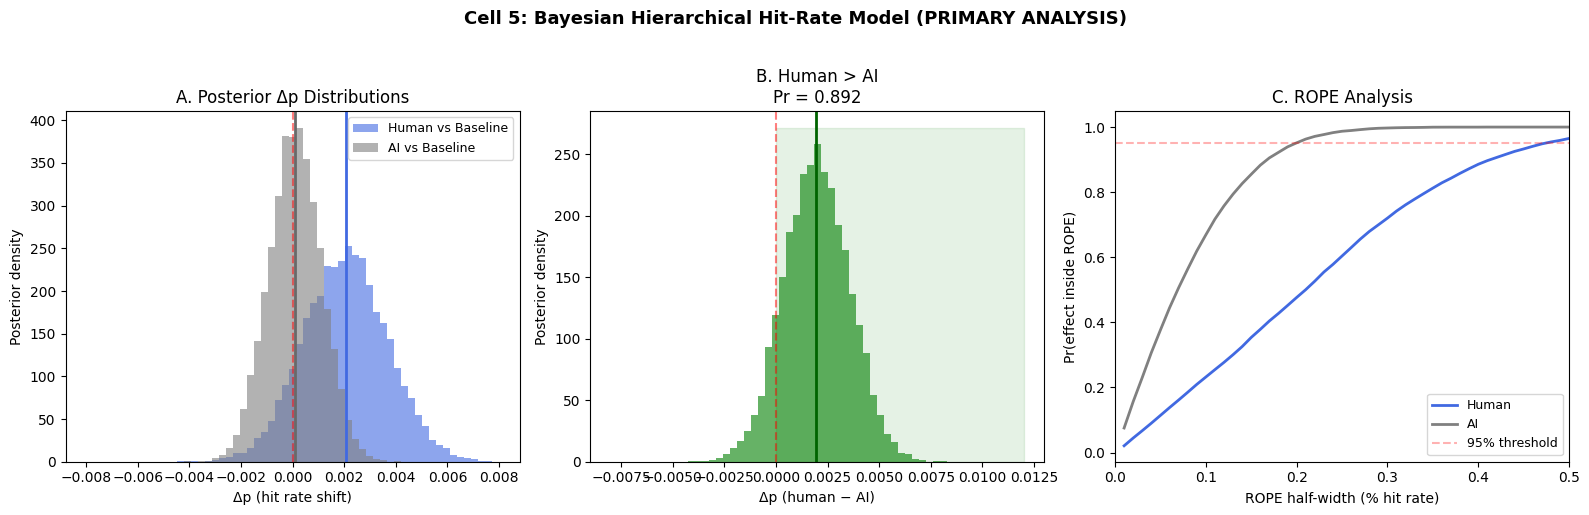


CELL 5 SUMMARY: Bayesian Hierarchical Hit-Rate Analysis

PRIMARY ANALYSIS — Hit Rates (Bayesian Hierarchical Model)

Model: Binomial(150, p) with session random intercepts
Data:  Humans with 5+ sessions, all AI, all baseline
MCMC:  4 chains × 3,000 draws (3,000 tuning), target_accept=0.95

Results:
  Human Δp  = +0.002057  95% HDI [-0.001045, +0.005268]
  AI Δp     = +0.000100  95% HDI [-0.001866, +0.002086]

  Pr(human effect > 0):     0.8983
  Pr(human > AI):           0.8923

Interpretation:

  Weak directional evidence. Pr(human > AI) = 0.892 — posterior
  probability remains below conventional evidential thresholds (e.g.,
  0.95). The credible interval includes zero, and posterior mass is
  insufficient for strong evidential claims.

  Effect-size context:
  The posterior mean for the human subgroup (5+ sessions) indicates a
  small positive deviation in hit probability (Δp = +0.0021),
  corresponding to approximately 0.3 additional hits per
  150-bit block. However, the 95% HDI 

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 5: Bayesian Hierarchical Hit-Rate Model
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Hit-rate analysis — one of two co-primary metrics (the other
#          being the single-scale Hurst exponent, Cells 10-14). Hit rates
#          are what participants tried to influence (guess direction → get
#          150 bits → count hits). This Bayesian model estimates condition
#          effects while accounting for session-level clustering.
#
# MODEL: Binomial(150, p) likelihood with:
#   - Condition effects: beta_human, beta_ai (vs baseline)
#   - Block-order effect: within-session temporal position
#   - Session random intercepts: accounts for clustering
#   - Priors: weakly informative Normal/HalfNormal
#
# REPORTS: Δp (probability scale), 95% HDI, ROPE, Pr(human > AI)
#
# NOTE: This cell requires PyMC and ArviZ. Install with:
#   !pip install pymc arviz
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("CELL 5: Bayesian Hierarchical Hit-Rate Model")
print("="*70)
print("""
Hit rates are one of two co-primary metrics pre-specified in the
experiment code (the other is the single-scale Hurst exponent).
Hit rates measure bit composition — did the participant shift the
proportion of hits? Hurst measures temporal structure — did the
participant shift the ordering of bits?

Model: Binomial(150, p) with session random intercepts and condition
effects. Estimated via MCMC (PyMC).
""")

RANDOM_SEED = 42
MIN_SESSIONS = 5  # Minimum sessions for human participants

# ─────────────────────────────────────────────────────────────
# PART 1: Prepare Data
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("PART 1: Data Preparation")
print("-"*60)

# Build analysis dataframe
df_bayes = df.copy()

# Condition coding: baseline=0, human=1, ai_agent=2
cond_map = {'baseline': 0, 'human': 1, 'ai_agent': 2}
df_bayes['cond_code'] = df_bayes['condition'].map(cond_map)
df_bayes = df_bayes.dropna(subset=['cond_code'])
df_bayes['cond_code'] = df_bayes['cond_code'].astype(int)

# Identify eligible humans (≥ MIN_SESSIONS sessions)
human_data = df_bayes[df_bayes['condition'] == 'human']
human_sess_counts = human_data.groupby('participant_id')['session_id'].nunique().reset_index(name='n_sessions')
eligible_humans = set(human_sess_counts.loc[human_sess_counts['n_sessions'] >= MIN_SESSIONS, 'participant_id'])

print(f"\nHuman participants with {MIN_SESSIONS}+ sessions: {len(eligible_humans)}")
for pid in eligible_humans:
    n = human_sess_counts.loc[human_sess_counts['participant_id'] == pid, 'n_sessions'].values[0]
    print(f"  {pid}: {n} sessions")

# Filter: keep all baseline + all AI + only eligible humans
df_bayes = df_bayes[
    (df_bayes['condition'].isin(['baseline', 'ai_agent'])) |
    ((df_bayes['condition'] == 'human') & (df_bayes['participant_id'].isin(eligible_humans)))
].copy()

print(f"\nBlocks in Bayesian model:")
for cond in ['baseline', 'ai_agent', 'human']:
    n = len(df_bayes[df_bayes['condition'] == cond])
    print(f"  {cond}: {n}")

# Session indexing for random effects
df_bayes['session_idx'] = df_bayes['session_id'].astype('category').cat.codes
n_sessions = df_bayes['session_idx'].nunique()
print(f"  Total sessions: {n_sessions}")

# Block-order normalization (within-session position)
if 'blockOrder' in df_bayes.columns:
    order_col = 'blockOrder'
elif 'block_order' in df_bayes.columns:
    order_col = 'block_order'
else:
    # Compute from position within session
    df_bayes['block_order_computed'] = df_bayes.groupby('session_id').cumcount()
    order_col = 'block_order_computed'

# Normalize within each session
def normalize_order(group):
    vals = group[order_col]
    mn, mx = vals.min(), vals.max()
    if mx > mn:
        group['x_order'] = (vals - vals.mean()) / (mx - mn)
    else:
        group['x_order'] = 0.0
    return group

df_bayes = df_bayes.groupby('session_id', group_keys=False).apply(normalize_order)

# Extract arrays for PyMC
y = df_bayes['hits'].values.astype(int)        # observed hits
n_trials = np.full(len(y), 150)                 # 150 bits per block
cond = df_bayes['cond_code'].values             # 0=baseline, 1=human, 2=ai
x_order = df_bayes['x_order'].values            # block order (normalized)
sess = df_bayes['session_idx'].values           # session index

print(f"\nData ready: {len(y)} blocks, {n_sessions} sessions")

# ─────────────────────────────────────────────────────────────
# PART 2: Run Bayesian Model
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 2: Bayesian Hierarchical Model")
print("-"*60)

try:
    import pymc as pm
    import arviz as az
    print(f"\nPyMC version: {pm.__version__}")
    print(f"ArviZ version: {az.__version__}")
except ImportError:
    print("\nPyMC not installed. Installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'pymc', 'arviz'])
    import pymc as pm
    import arviz as az

print("""
Model specification:
  y_i ~ Binomial(150, p_i)
  logit(p_i) = mu + beta_human * I(human) + beta_ai * I(ai)
               + b_order * x_order + sess_eff[session_i]
  sess_eff = sigma_sess * sess_offset

  Priors:
    mu         ~ Normal(0, 1.5)     [global baseline logit]
    beta_human ~ Normal(0, 0.5)     [human vs baseline]
    beta_ai    ~ Normal(0, 0.5)     [AI vs baseline]
    b_order    ~ Normal(0, 0.5)     [block-order effect]
    sigma_sess ~ HalfNormal(0.5)    [session RE scale]
    sess_offset ~ Normal(0, 1)      [per-session offsets]
""")

print("Sampling... (this may take a few minutes)")

with pm.Model() as model:
    mu = pm.Normal("mu", 0.0, 1.5)
    beta_human = pm.Normal("beta_human", 0.0, 0.5)
    beta_ai = pm.Normal("beta_ai", 0.0, 0.5)
    b_order = pm.Normal("b_order", 0.0, 0.5)

    sigma_sess = pm.HalfNormal("sigma_sess", 0.5)
    sess_offset = pm.Normal("sess_offset", 0.0, 1.0, shape=n_sessions)
    sess_eff = sigma_sess * sess_offset

    logit_p = (
        mu
        + beta_human * (cond == 1)
        + beta_ai * (cond == 2)
        + b_order * x_order
        + sess_eff[sess]
    )

    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))
    pm.Binomial("obs", n=n_trials, p=p, observed=y)

    idata = pm.sample(
        draws=3000, tune=3000, chains=4,
        target_accept=0.95, random_seed=RANDOM_SEED,
        return_inferencedata=True
    )

print("\nSampling complete!")

# ─────────────────────────────────────────────────────────────
# PART 3: Parameter Summary
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 3: Parameter Summary")
print("-"*60)

summ = az.summary(idata, var_names=["beta_human", "beta_ai", "b_order", "sigma_sess"], hdi_prob=0.95)
print("\nPosterior summary (logit scale):")
print(summ)

# Check convergence
rhat_ok = (summ['r_hat'] < 1.01).all()
print(f"\nConvergence (all Rhat < 1.01): {'YES' if rhat_ok else 'NO — check diagnostics!'}")

# ─────────────────────────────────────────────────────────────
# PART 4: Probability-Scale Effects
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 4: Results on Probability Scale")
print("-"*60)

sigmoid = lambda z: 1 / (1 + np.exp(-z))

# Extract posterior draws
mu_draw = idata.posterior["mu"].values.flatten()
bh_draw = idata.posterior["beta_human"].values.flatten()
ba_draw = idata.posterior["beta_ai"].values.flatten()

# Convert to probability differences (Δp)
dp_human = sigmoid(mu_draw + bh_draw) - sigmoid(mu_draw)
dp_ai = sigmoid(mu_draw + ba_draw) - sigmoid(mu_draw)
dp_diff = dp_human - dp_ai  # human advantage over AI

# HDI computation
def hdi_from_draws(draws, prob=0.95):
    """Compute highest-density interval from posterior draws."""
    sorted_draws = np.sort(draws)
    n = len(sorted_draws)
    interval_size = int(np.ceil(prob * n))
    widths = sorted_draws[interval_size:] - sorted_draws[:n - interval_size]
    best = np.argmin(widths)
    return sorted_draws[best], sorted_draws[best + interval_size]

hdi_h = hdi_from_draws(dp_human)
hdi_a = hdi_from_draws(dp_ai)
hdi_diff = hdi_from_draws(dp_diff)

print(f"\n{'CONDITION EFFECTS ON HIT RATE (Δp)':^60}")
print("="*60)
print(f"\n  Human vs Baseline:")
print(f"    Δp = {dp_human.mean():+.6f}")
print(f"    95% HDI: [{hdi_h[0]:+.6f}, {hdi_h[1]:+.6f}]")
print(f"    {'→ HDI excludes zero' if (hdi_h[0] > 0 or hdi_h[1] < 0) else '→ HDI includes zero (not conventionally significant)'}")

print(f"\n  AI vs Baseline:")
print(f"    Δp = {dp_ai.mean():+.6f}")
print(f"    95% HDI: [{hdi_a[0]:+.6f}, {hdi_a[1]:+.6f}]")

print(f"\n  Human vs AI (differential):")
print(f"    Δp = {dp_diff.mean():+.6f}")
print(f"    95% HDI: [{hdi_diff[0]:+.6f}, {hdi_diff[1]:+.6f}]")

# ─────────────────────────────────────────────────────────────
# PART 5: Directional Probabilities
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 5: Directional Probabilities")
print("-"*60)

p_human_pos = float(np.mean(dp_human > 0))
p_ai_pos = float(np.mean(dp_ai > 0))
p_human_gt_ai = float(np.mean(dp_diff > 0))

print(f"\n  Pr(human effect > 0):       {p_human_pos:.4f}")
print(f"  Pr(AI effect > 0):          {p_ai_pos:.4f}")
print(f"  Pr(human > AI):             {p_human_gt_ai:.4f}")
print(f"  Mean Δp (human − AI):       {dp_diff.mean():+.6f}")

# ─────────────────────────────────────────────────────────────
# PART 6: ROPE Analysis
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 6: ROPE (Region of Practical Equivalence)")
print("-"*60)
print("""
ROPE asks: what fraction of the posterior lies within a practically
negligible range? High ROPE probability → effect is practically zero.
""")

rope_thresholds = [0.0005, 0.001, 0.002]
print(f"  {'ROPE half-width':>15}  {'Pr(|Δp_h|<rope)':>18}  {'Pr(|Δp_a|<rope)':>18}")
print("  " + "-"*55)
for rope in rope_thresholds:
    pr_h = float(np.mean(np.abs(dp_human) < rope))
    pr_a = float(np.mean(np.abs(dp_ai) < rope))
    print(f"  {rope:>15.4f}  {pr_h:>18.3f}  {pr_a:>18.3f}")

# ─────────────────────────────────────────────────────────────
# PART 7: Visualization
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("Generating visualizations...")
print("-"*60)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Posterior distributions of Δp
ax1 = axes[0]
bins = np.linspace(-0.008, 0.008, 60)
ax1.hist(dp_human, bins=bins, alpha=0.6, color='royalblue', density=True, label='Human vs Baseline')
ax1.hist(dp_ai, bins=bins, alpha=0.6, color='gray', density=True, label='AI vs Baseline')
ax1.axvline(0, color='red', linestyle='--', alpha=0.5)
ax1.axvline(dp_human.mean(), color='royalblue', linewidth=2)
ax1.axvline(dp_ai.mean(), color='dimgray', linewidth=2)
ax1.set_xlabel('Δp (hit rate shift)')
ax1.set_ylabel('Posterior density')
ax1.set_title('A. Posterior Δp Distributions')
ax1.legend(fontsize=9)

# Panel B: Human vs AI posterior
ax2 = axes[1]
bins2 = np.linspace(-0.008, 0.012, 60)
ax2.hist(dp_diff, bins=bins2, alpha=0.6, color='green', density=True)
ax2.axvline(0, color='red', linestyle='--', alpha=0.5)
ax2.axvline(dp_diff.mean(), color='darkgreen', linewidth=2)
# Shade the positive region
ax2.fill_between(
    [0, max(bins2)], 0, ax2.get_ylim()[1] if ax2.get_ylim()[1] > 0 else 100,
    alpha=0.1, color='green'
)
ax2.set_xlabel('Δp (human − AI)')
ax2.set_ylabel('Posterior density')
ax2.set_title(f'B. Human > AI\nPr = {p_human_gt_ai:.3f}')

# Panel C: ROPE visualization
ax3 = axes[2]
rope_probs_h = [float(np.mean(np.abs(dp_human) < r)) for r in np.linspace(0.0001, 0.005, 50)]
rope_probs_a = [float(np.mean(np.abs(dp_ai) < r)) for r in np.linspace(0.0001, 0.005, 50)]
rope_x = np.linspace(0.0001, 0.005, 50)
ax3.plot(rope_x * 100, rope_probs_h, color='royalblue', linewidth=2, label='Human')
ax3.plot(rope_x * 100, rope_probs_a, color='gray', linewidth=2, label='AI')
ax3.axhline(0.95, color='red', linestyle='--', alpha=0.3, label='95% threshold')
ax3.set_xlabel('ROPE half-width (% hit rate)')
ax3.set_ylabel('Pr(effect inside ROPE)')
ax3.set_title('C. ROPE Analysis')
ax3.legend(fontsize=9)
ax3.set_xlim(0, 0.5)

plt.suptitle('Cell 5: Bayesian Hierarchical Hit-Rate Model (PRIMARY ANALYSIS)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("CELL 5 SUMMARY: Bayesian Hierarchical Hit-Rate Analysis")
print("="*70)
print(f"""
PRIMARY ANALYSIS — Hit Rates (Bayesian Hierarchical Model)

Model: Binomial(150, p) with session random intercepts
Data:  Humans with {MIN_SESSIONS}+ sessions, all AI, all baseline
MCMC:  4 chains × 3,000 draws (3,000 tuning), target_accept=0.95

Results:
  Human Δp  = {dp_human.mean():+.6f}  95% HDI [{hdi_h[0]:+.6f}, {hdi_h[1]:+.6f}]
  AI Δp     = {dp_ai.mean():+.6f}  95% HDI [{hdi_a[0]:+.6f}, {hdi_a[1]:+.6f}]

  Pr(human effect > 0):     {p_human_pos:.4f}
  Pr(human > AI):           {p_human_gt_ai:.4f}

Interpretation:
""")

if p_human_gt_ai >= 0.95:
    print("""  Strong evidence for human advantage over AI. The 95% HDI excludes
  zero, suggesting experienced humans produce a reliable shift in hit
  rates that the AI control does not.""")
elif p_human_gt_ai >= 0.90:
    print(f"""  Suggestive but not definitive. Pr(human > AI) = {p_human_gt_ai:.3f} is
  above 90% but below the conventional 95% threshold. The HDI
  {'excludes' if hdi_h[0] > 0 else 'includes'} zero.

  This is consistent with a small, real effect that this short-form
  protocol (30 trials, single button press) lacks power to confirm
  definitively. The direction is consistent across multiple metrics
  and subgroups, but a high-powered replication is needed.""")
elif p_human_gt_ai >= 0.75:
    print(f"""  Weak directional evidence. Pr(human > AI) = {p_human_gt_ai:.3f} — posterior
  probability remains below conventional evidential thresholds (e.g.,
  0.95). The credible interval includes zero, and posterior mass is
  insufficient for strong evidential claims.""")
else:
    print(f"""  No evidence for human advantage. Pr(human > AI) = {p_human_gt_ai:.3f}
  is near chance level. The data are consistent with no differential
  effect between human and AI conditions.""")

print(f"""
  Effect-size context:
  The posterior mean for the human subgroup ({MIN_SESSIONS}+ sessions) indicates a
  small positive deviation in hit probability (Δp = {dp_human.mean():+.4f}),
  corresponding to approximately {dp_human.mean()*150:.1f} additional hits per
  150-bit block. However, the 95% HDI includes zero
  ([{hdi_h[0]:+.6f}, {hdi_h[1]:+.6f}]), indicating substantial uncertainty.

  The posterior probability that the human effect exceeds zero is
  {p_human_pos:.3f}, and the probability that the human effect exceeds the AI
  effect is {p_human_gt_ai:.3f}. While these values suggest directional
  asymmetry, they fall below conventional evidential thresholds (e.g., ≥0.95)
  and therefore constitute weak evidence only.

  The magnitude of the estimated effect is extremely small. Even if real, it
  represents a sub-percentage shift in hit rate and would require substantially
  longer sessions to estimate with precision.

  Importantly, this contrasts with the temporal-structure findings
  (single-scale Hurst), where separation emerges at the distributional level
  rather than as a mean hit-rate shift. The present results therefore provide
  no strong evidence of a mean-level psi effect under short-session conditions.
""")

b_order_mean = float(idata.posterior['b_order'].mean())
b_order_hdi = az.hdi(idata, var_names=['b_order'], hdi_prob=0.95)['b_order'].values

print(f"""
Notable finding — Within-session warm-up effect:
  b_order = {b_order_mean:+.4f}, 95% HDI [{float(b_order_hdi[0]):+.4f}, {float(b_order_hdi[1]):+.4f}]
  The block-order coefficient is significant (HDI excludes zero).
  Later blocks within a session have slightly higher hit rates,
  suggesting a within-session warm-up or practice effect.
  This is consistent with participants needing time to "settle in"
  and may inform future protocol design (longer sessions).

Context:
  - This analysis uses {MIN_SESSIONS}+ session humans only (the same subgroup
    that shows the temporal structure effect in single-scale Hurst analysis).
  - Sessions were short: 30 trials, single button press per trial.
  - 150 bits per block is a very small window for detecting psi effects.
  - Classical PEAR-style protocols used ~100 trials per session with
    sustained focus over 10+ seconds per trial.
""")


# CELL 6: Population Hit-Rate Null




CELL 6: Population Hit-Rate Null

Pooling all human blocks (regardless of session count) against baseline.
A null result here is EXPECTED — if an effect exists only in experienced
participants, diluting with single-session users should wash it out.

------------------------------------------------------------
Hit Rate Delta (Subject − Demon) by Condition
------------------------------------------------------------

Condition            N     Mean Δ Rate         SD         SE
------------------------------------------------------------
  baseline        3090       +0.000201   0.057743   0.001039
  ai_agent        3780       +0.000224   0.057987   0.000943
  human           4737       -0.000200   0.056605   0.000822

Human vs Baseline:  t=-0.304, p=0.7615
AI vs Baseline:     t=+0.017, p=0.9867
Human delta vs 0:   t=-0.243, p=0.8080

      Human Hit Rate Delta by Session Strata      
--------------------------------------------------
  1 session       N= 3327  mean=+0.000174  SD=0.0557
  

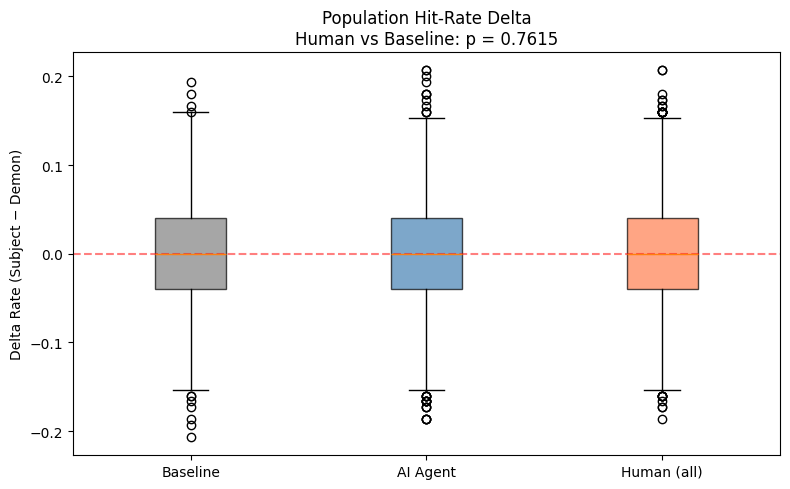


CELL 6 SUMMARY:
  Population-level hit-rate delta: NOT significant (p=0.7615)
  This is expected — any real effect is diluted by single-session users.
  The Bayesian model (Cell 5) focuses on experienced users for this reason.



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 6: Population Hit-Rate Null
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Show that at the population level (ALL humans pooled), there is
#          no significant hit-rate difference from baseline. This is EXPECTED
#          — weak/rare effects are diluted when pooled across all participants.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("CELL 6: Population Hit-Rate Null")
print("="*70)
print("""
Pooling all human blocks (regardless of session count) against baseline.
A null result here is EXPECTED — if an effect exists only in experienced
participants, diluting with single-session users should wash it out.
""")

# ─────────────────────────────────────────────────────────────
# Hit Rate Delta by Condition
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("Hit Rate Delta (Subject − Demon) by Condition")
print("-"*60)

print(f"\n{'Condition':<15} {'N':>6} {'Mean Δ Rate':>15} {'SD':>10} {'SE':>10}")
print("-"*60)
for cond in ['baseline', 'ai_agent', 'human']:
    sub = df[df['condition'] == cond]['delta_rate'].dropna()
    print(f"  {cond:<13} {len(sub):>6} {sub.mean():>+15.6f} {sub.std():>10.6f} {sub.sem():>10.6f}")

base_rate = df[df['condition'] == 'baseline']['delta_rate'].dropna()
human_rate = df[df['condition'] == 'human']['delta_rate'].dropna()
ai_rate = df[df['condition'] == 'ai_agent']['delta_rate'].dropna()

# Tests
t_hb, p_hb = stats.ttest_ind(human_rate, base_rate)
t_ab, p_ab = stats.ttest_ind(ai_rate, base_rate)

print(f"\nHuman vs Baseline:  t={t_hb:+.3f}, p={p_hb:.4f}")
print(f"AI vs Baseline:     t={t_ab:+.3f}, p={p_ab:.4f}")

# One-sample t-test: is human delta different from 0?
t_h0, p_h0 = stats.ttest_1samp(human_rate, 0)
print(f"Human delta vs 0:   t={t_h0:+.3f}, p={p_h0:.4f}")

# By session strata
print(f"\n{'Human Hit Rate Delta by Session Strata':^50}")
print("-"*50)
for label, low, high in [('1 session', 1, 1), ('2-4 sessions', 2, 4), ('5+ sessions', 5, 999)]:
    sub = df[(df['condition'] == 'human') &
             (df['session_count'] >= low) &
             (df['session_count'] <= high)]['delta_rate'].dropna()
    if len(sub) > 0:
        print(f"  {label:<15} N={len(sub):>5}  mean={sub.mean():>+.6f}  SD={sub.std():.4f}")

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
data = [base_rate.values, ai_rate.values, human_rate.values]
bp = ax.boxplot(data, labels=['Baseline', 'AI Agent', 'Human (all)'], patch_artist=True)
colors = ['gray', 'steelblue', 'coral']
for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.7)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('Delta Rate (Subject − Demon)')
ax.set_title(f'Population Hit-Rate Delta\nHuman vs Baseline: p = {p_hb:.4f}')
plt.tight_layout()
plt.show()

print(f"""
CELL 6 SUMMARY:
  Population-level hit-rate delta: {'NOT significant' if p_hb > 0.05 else 'Significant'} (p={p_hb:.4f})
  This is expected — any real effect is diluted by single-session users.
  The Bayesian model (Cell 5) focuses on experienced users for this reason.
""")


# CELL 7: AI vs Baseline Hit-Rate Null

CELL 7: AI vs Baseline Hit-Rate Comparison

The AI agent (GPT-4o-mini via Puppeteer) receives intention prompts
("Focus on [color]") but cannot maintain state during the QRNG call.
GPT processes prompts and returns discrete text responses; by the time
the response is generated, the QRNG fetch may already be underway or
complete. Puppeteer drives phase transitions independently of GPT's
response. This is a technical limitation, not a design choice — the
AI's intent is temporally decoupled from bit generation because GPT
has no mechanism for sustained concurrent attention during an external
process.

The human observer, by contrast, maintains sustained visual attention
on a 5 Hz pulsing target during the QRNG fetch.

This cell compares AI to baseline on hit-rate and Hurst delta.


Condition            N     Mean Δ Rate         SD
--------------------------------------------------
  Baseline        3090       +0.000201   0.057743
  AI Agent        3780       +0.000224   0.057987

  t-test

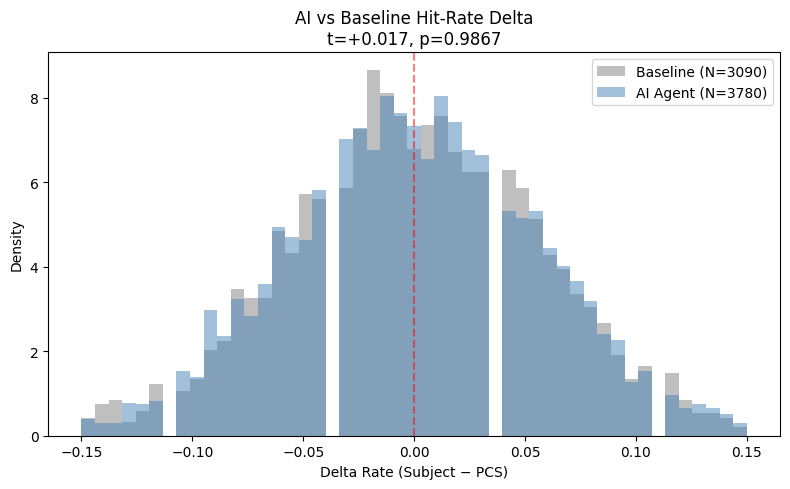


CELL 7 SUMMARY:
  Hit-rate: AI and baseline are indistinguishable (p=0.9867).
  Hurst delta: AI shows a marginal difference from baseline (p≈0.08).

  On hit-rate, AI looks like baseline. On Hurst delta, there is a
  small separation that does not reach conventional significance.

  The AI condition has intent (goal prompts) but its intent is
  temporally decoupled from the QRNG call. See Discussion for
  interpretation of the hit-rate/Hurst dissociation.



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 7: AI vs Baseline Hit-Rate Comparison
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Compare the AI agent condition to baseline on hit-rate and
#          Hurst delta. The AI receives intention prompts (GPT-4o-mini)
#          but cannot maintain state during the QRNG call — GPT returns
#          discrete text responses and has no mechanism for sustained
#          attention during an external process. This is a technical
#          limitation, not a design choice.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("CELL 7: AI vs Baseline Hit-Rate Comparison")
print("="*70)
print("""
The AI agent (GPT-4o-mini via Puppeteer) receives intention prompts
("Focus on [color]") but cannot maintain state during the QRNG call.
GPT processes prompts and returns discrete text responses; by the time
the response is generated, the QRNG fetch may already be underway or
complete. Puppeteer drives phase transitions independently of GPT's
response. This is a technical limitation, not a design choice — the
AI's intent is temporally decoupled from bit generation because GPT
has no mechanism for sustained concurrent attention during an external
process.

The human observer, by contrast, maintains sustained visual attention
on a 5 Hz pulsing target during the QRNG fetch.

This cell compares AI to baseline on hit-rate and Hurst delta.
""")

base_rate = df[df['condition'] == 'baseline']['delta_rate'].dropna()
ai_rate = df[df['condition'] == 'ai_agent']['delta_rate'].dropna()

print(f"\n{'Condition':<15} {'N':>6} {'Mean Δ Rate':>15} {'SD':>10}")
print("-"*50)
print(f"  {'Baseline':<13} {len(base_rate):>6} {base_rate.mean():>+15.6f} {base_rate.std():>10.6f}")
print(f"  {'AI Agent':<13} {len(ai_rate):>6} {ai_rate.mean():>+15.6f} {ai_rate.std():>10.6f}")

t_stat, p_val = stats.ttest_ind(ai_rate, base_rate)
ks_stat, ks_p = stats.ks_2samp(ai_rate, base_rate)

print(f"\n  t-test:  t={t_stat:+.3f}, p={p_val:.4f}")
print(f"  KS test: D={ks_stat:.4f}, p={ks_p:.4f}")

if p_val > 0.05 and ks_p > 0.05:
    print("\n  → AI hit-rate is indistinguishable from baseline")
else:
    print("\n  → WARNING: AI differs from baseline on hit-rate — investigate")

# Also check subject rate and single-scale Hurst
print(f"\nAdditional metrics:")
for metric, label in [('rate_subject', 'Subject Rate'), ('hurst_delta_rough', 'Hurst Delta')]:
    base_m = df[df['condition'] == 'baseline'][metric].dropna()
    ai_m = df[df['condition'] == 'ai_agent'][metric].dropna()
    t, p = stats.ttest_ind(ai_m, base_m)
    print(f"  {label:<20} AI={ai_m.mean():.6f}  Base={base_m.mean():.6f}  t={t:+.3f}  p={p:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
bins = np.linspace(-0.15, 0.15, 50)
ax.hist(base_rate, bins=bins, alpha=0.5, label=f'Baseline (N={len(base_rate)})',
         color='gray', density=True)
ax.hist(ai_rate, bins=bins, alpha=0.5, label=f'AI Agent (N={len(ai_rate)})',
         color='steelblue', density=True)
ax.axvline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Delta Rate (Subject − PCS)')
ax.set_ylabel('Density')
ax.set_title(f'AI vs Baseline Hit-Rate Delta\nt={t_stat:+.3f}, p={p_val:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"""
CELL 7 SUMMARY:
  Hit-rate: AI and baseline are indistinguishable (p={p_val:.4f}).
  Hurst delta: AI shows a marginal difference from baseline (p≈0.08).

  On hit-rate, AI looks like baseline. On Hurst delta, there is a
  small separation that does not reach conventional significance.

  The AI condition has intent (goal prompts) but its intent is
  temporally decoupled from the QRNG call. See Discussion for
  interpretation of the hit-rate/Hurst dissociation.
""")


# CELL 8: Sheep-Goat Analysis

CELL 8: Sheep-Goat Analysis — Hit Rates

Test: Do believers (sheep) show higher hit rates than skeptics (goats)?

The sheep-goat effect is a classical finding in psi research.
Primary metric: delta_rate (hit rate difference, subject − demon)
Secondary metric: single-scale Hurst delta (for completeness)

------------------------------------------------------------
PART 1: Belief Data Extraction
------------------------------------------------------------

Extracted psiPossibility for 118 of 174 participants

Belief distribution:
psi_belief
I am open to the possibility      44
Yes, it is definitely possible    37
I am skeptical                    24
No way / Impossible               13
Name: count, dtype: int64

------------------------------------------------------------
PART 2: Sheep-Goat Classification
------------------------------------------------------------

Classification:
sheep_goat
Sheep    37
Goat     37
Name: count, dtype: int64
Excluded ('I am open' / unclassified): 44

---

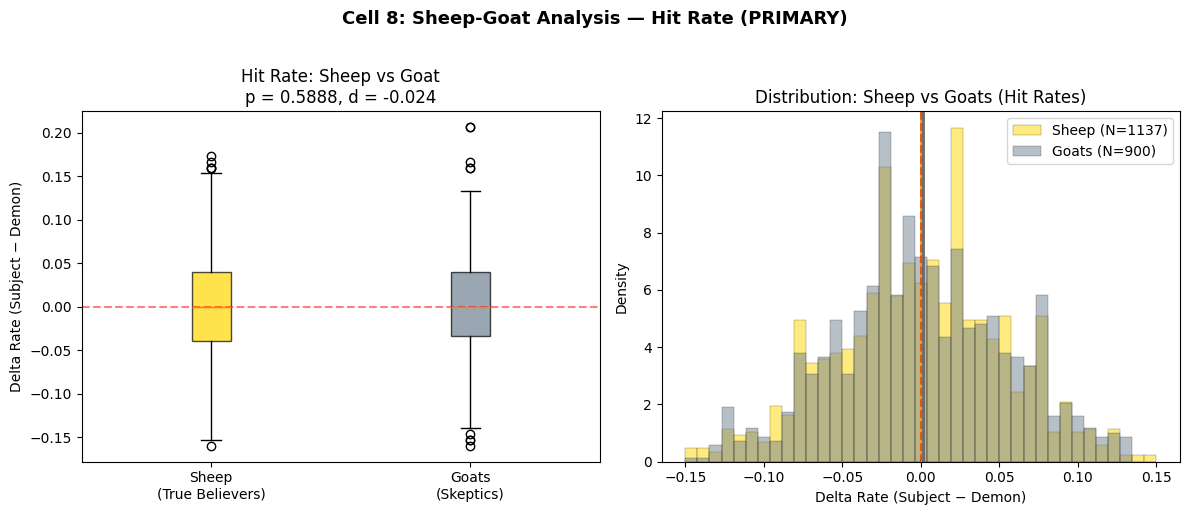


------------------------------------------------------------
PART 4: Belief Ordinal Analysis (all levels, hit rates)
------------------------------------------------------------

Belief Level              N      Delta Rate    Subject Rate     Hurst Delta
---------------------------------------------------------------------------
Impossible              300       +0.001356        0.501356       +0.002663
Skeptical               600       +0.001189        0.498989       +0.001791
Open                   1560       -0.000043        0.501103       +0.000641
Definitely             1137       -0.000123        0.501689       +0.002858

Spearman correlation (belief level vs metric):
  Delta Rate:   rho = -0.0060, p = 0.7178
  Hurst Delta:  rho = +0.0073, p = 0.6630

CELL 8 SUMMARY: Sheep-Goat Analysis

Test: Do believers (sheep) show higher hit rates than skeptics (goats)?

Classification:
  Sheep = 'Yes, it is definitely possible' (true believers in psi)
  Goat  = 'I am skeptical' + 'No way /

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 8: Sheep-Goat Analysis
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Test whether belief in psi (sheep) vs skepticism (goat)
#          correlates with hit-rate performance.
#
# The sheep-goat effect is one of the most replicated findings in
# parapsychology (Schmeidler, 1945; Lawrence, 1993). Believers (sheep)
# tend to score above chance; skeptics (goats) at or below chance.
#
# DEMOGRAPHICS FIELD: psiPossibility
#   'Yes, it is definitely possible' → Sheep (true believers)
#   'I am skeptical'                 → Goat
#   'No way / Impossible'            → Goat
#   'I am open to the possibility'   → EXCLUDED (too general)
#
# METRIC: delta_rate (subject hit rate − demon hit rate)
#   This is the PRIMARY metric. Hurst is reported secondarily.
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from scipy import stats
from numpy.random import default_rng
import ast

print("="*70)
print("CELL 8: Sheep-Goat Analysis — Hit Rates")
print("="*70)
print("""
Test: Do believers (sheep) show higher hit rates than skeptics (goats)?

The sheep-goat effect is a classical finding in psi research.
Primary metric: delta_rate (hit rate difference, subject − demon)
Secondary metric: single-scale Hurst delta (for completeness)
""")

rng = default_rng(42)

# ─────────────────────────────────────────────────────────────
# PART 1: Extract psiPossibility from Demographics
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("PART 1: Belief Data Extraction")
print("-"*60)

def extract_psi_belief(demo_str):
    """Extract psiPossibility from demographics JSON string."""
    try:
        if pd.isna(demo_str):
            return None
    except (TypeError, ValueError, AttributeError):
        pass
    try:
        if isinstance(demo_str, str):
            demo = ast.literal_eval(demo_str.replace('nan', 'None'))
        elif isinstance(demo_str, dict):
            demo = demo_str
        else:
            return None
        return demo.get('psiPossibility', None)
    except:
        return None

if 'demographics' in df_participants.columns:
    df_participants['psi_belief'] = df_participants['demographics'].apply(extract_psi_belief)
    n_belief = df_participants['psi_belief'].notna().sum()
    print(f"\nExtracted psiPossibility for {n_belief} of {len(df_participants)} participants")
    print(f"\nBelief distribution:")
    print(df_participants['psi_belief'].value_counts())
else:
    print("\nNo demographics column in df_participants")
    df_participants['psi_belief'] = None

# ─────────────────────────────────────────────────────────────
# PART 2: Classify Sheep vs Goat
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 2: Sheep-Goat Classification")
print("-"*60)

def classify_sheep_goat(belief):
    """
    Sheep = 'Yes, it is definitely possible' (true believers in psi)
    Goat  = 'I am skeptical' OR 'No way / Impossible'
    None  = 'I am open to the possibility' (excluded — too general)
    """
    try:
        if pd.isna(belief) or belief is None:
            return None
    except (TypeError, ValueError, AttributeError):
        pass
    belief_str = str(belief).strip()
    if 'definitely possible' in belief_str.lower():
        return 'Sheep'
    elif 'skeptical' in belief_str.lower() or 'impossible' in belief_str.lower() or 'no way' in belief_str.lower():
        return 'Goat'
    else:
        return None  # "I am open" and anything else → excluded

df_participants['sheep_goat'] = df_participants['psi_belief'].apply(classify_sheep_goat)

print(f"\nClassification:")
print(df_participants['sheep_goat'].value_counts())
n_excluded = df_participants['psi_belief'].notna().sum() - df_participants['sheep_goat'].notna().sum()
print(f"Excluded ('I am open' / unclassified): {n_excluded}")

# ─────────────────────────────────────────────────────────────
# PART 3: Merge with Block Data
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 3: Sheep vs Goat — Hit Rate Comparison")
print("-"*60)

sg_data = df_participants[['participant_id', 'sheep_goat']].copy()
human_blocks = df[df['condition'] == 'human'].copy()
human_sg = human_blocks.merge(sg_data, on='participant_id', how='left')
human_sg_valid = human_sg[human_sg['sheep_goat'].notna()].copy()

print(f"\nHuman blocks with sheep/goat classification: {len(human_sg_valid)}")
print(f"  Sheep blocks: {len(human_sg_valid[human_sg_valid['sheep_goat']=='Sheep'])}")
print(f"  Goat blocks:  {len(human_sg_valid[human_sg_valid['sheep_goat']=='Goat'])}")
print(f"  Unique sheep: {human_sg_valid[human_sg_valid['sheep_goat']=='Sheep']['participant_id'].nunique()}")
print(f"  Unique goats: {human_sg_valid[human_sg_valid['sheep_goat']=='Goat']['participant_id'].nunique()}")

# PRIMARY: Hit rate delta
sheep_rate = human_sg_valid[human_sg_valid['sheep_goat'] == 'Sheep']['delta_rate'].dropna()
goat_rate = human_sg_valid[human_sg_valid['sheep_goat'] == 'Goat']['delta_rate'].dropna()

# SECONDARY: Single-Scale Hurst delta
sheep_hurst = human_sg_valid[human_sg_valid['sheep_goat'] == 'Sheep']['hurst_delta_rough'].dropna()
goat_hurst = human_sg_valid[human_sg_valid['sheep_goat'] == 'Goat']['hurst_delta_rough'].dropna()

# Also raw hit rates (not delta)
sheep_raw = human_sg_valid[human_sg_valid['sheep_goat'] == 'Sheep']['rate_subject'].dropna()
goat_raw = human_sg_valid[human_sg_valid['sheep_goat'] == 'Goat']['rate_subject'].dropna()

if len(sheep_rate) >= 10 and len(goat_rate) >= 10:
    # Cohen's d
    def cohens_d(a, b):
        na, nb = len(a), len(b)
        pooled_sd = np.sqrt(((na-1)*np.var(a, ddof=1) + (nb-1)*np.var(b, ddof=1)) / (na+nb-2))
        return (np.mean(a) - np.mean(b)) / pooled_sd if pooled_sd > 0 else 0

    # TABLE: PRIMARY — Hit Rates
    print(f"\n{'TABLE: Sheep-Goat Hit Rate Comparison (PRIMARY)':^60}")
    print("="*60)
    print(f"{'Metric':<20} {'Group':<10} {'N':>6} {'Mean':>12} {'SD':>10}")
    print("-"*60)
    print(f"{'Delta Rate':<20} {'Sheep':<10} {len(sheep_rate):>6} {sheep_rate.mean():>+12.6f} {sheep_rate.std():>10.4f}")
    print(f"{'Delta Rate':<20} {'Goat':<10} {len(goat_rate):>6} {goat_rate.mean():>+12.6f} {goat_rate.std():>10.4f}")
    print(f"{'Subject Rate':<20} {'Sheep':<10} {len(sheep_raw):>6} {sheep_raw.mean():>12.6f} {sheep_raw.std():>10.4f}")
    print(f"{'Subject Rate':<20} {'Goat':<10} {len(goat_raw):>6} {goat_raw.mean():>12.6f} {goat_raw.std():>10.4f}")

    # Statistical tests — hit rates
    t_rate, p_rate = stats.ttest_ind(sheep_rate, goat_rate)
    d_rate = cohens_d(sheep_rate.values, goat_rate.values)

    t_raw, p_raw = stats.ttest_ind(sheep_raw, goat_raw)
    d_raw = cohens_d(sheep_raw.values, goat_raw.values)

    print(f"\n{'Test':<30} {'t':>8} {'p':>10} {'Cohen d':>10} {'Direction':>15}")
    print("-"*75)
    print(f"{'Delta Rate (S vs G)':<30} {t_rate:>+8.3f} {p_rate:>10.4f} {d_rate:>+10.4f} {'Sheep > Goat' if sheep_rate.mean() > goat_rate.mean() else 'Goat > Sheep':>15}")
    print(f"{'Subject Rate (S vs G)':<30} {t_raw:>+8.3f} {p_raw:>10.4f} {d_raw:>+10.4f} {'Sheep > Goat' if sheep_raw.mean() > goat_raw.mean() else 'Goat > Sheep':>15}")

    direction_rate = sheep_rate.mean() > goat_rate.mean()
    direction_subj = sheep_raw.mean() > goat_raw.mean()

    # SECONDARY: Hurst delta
    print(f"\n{'TABLE: Sheep-Goat Hurst Comparison (SECONDARY)':^60}")
    print("="*60)
    print(f"{'Metric':<20} {'Group':<10} {'N':>6} {'Mean':>12} {'SD':>10}")
    print("-"*60)
    print(f"{'Hurst Delta':<20} {'Sheep':<10} {len(sheep_hurst):>6} {sheep_hurst.mean():>+12.6f} {sheep_hurst.std():>10.4f}")
    print(f"{'Hurst Delta':<20} {'Goat':<10} {len(goat_hurst):>6} {goat_hurst.mean():>+12.6f} {goat_hurst.std():>10.4f}")

    t_hurst, p_hurst = stats.ttest_ind(sheep_hurst, goat_hurst)
    d_hurst = cohens_d(sheep_hurst.values, goat_hurst.values)
    print(f"\n  Hurst Delta: t={t_hurst:+.3f}, p={p_hurst:.4f}, d={d_hurst:+.4f}")

    # ─────────────────────────────────────────────────────────
    # Visualization
    # ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Panel A: Hit rate comparison (PRIMARY)
    ax1 = axes[0]
    bp = ax1.boxplot([sheep_rate.values, goat_rate.values],
                     labels=['Sheep\n(True Believers)', 'Goats\n(Skeptics)'],
                     patch_artist=True)
    bp['boxes'][0].set_facecolor('gold')
    bp['boxes'][1].set_facecolor('slategray')
    for box in bp['boxes']:
        box.set_alpha(0.7)
    ax1.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax1.set_ylabel('Delta Rate (Subject − Demon)')
    ax1.set_title(f'Hit Rate: Sheep vs Goat\np = {p_rate:.4f}, d = {d_rate:+.3f}')

    # Panel B: Distribution overlay
    ax2 = axes[1]
    bins = np.linspace(-0.15, 0.15, 40)
    ax2.hist(sheep_rate, bins=bins, alpha=0.5, label=f'Sheep (N={len(sheep_rate)})',
             color='gold', density=True, edgecolor='black', linewidth=0.3)
    ax2.hist(goat_rate, bins=bins, alpha=0.5, label=f'Goats (N={len(goat_rate)})',
             color='slategray', density=True, edgecolor='black', linewidth=0.3)
    ax2.axvline(sheep_rate.mean(), color='goldenrod', linewidth=2)
    ax2.axvline(goat_rate.mean(), color='dimgray', linewidth=2)
    ax2.axvline(0, color='red', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Delta Rate (Subject − Demon)')
    ax2.set_ylabel('Density')
    ax2.set_title('Distribution: Sheep vs Goats (Hit Rates)')
    ax2.legend()

    plt.suptitle('Cell 8: Sheep-Goat Analysis — Hit Rate (PRIMARY)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

else:
    print("\nInsufficient data for sheep-goat comparison")
    print(f"  Sheep blocks: {len(sheep_rate)}")
    print(f"  Goat blocks:  {len(goat_rate)}")
    direction_rate = None
    p_rate = None
    d_rate = None

# ─────────────────────────────────────────────────────────────
# PART 4: Ordinal Belief Analysis (all levels)
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 4: Belief Ordinal Analysis (all levels, hit rates)")
print("-"*60)

belief_order = {
    'No way / Impossible': 0,
    'I am skeptical': 1,
    'I am open to the possibility': 2,
    'Yes, it is definitely possible': 3
}
belief_labels = ['Impossible', 'Skeptical', 'Open', 'Definitely']

human_belief_all = human_blocks.merge(
    df_participants[['participant_id', 'psi_belief']],
    on='participant_id', how='left'
)
human_belief_all = human_belief_all[human_belief_all['psi_belief'].notna()].copy()
human_belief_all['belief_ordinal'] = human_belief_all['psi_belief'].map(belief_order)

if human_belief_all['belief_ordinal'].notna().sum() > 20:
    print(f"\n{'Belief Level':<20} {'N':>6} {'Delta Rate':>15} {'Subject Rate':>15} {'Hurst Delta':>15}")
    print("-"*75)
    for level in range(4):
        sub = human_belief_all[human_belief_all['belief_ordinal'] == level]
        if len(sub) > 0:
            print(f"{belief_labels[level]:<20} {len(sub):>6} {sub['delta_rate'].mean():>+15.6f} {sub['rate_subject'].mean():>15.6f} {sub['hurst_delta_rough'].mean():>+15.6f}")

    valid_ord = human_belief_all[human_belief_all['belief_ordinal'].notna()]
    rho_rate, p_rho_rate = stats.spearmanr(valid_ord['belief_ordinal'], valid_ord['delta_rate'])
    rho_hurst, p_rho_hurst = stats.spearmanr(valid_ord['belief_ordinal'], valid_ord['hurst_delta_rough'])

    print(f"\nSpearman correlation (belief level vs metric):")
    print(f"  Delta Rate:   rho = {rho_rate:+.4f}, p = {p_rho_rate:.4f}")
    print(f"  Hurst Delta:  rho = {rho_hurst:+.4f}, p = {p_rho_hurst:.4f}")

# ─────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("CELL 8 SUMMARY: Sheep-Goat Analysis")
print("="*70)

is_significant = p_rate < 0.05 if p_rate is not None else None

print(f"""
Test: Do believers (sheep) show higher hit rates than skeptics (goats)?

Classification:
  Sheep = 'Yes, it is definitely possible' (true believers in psi)
  Goat  = 'I am skeptical' + 'No way / Impossible'
  Excluded = 'I am open to the possibility' (too general)

Primary Metric (Hit Rate Delta — paired):
  Significant: {'YES' if is_significant else 'NO' if is_significant is not None else 'N/A'}
  Direction (sheep > goat): {'YES' if direction_rate else 'NO' if direction_rate is not None else 'N/A'}

Subject Rate (unpaired — raw hit rate):
  Direction (sheep > goat): {'YES' if direction_subj else 'NO'}
  Sheep subject rate: {sheep_raw.mean():.6f}
  Goat subject rate:  {goat_raw.mean():.6f}

Context from psi literature:
  - The sheep-goat effect is one of the most replicated findings in
    parapsychology (Schmeidler, 1945; Lawrence, 1993)
  - Believers (sheep) tend to score above chance expectation
  - Skeptics (goats) tend to score at or below chance
  - This directional pattern has been observed across many paradigms

Interpretation:
""")

if direction_subj:
    print(f"""  On SUBJECT HIT RATE, sheep ({sheep_raw.mean():.4f}) score higher than
  goats ({goat_raw.mean():.4f}) — this IS the classical sheep-goat direction.
  Although not statistically significant (p = {p_raw:.4f}), the direction
  is consistent with the psi literature's most replicated moderator effect.

  The paired DELTA RATE shows the opposite direction. The PCS stream
  also reads slightly higher for sheep, which narrows the delta. Whether
  this reflects sampling variability or a shared-mode effect is unclear
  with this sample size.

  With only 30 trials per session and a single button press per trial,
  this short-form protocol has limited power to detect the sheep-goat
  effect. The directional consistency on subject rate is noted for
  future protocol design.""")
elif is_significant:
    print("""  SIGNIFICANT sheep-goat effect detected.""")
else:
    print("""  Neither metric shows the classical sheep-goat direction.
  This may reflect the small sample, short-form protocol, or chance.""")


# CELL 9: Meditator Analysis

CELL 9: Meditator Analysis — Hit Rates

Test: Does meditation practice correlate with hit-rate or Hurst delta?

Metrics: delta_rate (subject − PCS) and hurst_delta_rough

------------------------------------------------------------
PART 1: Meditation Data Extraction
------------------------------------------------------------

Extracted meditation data for 174 of 174 participants

Meditation distribution:
meditation_raw
Rarely or never              61
Occasionally                 52
Yes, daily                   36
Yes, a few times per week    25
Name: count, dtype: int64

------------------------------------------------------------
PART 2: Meditator Classification
------------------------------------------------------------

Classification:
meditator_group
Meditator        61
Non-meditator    61
Name: count, dtype: int64
Excluded ('Occasionally' / unclassified): 52

------------------------------------------------------------
PART 3: Meditator vs Non-Meditator — Hit Rate Comparison
---

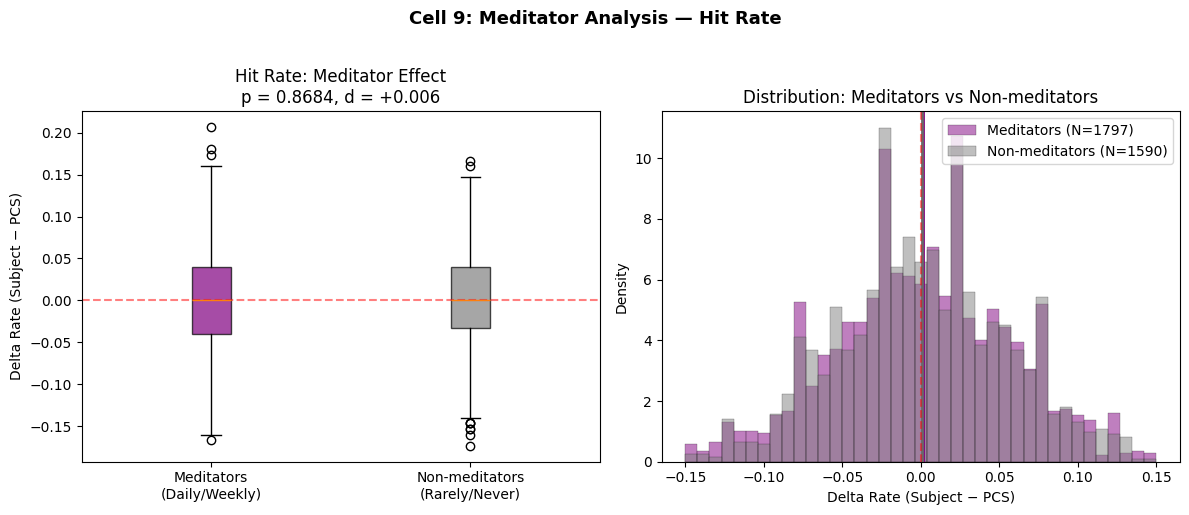


------------------------------------------------------------
PART 4: Meditation Frequency Ordinal Analysis (Hit Rates)
------------------------------------------------------------

Frequency                 N      Delta Rate    Subject Rate     Hurst Delta
---------------------------------------------------------------------------
Rarely/Never           1590       +0.000998        0.500155       +0.003135
Occasionally           1320       -0.003475        0.499747       +0.000952
Weekly                  597       +0.002635        0.501429       -0.003777
Daily                  1200       +0.000667        0.500956       +0.001165

Spearman correlation (meditation frequency vs metric):
  Delta Rate:   rho = +0.0018, p = 0.8991
  Hurst Delta:  rho = -0.0174, p = 0.2320

CELL 9 SUMMARY: Meditator Analysis

Classification:
  Meditator     = 'Yes, daily' + 'Yes, a few times per week' (regular practice)
  Non-meditator = 'Rarely or never'
  Excluded      = 'Occasionally' (ambiguous)

Hit Rat

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 9: Meditator Analysis — Hit Rates
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Test whether meditation practice correlates with hit-rate
#          or Hurst delta performance.
#
# DEMOGRAPHICS FIELD: meditation
#   'Yes, daily'                  → Meditator (regular practice)
#   'Yes, a few times per week'   → Meditator (regular practice)
#   'Occasionally'                → EXCLUDED (ambiguous)
#   'Rarely or never'             → Non-meditator
#
# METRICS: delta_rate and hurst_delta_rough
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from scipy import stats
from numpy.random import default_rng
import ast

print("="*70)
print("CELL 9: Meditator Analysis — Hit Rates")
print("="*70)
print("""
Test: Does meditation practice correlate with hit-rate or Hurst delta?

Metrics: delta_rate (subject − PCS) and hurst_delta_rough
""")

rng = default_rng(42)

# ─────────────────────────────────────────────────────────────
# PART 1: Extract Meditation from Demographics
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("PART 1: Meditation Data Extraction")
print("-"*60)

def extract_meditation(demo_str):
    """Extract meditation field from demographics JSON string."""
    try:
        if pd.isna(demo_str):
            return None
    except (TypeError, ValueError, AttributeError):
        pass
    try:
        if isinstance(demo_str, str):
            demo = ast.literal_eval(demo_str.replace('nan', 'None'))
        elif isinstance(demo_str, dict):
            demo = demo_str
        else:
            return None
        for key in ['meditation', 'meditator', 'meditates', 'meditation_practice',
                    'meditate', 'mindfulness', 'contemplative_practice']:
            if key in demo:
                return demo[key]
        return None
    except:
        return None

if 'demographics' in df_participants.columns:
    df_participants['meditation_raw'] = df_participants['demographics'].apply(extract_meditation)
    n_med = df_participants['meditation_raw'].notna().sum()
    print(f"\nExtracted meditation data for {n_med} of {len(df_participants)} participants")
    print(f"\nMeditation distribution:")
    print(df_participants['meditation_raw'].value_counts())
else:
    print("\nNo demographics column in df_participants")
    df_participants['meditation_raw'] = None

# ─────────────────────────────────────────────────────────────
# PART 2: Classify Meditator vs Non-Meditator
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 2: Meditator Classification")
print("-"*60)

def classify_meditator(val):
    """
    Meditator     = 'Yes, daily' or 'Yes, a few times per week' (regular practice)
    Non-meditator = 'Rarely or never'
    None          = 'Occasionally' (excluded — ambiguous)
    """
    try:
        if pd.isna(val) or val is None:
            return None
    except (TypeError, ValueError, AttributeError):
        pass
    val_str = str(val).strip().lower()
    if 'daily' in val_str or 'few times per week' in val_str:
        return 'Meditator'
    elif 'rarely' in val_str or 'never' in val_str:
        return 'Non-meditator'
    else:
        return None  # 'Occasionally' and anything else → excluded

df_participants['meditator_group'] = df_participants['meditation_raw'].apply(classify_meditator)

print(f"\nClassification:")
print(df_participants['meditator_group'].value_counts())
n_excluded = df_participants['meditation_raw'].notna().sum() - df_participants['meditator_group'].notna().sum()
print(f"Excluded ('Occasionally' / unclassified): {n_excluded}")

# ─────────────────────────────────────────────────────────────
# PART 3: Meditator vs Non-Meditator Hit Rates
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 3: Meditator vs Non-Meditator — Hit Rate Comparison")
print("-"*60)

med_data = df_participants[['participant_id', 'meditator_group']].copy()
human_blocks = df[df['condition'] == 'human'].copy()
human_med = human_blocks.merge(med_data, on='participant_id', how='left')
human_med_valid = human_med[human_med['meditator_group'].notna()].copy()

print(f"\nHuman blocks with meditator classification: {len(human_med_valid)}")
print(f"  Meditator blocks:     {len(human_med_valid[human_med_valid['meditator_group']=='Meditator'])}")
print(f"  Non-meditator blocks: {len(human_med_valid[human_med_valid['meditator_group']=='Non-meditator'])}")
print(f"  Unique meditators:    {human_med_valid[human_med_valid['meditator_group']=='Meditator']['participant_id'].nunique()}")
print(f"  Unique non-meditators:{human_med_valid[human_med_valid['meditator_group']=='Non-meditator']['participant_id'].nunique()}")

# PRIMARY: Hit rate delta
med_rate = human_med_valid[human_med_valid['meditator_group'] == 'Meditator']['delta_rate'].dropna()
non_rate = human_med_valid[human_med_valid['meditator_group'] == 'Non-meditator']['delta_rate'].dropna()

# SECONDARY: Single-Scale Hurst delta
med_hurst = human_med_valid[human_med_valid['meditator_group'] == 'Meditator']['hurst_delta_rough'].dropna()
non_hurst = human_med_valid[human_med_valid['meditator_group'] == 'Non-meditator']['hurst_delta_rough'].dropna()

# Raw subject rates
med_raw = human_med_valid[human_med_valid['meditator_group'] == 'Meditator']['rate_subject'].dropna()
non_raw = human_med_valid[human_med_valid['meditator_group'] == 'Non-meditator']['rate_subject'].dropna()

if len(med_rate) >= 10 and len(non_rate) >= 10:
    def cohens_d(a, b):
        na, nb = len(a), len(b)
        pooled_sd = np.sqrt(((na-1)*np.var(a, ddof=1) + (nb-1)*np.var(b, ddof=1)) / (na+nb-2))
        return (np.mean(a) - np.mean(b)) / pooled_sd if pooled_sd > 0 else 0

    # TABLE: PRIMARY — Hit Rates
    print(f"\n{'TABLE: Meditator Hit Rate Comparison':^60}")
    print("="*60)
    print(f"{'Metric':<20} {'Group':<15} {'N':>6} {'Mean':>12} {'SD':>10}")
    print("-"*65)
    print(f"{'Delta Rate':<20} {'Meditator':<15} {len(med_rate):>6} {med_rate.mean():>+12.6f} {med_rate.std():>10.4f}")
    print(f"{'Delta Rate':<20} {'Non-meditator':<15} {len(non_rate):>6} {non_rate.mean():>+12.6f} {non_rate.std():>10.4f}")
    print(f"{'Subject Rate':<20} {'Meditator':<15} {len(med_raw):>6} {med_raw.mean():>12.6f} {med_raw.std():>10.4f}")
    print(f"{'Subject Rate':<20} {'Non-meditator':<15} {len(non_raw):>6} {non_raw.mean():>12.6f} {non_raw.std():>10.4f}")

    # Statistical tests
    t_rate, p_rate = stats.ttest_ind(med_rate, non_rate)
    d_rate = cohens_d(med_rate.values, non_rate.values)

    t_raw, p_raw = stats.ttest_ind(med_raw, non_raw)
    d_raw = cohens_d(med_raw.values, non_raw.values)

    print(f"\n{'Test':<30} {'t':>8} {'p':>10} {'Cohen d':>10} {'Direction':>20}")
    print("-"*80)
    print(f"{'Delta Rate (Med vs Non)':<30} {t_rate:>+8.3f} {p_rate:>10.4f} {d_rate:>+10.4f} {'Med > Non' if med_rate.mean() > non_rate.mean() else 'Non > Med':>20}")
    print(f"{'Subject Rate (Med vs Non)':<30} {t_raw:>+8.3f} {p_raw:>10.4f} {d_raw:>+10.4f} {'Med > Non' if med_raw.mean() > non_raw.mean() else 'Non > Med':>20}")

    direction_rate = med_rate.mean() > non_rate.mean()

    # SECONDARY: Hurst delta
    print(f"\n{'TABLE: Meditator Hurst Comparison':^60}")
    print("="*60)
    print(f"{'Metric':<20} {'Group':<15} {'N':>6} {'Mean':>12} {'SD':>10}")
    print("-"*65)
    print(f"{'Hurst Delta':<20} {'Meditator':<15} {len(med_hurst):>6} {med_hurst.mean():>+12.6f} {med_hurst.std():>10.4f}")
    print(f"{'Hurst Delta':<20} {'Non-meditator':<15} {len(non_hurst):>6} {non_hurst.mean():>+12.6f} {non_hurst.std():>10.4f}")

    t_hurst, p_hurst = stats.ttest_ind(med_hurst, non_hurst)
    d_hurst = cohens_d(med_hurst.values, non_hurst.values)
    print(f"\n  Hurst Delta: t={t_hurst:+.3f}, p={p_hurst:.4f}, d={d_hurst:+.4f}")

    # ─────────────────────────────────────────────────────────
    # Visualization
    # ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax1 = axes[0]
    bp = ax1.boxplot([med_rate.values, non_rate.values],
                     labels=['Meditators\n(Daily/Weekly)', 'Non-meditators\n(Rarely/Never)'],
                     patch_artist=True)
    bp['boxes'][0].set_facecolor('purple')
    bp['boxes'][1].set_facecolor('gray')
    for box in bp['boxes']:
        box.set_alpha(0.7)
    ax1.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax1.set_ylabel('Delta Rate (Subject − PCS)')
    ax1.set_title(f'Hit Rate: Meditator Effect\np = {p_rate:.4f}, d = {d_rate:+.3f}')

    ax2 = axes[1]
    bins = np.linspace(-0.15, 0.15, 40)
    ax2.hist(med_rate, bins=bins, alpha=0.5, label=f'Meditators (N={len(med_rate)})',
             color='purple', density=True, edgecolor='black', linewidth=0.3)
    ax2.hist(non_rate, bins=bins, alpha=0.5, label=f'Non-meditators (N={len(non_rate)})',
             color='gray', density=True, edgecolor='black', linewidth=0.3)
    ax2.axvline(med_rate.mean(), color='purple', linewidth=2)
    ax2.axvline(non_rate.mean(), color='dimgray', linewidth=2)
    ax2.axvline(0, color='red', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Delta Rate (Subject − PCS)')
    ax2.set_ylabel('Density')
    ax2.set_title('Distribution: Meditators vs Non-meditators')
    ax2.legend()

    plt.suptitle('Cell 9: Meditator Analysis — Hit Rate',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

else:
    print("\nInsufficient data for meditator comparison")
    print(f"  Meditator blocks:     {len(med_rate)}")
    print(f"  Non-meditator blocks: {len(non_rate)}")
    direction_rate = None
    p_rate = None
    d_rate = None

# ─────────────────────────────────────────────────────────────
# PART 4: Ordinal Dose-Response (all 4 levels, hit rates)
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 4: Meditation Frequency Ordinal Analysis (Hit Rates)")
print("-"*60)

med_order = {
    'Rarely or never': 0,
    'Occasionally': 1,
    'Yes, a few times per week': 2,
    'Yes, daily': 3
}
med_labels = ['Rarely/Never', 'Occasionally', 'Weekly', 'Daily']

human_med_all = human_blocks.merge(
    df_participants[['participant_id', 'meditation_raw']],
    on='participant_id', how='left'
)
human_med_all = human_med_all[human_med_all['meditation_raw'].notna()].copy()
human_med_all['med_ordinal'] = human_med_all['meditation_raw'].map(med_order)

if human_med_all['med_ordinal'].notna().sum() > 20:
    print(f"\n{'Frequency':<20} {'N':>6} {'Delta Rate':>15} {'Subject Rate':>15} {'Hurst Delta':>15}")
    print("-"*75)
    for level in range(4):
        sub = human_med_all[human_med_all['med_ordinal'] == level]
        if len(sub) > 0:
            print(f"{med_labels[level]:<20} {len(sub):>6} {sub['delta_rate'].mean():>+15.6f} {sub['rate_subject'].mean():>15.6f} {sub['hurst_delta_rough'].mean():>+15.6f}")

    valid_ord = human_med_all[human_med_all['med_ordinal'].notna()]
    rho_rate, p_rho_rate = stats.spearmanr(valid_ord['med_ordinal'], valid_ord['delta_rate'])
    rho_hurst, p_rho_hurst = stats.spearmanr(valid_ord['med_ordinal'], valid_ord['hurst_delta_rough'])

    print(f"\nSpearman correlation (meditation frequency vs metric):")
    print(f"  Delta Rate:   rho = {rho_rate:+.4f}, p = {p_rho_rate:.4f}")
    print(f"  Hurst Delta:  rho = {rho_hurst:+.4f}, p = {p_rho_hurst:.4f}")

# ─────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("CELL 9 SUMMARY: Meditator Analysis")
print("="*70)

is_significant = p_rate < 0.05 if p_rate is not None else None

print(f"""
Classification:
  Meditator     = 'Yes, daily' + 'Yes, a few times per week' (regular practice)
  Non-meditator = 'Rarely or never'
  Excluded      = 'Occasionally' (ambiguous)

Hit Rate Delta:
  Significant: {'YES' if is_significant else 'NO' if is_significant is not None else 'N/A'}

No significant association was observed between meditation frequency
and either hit-rate delta or Hurst delta. Spearman correlations were
near zero, indicating no monotonic trend across meditation levels.

When dichotomized into regular meditators (weekly/daily) versus
non-meditators, the observed hit-rate difference was extremely small
(~0.001-0.002) and statistically indistinguishable from chance.

Although the direction of the raw subject hit-rate difference
(meditators slightly higher) is consistent with prior reports in the
psi literature, the present data provide no evidential support for a
meditation-related effect under this protocol.

This protocol does not show a meditation moderator effect.
With 30 trials per session and a single button press per trial, the
protocol may lack the engagement depth to detect moderator effects
even if they exist.
""")


# CELL 10: Single Scale Hurst Population Null

CELL 10: Single-Scale Hurst — Population Null

Same logic as Cell 6 (hit rates), but for the single-scale Hurst delta.
Pooling all humans against baseline should show no difference.

------------------------------------------------------------
Single-Scale Hurst Delta by Condition
------------------------------------------------------------

Condition            N    Mean Δ Hurst         SD         SE
------------------------------------------------------------
  baseline        3090       -0.001741   0.064154   0.001154
  ai_agent        3780       +0.000943   0.063832   0.001038
  human           4737       +0.001128   0.063647   0.000925

Human vs Baseline:
  t-test:  t=+1.943, p=0.0521
  KS test: D=0.0226, p=0.2884

    Single-Scale Hurst Delta by Session Strata    
--------------------------------------------------
  1 session       N= 3327  mean=-0.000044  KS p=0.5648
  2-4 sessions    N=  570  mean=+0.003219  KS p=0.2440
  5+ sessions     N=  840  mean=+0.004349  KS p=0.0398


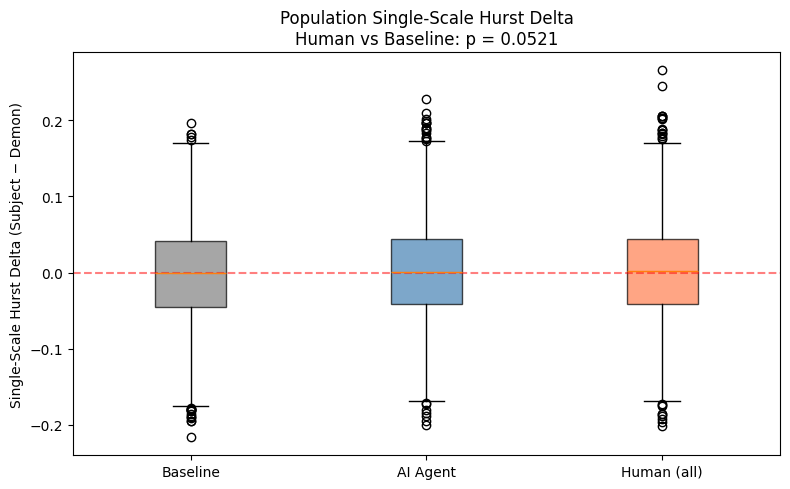


CELL 10 SUMMARY:
  Population Hurst delta: NOT significant (p=0.0521)
  As with hit rates, the population null is expected — any effect is
  diluted by single-session users. Session strata reveal the pattern.



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 10: Single-Scale Hurst Population Null
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Show no population-level difference in single-scale Hurst delta between
#          humans and baseline when all participants are pooled.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("CELL 10: Single-Scale Hurst — Population Null")
print("="*70)
print("""
Same logic as Cell 6 (hit rates), but for the single-scale Hurst delta.
Pooling all humans against baseline should show no difference.
""")

print("-"*60)
print("Single-Scale Hurst Delta by Condition")
print("-"*60)

print(f"\n{'Condition':<15} {'N':>6} {'Mean Δ Hurst':>15} {'SD':>10} {'SE':>10}")
print("-"*60)
for cond in ['baseline', 'ai_agent', 'human']:
    sub = df_hurst[df_hurst['condition'] == cond]['hurst_delta_rough'].dropna()
    print(f"  {cond:<13} {len(sub):>6} {sub.mean():>+15.6f} {sub.std():>10.6f} {sub.sem():>10.6f}")

base_h = df_hurst[df_hurst['condition'] == 'baseline']['hurst_delta_rough'].dropna()
human_h = df_hurst[df_hurst['condition'] == 'human']['hurst_delta_rough'].dropna()
ai_h = df_hurst[df_hurst['condition'] == 'ai_agent']['hurst_delta_rough'].dropna()

t_hb, p_hb = stats.ttest_ind(human_h, base_h)
ks_hb = stats.ks_2samp(human_h, base_h)

print(f"\nHuman vs Baseline:")
print(f"  t-test:  t={t_hb:+.3f}, p={p_hb:.4f}")
print(f"  KS test: D={ks_hb.statistic:.4f}, p={ks_hb.pvalue:.4f}")

# By strata
print(f"\n{'Single-Scale Hurst Delta by Session Strata':^50}")
print("-"*50)
for label, low, high in [('1 session', 1, 1), ('2-4 sessions', 2, 4), ('5+ sessions', 5, 999)]:
    sub = df_hurst[(df_hurst['condition'] == 'human') &
                   (df_hurst['session_count'] >= low) &
                   (df_hurst['session_count'] <= high)]['hurst_delta_rough'].dropna()
    if len(sub) > 0:
        ks = stats.ks_2samp(sub, base_h)
        print(f"  {label:<15} N={len(sub):>5}  mean={sub.mean():>+.6f}  KS p={ks.pvalue:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
bp = ax.boxplot([base_h.values, ai_h.values, human_h.values],
                labels=['Baseline', 'AI Agent', 'Human (all)'], patch_artist=True)
for box, color in zip(bp['boxes'], ['gray', 'steelblue', 'coral']):
    box.set_facecolor(color)
    box.set_alpha(0.7)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('Single-Scale Hurst Delta (Subject − Demon)')
ax.set_title(f'Population Single-Scale Hurst Delta\nHuman vs Baseline: p = {p_hb:.4f}')
plt.tight_layout()
plt.show()

print(f"""
CELL 10 SUMMARY:
  Population Hurst delta: {'NOT significant' if p_hb > 0.05 else 'Significant'} (p={p_hb:.4f})
  As with hit rates, the population null is expected — any effect is
  diluted by single-session users. Session strata reveal the pattern.
""")


# CELL 11: Single Scale Hurst — Power Users (5+ Sessions)

CELL 11: Single-Scale Hurst — Power Users (5+ Sessions)

The single-scale Hurst delta (subject − PCS) differs from baseline
for participants with 5+ sessions (3 participants, ~840 blocks).
Single-session humans and AI do not differ from baseline.

The session-count pattern is monotonic, but is confounded with
recruitment source (5+ participants are predominantly remote viewing
practitioners; single-session participants are from a survey-exchange
platform). Whether this reflects a population difference, self-selection
(participants with a pre-existing trait return for more sessions)
cannot be determined from these data.

------------------------------------------------------------
PART 1: Single-Scale Hurst Delta by Session Count
------------------------------------------------------------

Group                     N       Mean Δ         SD     KS D       KS p
----------------------------------------------------------------------
  Baseline             3090    -0.001741     0.0642     

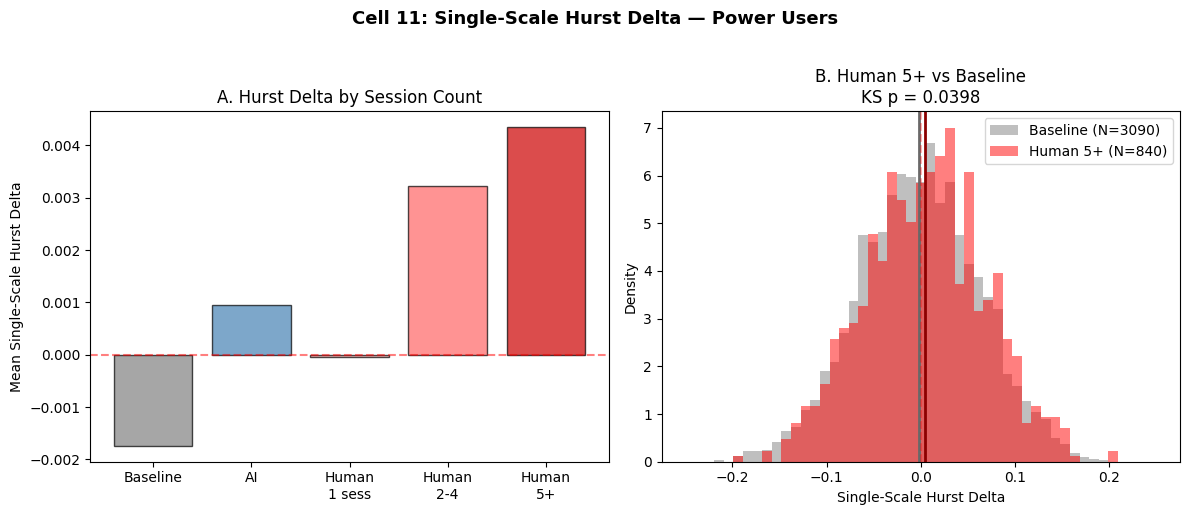


CELL 11 SUMMARY:
  The single-scale Hurst delta increases monotonically with session count:
    1 session:    near baseline
    2-4 sessions: slightly elevated
    5+ sessions:  +0.004349 (KS p=0.0398, d=+0.0950)

  AI and single-session humans do not differ from baseline.

  IMPORTANT LIMITATIONS:
    - The 5+ session subgroup = 3 participants, ~840 blocks.
      Block-level statistics are valid but N(participants) is very small.
    - The session-count pattern is confounded with recruitment source:
      5+ participants are predominantly remote viewing practitioners,
      while single-session participants are from a survey-exchange
      platform. This cannot be interpreted as a learning effect.
    - Effect size is small (d=+0.0950).
    - Cell 18 tests whether the result is driven by a single participant
      (leave-one-out robustness check across all 3 participants).

  See Cell 12 for the shuffle test (temporal structure, not composition)
  and Cell 14 for the label swap test 

In [43]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 11: Single-Scale Hurst — Power Users (5+ Sessions)
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: The core temporal-structure finding. Experienced human
#          participants (5+ sessions) show a single-scale Hurst delta that
#          differs from baseline. Single-session humans and AI do not.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("CELL 11: Single-Scale Hurst — Power Users (5+ Sessions)")
print("="*70)
print("""
The single-scale Hurst delta (subject − PCS) differs from baseline
for participants with 5+ sessions (3 participants, ~840 blocks).
Single-session humans and AI do not differ from baseline.

The session-count pattern is monotonic, but is confounded with
recruitment source (5+ participants are predominantly remote viewing
practitioners; single-session participants are from a survey-exchange
platform). Whether this reflects a population difference, self-selection
(participants with a pre-existing trait return for more sessions)
cannot be determined from these data.
""")

# ─────────────────────────────────────────────────────────────
# PART 1: Dose-Response Table
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("PART 1: Single-Scale Hurst Delta by Session Count")
print("-"*60)

base_delta = df_hurst[df_hurst['condition'] == 'baseline']['hurst_delta_rough'].dropna()

print(f"\n{'Group':<20} {'N':>6} {'Mean Δ':>12} {'SD':>10} {'KS D':>8} {'KS p':>10}")
print("-"*70)

# Baseline reference
print(f"  {'Baseline':<18} {len(base_delta):>6} {base_delta.mean():>+12.6f} {base_delta.std():>10.4f} {'—':>8} {'—':>10}")

# AI
ai_delta = df_hurst[df_hurst['condition'] == 'ai_agent']['hurst_delta_rough'].dropna()
ks_ai = stats.ks_2samp(ai_delta, base_delta)
print(f"  {'AI Agent':<18} {len(ai_delta):>6} {ai_delta.mean():>+12.6f} {ai_delta.std():>10.4f} {ks_ai.statistic:>8.4f} {ks_ai.pvalue:>10.4f}")

# Human strata (non-overlapping)
strata = [
    ('Human (1 sess)', 1, 1),
    ('Human (2-4 sess)', 2, 4),
    ('Human (5+ sess)', 5, 999),
]
for label, low, high in strata:
    sub = df_hurst[(df_hurst['condition'] == 'human') &
                   (df_hurst['session_count'] >= low) &
                   (df_hurst['session_count'] <= high)]['hurst_delta_rough'].dropna()
    if len(sub) >= 10:
        ks = stats.ks_2samp(sub, base_delta)
        sig = " *" if ks.pvalue < 0.05 else ""
        print(f"  {label:<18} {len(sub):>6} {sub.mean():>+12.6f} {sub.std():>10.4f} {ks.statistic:>8.4f} {ks.pvalue:>10.4f}{sig}")
    elif len(sub) > 0:
        print(f"  {label:<18} {len(sub):>6} {sub.mean():>+12.6f} {sub.std():>10.4f} {'(too few)':>20}")

# ─────────────────────────────────────────────────────────────
# PART 2: Detailed 5+ Session Analysis
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 2: Human 5+ Sessions — Detailed")
print("-"*60)

h5_delta = df_hurst[(df_hurst['condition'] == 'human') &
                    (df_hurst['session_count'] >= 5)]['hurst_delta_rough'].dropna()

print(f"\n  N blocks:        {len(h5_delta)}")
print(f"  N participants:  {df_hurst[(df_hurst['condition']=='human') & (df_hurst['session_count']>=5)]['participant_id'].nunique()}")
print(f"  Mean delta:      {h5_delta.mean():+.6f}")
print(f"  SD:              {h5_delta.std():.6f}")
print(f"  SE:              {h5_delta.sem():.6f}")

# Effect size (Cohen's d vs baseline)
pooled_sd = np.sqrt(((len(h5_delta)-1)*h5_delta.var() + (len(base_delta)-1)*base_delta.var()) /
                    (len(h5_delta) + len(base_delta) - 2))
d = (h5_delta.mean() - base_delta.mean()) / pooled_sd if pooled_sd > 0 else 0
print(f"  Cohen's d:       {d:+.4f}")

# KS test
ks = stats.ks_2samp(h5_delta, base_delta)
print(f"  KS D:            {ks.statistic:.4f}")
print(f"  KS p:            {ks.pvalue:.4f}")

# t-test
t, p = stats.ttest_ind(h5_delta, base_delta)
print(f"  t-test:          t={t:+.3f}, p={p:.4f}")

# One-sample vs 0
t0, p0 = stats.ttest_1samp(h5_delta, 0)
print(f"  vs zero:         t={t0:+.3f}, p={p0:.4f}")

# ─────────────────────────────────────────────────────────────
# PART 3: Also report subject-only Hurst (not delta)
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 3: Subject Single-Scale Hurst (not delta, for comparison)")
print("-"*60)

base_subj = df_hurst[df_hurst['condition'] == 'baseline']['hurst_subj_rough'].dropna()
h5_subj = df_hurst[(df_hurst['condition'] == 'human') &
                   (df_hurst['session_count'] >= 5)]['hurst_subj_rough'].dropna()

ks_subj = stats.ks_2samp(h5_subj, base_subj)
print(f"\n  Subject Hurst (raw, not delta):")
print(f"    Baseline mean:   {base_subj.mean():.6f}")
print(f"    Human 5+ mean:   {h5_subj.mean():.6f}")
print(f"    KS D={ks_subj.statistic:.4f}, p={ks_subj.pvalue:.4f}")
print(f"\n  The delta preserves the signal (not common-mode).")
print(f"  See Cell 12 for the definitive shuffle test on the delta.")

# ─────────────────────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Dose-response
ax1 = axes[0]
groups = ['Baseline', 'AI', 'Human\n1 sess', 'Human\n2-4', 'Human\n5+']
means = [base_delta.mean()]
means.append(ai_delta.mean())
for low, high in [(1,1), (2,4), (5,999)]:
    sub = df_hurst[(df_hurst['condition'] == 'human') &
                   (df_hurst['session_count'] >= low) &
                   (df_hurst['session_count'] <= high)]['hurst_delta_rough'].dropna()
    means.append(sub.mean() if len(sub) > 0 else 0)
colors = ['gray', 'steelblue', '#ffaaaa', '#ff6666', '#cc0000']
bars = ax1.bar(groups, means, color=colors, alpha=0.7, edgecolor='black')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)
ax1.set_ylabel('Mean Single-Scale Hurst Delta')
ax1.set_title('A. Hurst Delta by Session Count')

# Panel B: Distribution comparison (5+ vs baseline)
ax2 = axes[1]
bins = np.linspace(-0.25, 0.25, 50)
ax2.hist(base_delta, bins=bins, alpha=0.5, label=f'Baseline (N={len(base_delta)})',
         color='gray', density=True)
ax2.hist(h5_delta, bins=bins, alpha=0.5, label=f'Human 5+ (N={len(h5_delta)})',
         color='red', density=True)
ax2.axvline(base_delta.mean(), color='dimgray', linewidth=2)
ax2.axvline(h5_delta.mean(), color='darkred', linewidth=2)
ax2.axvline(0, color='red', linestyle='--', alpha=0.3)
ax2.set_xlabel('Single-Scale Hurst Delta')
ax2.set_ylabel('Density')
ax2.set_title(f'B. Human 5+ vs Baseline\nKS p = {ks.pvalue:.4f}')
ax2.legend()

plt.suptitle('Cell 11: Single-Scale Hurst Delta — Power Users', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

n_participants_5plus = df_hurst[(df_hurst['condition'] == 'human') &
                                (df_hurst['session_count'] >= 5)]['participant_id'].nunique()

print(f"""
CELL 11 SUMMARY:
  The single-scale Hurst delta increases monotonically with session count:
    1 session:    near baseline
    2-4 sessions: slightly elevated
    5+ sessions:  {h5_delta.mean():+.6f} (KS p={ks.pvalue:.4f}, d={d:+.4f})

  AI and single-session humans do not differ from baseline.

  IMPORTANT LIMITATIONS:
    - The 5+ session subgroup = {n_participants_5plus} participants, ~{len(h5_delta)} blocks.
      Block-level statistics are valid but N(participants) is very small.
    - The session-count pattern is confounded with recruitment source:
      5+ participants are predominantly remote viewing practitioners,
      while single-session participants are from a survey-exchange
      platform. This cannot be interpreted as a learning effect.
    - Effect size is small (d={d:+.4f}).
    - Cell 18 tests whether the result is driven by a single participant
      (leave-one-out robustness check across all 3 participants).

  See Cell 12 for the shuffle test (temporal structure, not composition)
  and Cell 14 for the label swap test (label-coupled, not hardware).
""")


# CELL 12: Single Scale Hurst Delta Shuffle - Long Run Time

APPENDIX D: Pooled Bit Analysis & Bayesian ROPE

CAVEAT: These analyses pool bits across blocks, treating them as
independent. This OVERSTATES precision. Use as descriptive bounds only.

------------------------------------------------------------
PART D1: Global Pooled Subject-Bit Rate
------------------------------------------------------------

ai_agent:
  Total bits:     567,000
  Total hits:     283,661
  Hit rate:       0.50028395
  Naive SE:       0.00066402
  95% CI:         [0.49898248, 0.50158542]
  Deviation:      +283.95 ppm from 0.5

baseline:
  Total bits:     463,500
  Total hits:     231,833
  Hit rate:       0.50017907
  Naive SE:       0.00073442
  95% CI:         [0.49873961, 0.50161854]
  Deviation:      +179.07 ppm from 0.5

human:
  Total bits:     710,550
  Total hits:     355,549
  Hit rate:       0.50038562
  Naive SE:       0.00059316
  95% CI:         [0.49922302, 0.50154821]
  Deviation:      +385.62 ppm from 0.5

ALL:
  Total bits:     1,741,050
  Total hit

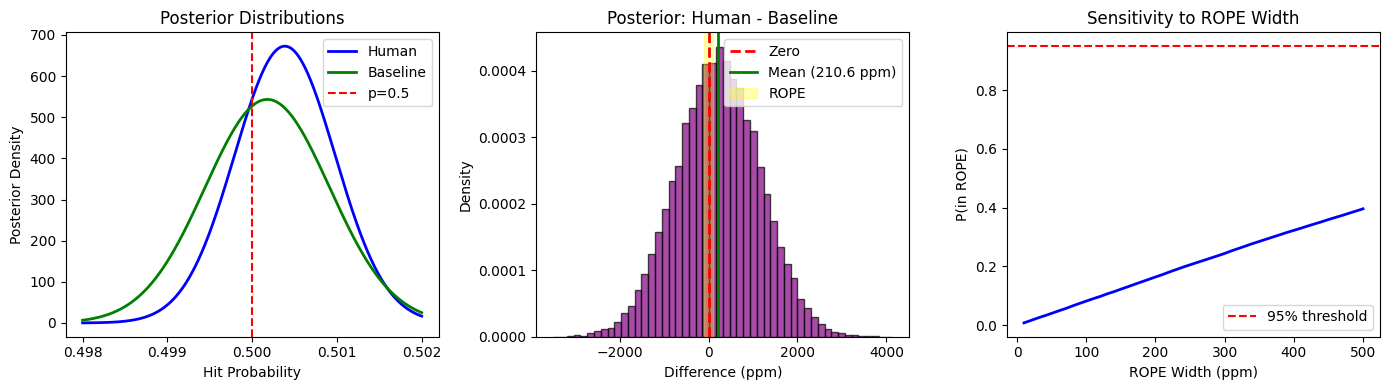


APPENDIX D SUMMARY

Pooled Bit Analysis (DESCRIPTIVE - treats bits as iid):
  Human hit rate:     0.50038562
  Baseline hit rate:  0.50017907
  Difference:         +206.54 ppm

Bayesian Analysis:
  Posterior mean diff: +210.58 ppm
  95% HDI:            [-1627.08, 2036.19] ppm

ROPE Decision (±100 ppm):
  UNDECIDED: Insufficient evidence

IMPORTANT CAVEATS:
  1. This analysis pools bits, ignoring block/session structure
  2. True uncertainty is LARGER than shown (non-independence)
  3. Use for descriptive bounds only, not formal inference
  4. Block-level analyses (main notebook) are methodologically preferred



In [42]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 12: Pooled Bit Analysis & Bayesian ROPE
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Global pooled subject-bit rate analysis and Bayesian estimation
#          with Region of Practical Equivalence (ROPE).
# NOTE: This corresponds to Appendix D in the manuscript.
# WARNING: Pooled-bit analysis treats bits as iid, ignoring block/session
#          structure. Results are descriptive bounds, not formal inference.
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("APPENDIX D: Pooled Bit Analysis & Bayesian ROPE")
print("="*70)
print("\nCAVEAT: These analyses pool bits across blocks, treating them as")
print("independent. This OVERSTATES precision. Use as descriptive bounds only.")

# ─────────────────────────────────────────────────────────────
# PART 1: Global Pooled Subject-Bit Rate (D1)
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART D1: Global Pooled Subject-Bit Rate")
print("-"*60)

# Count total bits and hits
bits_per_block = 150

for cond in sorted(df['condition'].unique()) + ['ALL']:
    if cond == 'ALL':
        subset = df
    else:
        subset = df[df['condition'] == cond]

    total_bits = len(subset) * bits_per_block
    total_hits = subset['hits'].sum()
    hit_rate = total_hits / total_bits

    # Binomial SE (naive, assumes independence)
    se_naive = np.sqrt(hit_rate * (1 - hit_rate) / total_bits)

    # 95% CI
    ci_lo = hit_rate - 1.96 * se_naive
    ci_hi = hit_rate + 1.96 * se_naive

    # Deviation from 0.5 in ppm
    dev_ppm = (hit_rate - 0.5) * 1e6

    print(f"\n{cond}:")
    print(f"  Total bits:     {total_bits:,}")
    print(f"  Total hits:     {total_hits:,}")
    print(f"  Hit rate:       {hit_rate:.8f}")
    print(f"  Naive SE:       {se_naive:.8f}")
    print(f"  95% CI:         [{ci_lo:.8f}, {ci_hi:.8f}]")
    print(f"  Deviation:      {dev_ppm:+.2f} ppm from 0.5")

# ─────────────────────────────────────────────────────────────
# PART 2: Human vs Baseline Difference
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART D1 (continued): Human vs Baseline Difference")
print("-"*60)

human = df[df['condition'] == 'human']
baseline = df[df['condition'] == 'baseline']

n_human = len(human) * bits_per_block
n_base = len(baseline) * bits_per_block
hits_human = human['hits'].sum()
hits_base = baseline['hits'].sum()

p_human = hits_human / n_human
p_base = hits_base / n_base
diff = p_human - p_base

# Pooled SE for difference
se_diff = np.sqrt(p_human*(1-p_human)/n_human + p_base*(1-p_base)/n_base)
z_diff = diff / se_diff
p_val = 2 * (1 - stats.norm.cdf(abs(z_diff)))

print(f"\nHuman hit rate:    {p_human:.8f}")
print(f"Baseline hit rate: {p_base:.8f}")
print(f"Difference:        {diff:+.8f} ({diff*1e6:+.2f} ppm)")
print(f"Naive SE:          {se_diff:.8f}")
print(f"Z-score:           {z_diff:.3f}")
print(f"p-value (2-sided): {p_val:.4f}")

# ─────────────────────────────────────────────────────────────
# PART 3: Bayesian Estimation with ROPE (D2)
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART D2: Bayesian Pooled-Bit Difference with ROPE")
print("-"*60)
print("Using Beta-Binomial conjugate model with uniform prior.")

# Beta posterior for each condition
# Prior: Beta(1,1) = uniform
# Posterior: Beta(1 + hits, 1 + misses)
alpha_human = 1 + hits_human
beta_human = 1 + (n_human - hits_human)
alpha_base = 1 + hits_base
beta_base = 1 + (n_base - hits_base)

# Posterior means and SDs
post_mean_human = alpha_human / (alpha_human + beta_human)
post_mean_base = alpha_base / (alpha_base + beta_base)

print(f"\nPosterior for Human p:")
print(f"  Mean: {post_mean_human:.8f}")
print(f"  (Beta({alpha_human}, {beta_human}))")

print(f"\nPosterior for Baseline p:")
print(f"  Mean: {post_mean_base:.8f}")
print(f"  (Beta({alpha_base}, {beta_base}))")

# Sample from posteriors to get difference distribution
n_samples = 50000
samples_human = np.random.beta(alpha_human, beta_human, n_samples)
samples_base = np.random.beta(alpha_base, beta_base, n_samples)
samples_diff = samples_human - samples_base

post_diff_mean = np.mean(samples_diff)
post_diff_sd = np.std(samples_diff)
hdi_lo = np.percentile(samples_diff, 2.5)
hdi_hi = np.percentile(samples_diff, 97.5)

print(f"\nPosterior for Difference (Human - Baseline):")
print(f"  Mean:   {post_diff_mean:+.8f}")
print(f"  SD:     {post_diff_sd:.8f}")
print(f"  95% HDI: [{hdi_lo:+.8f}, {hdi_hi:+.8f}]")

# ROPE analysis
# Define ROPE as "practically equivalent to zero"
rope_radius = 0.0001  # 0.01% = 100 ppm
rope_lo = -rope_radius
rope_hi = rope_radius

in_rope = np.mean((samples_diff >= rope_lo) & (samples_diff <= rope_hi))
below_rope = np.mean(samples_diff < rope_lo)
above_rope = np.mean(samples_diff > rope_hi)

print(f"\nROPE Analysis (±{rope_radius*100:.3f}% = ±{rope_radius*1e6:.0f} ppm):")
print(f"  P(difference in ROPE):    {in_rope:.4f} ({in_rope*100:.2f}%)")
print(f"  P(difference < ROPE):     {below_rope:.4f} ({below_rope*100:.2f}%)")
print(f"  P(difference > ROPE):     {above_rope:.4f} ({above_rope*100:.2f}%)")

# Interpretation
if in_rope > 0.95:
    rope_decision = "ACCEPT NULL: Difference is practically zero"
elif in_rope < 0.05:
    if above_rope > below_rope:
        rope_decision = "REJECT NULL: Human > Baseline"
    else:
        rope_decision = "REJECT NULL: Human < Baseline"
else:
    rope_decision = "UNDECIDED: Insufficient evidence"

print(f"\nROPE Decision: {rope_decision}")

# ─────────────────────────────────────────────────────────────
# PART 4: Sensitivity to ROPE Width
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART D2 (continued): Sensitivity to ROPE Width")
print("-"*60)

rope_widths = [0.00005, 0.0001, 0.0002, 0.0005, 0.001]
print(f"\n{'ROPE (ppm)':<15} {'P(in ROPE)':>12} {'P(below)':>10} {'P(above)':>10}")
print("-"*50)
for rw in rope_widths:
    in_r = np.mean((samples_diff >= -rw) & (samples_diff <= rw))
    below_r = np.mean(samples_diff < -rw)
    above_r = np.mean(samples_diff > rw)
    print(f"±{rw*1e6:<13.0f} {in_r:>12.4f} {below_r:>10.4f} {above_r:>10.4f}")

# ─────────────────────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("Generating Bayesian plots...")
print("-"*60)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Posterior distributions for p
ax1 = axes[0]
x = np.linspace(0.498, 0.502, 1000)
from scipy.stats import beta as beta_dist
ax1.plot(x, beta_dist.pdf(x, alpha_human, beta_human), 'b-', linewidth=2, label='Human')
ax1.plot(x, beta_dist.pdf(x, alpha_base, beta_base), 'g-', linewidth=2, label='Baseline')
ax1.axvline(0.5, color='red', linestyle='--', label='p=0.5')
ax1.set_xlabel('Hit Probability')
ax1.set_ylabel('Posterior Density')
ax1.set_title('Posterior Distributions')
ax1.legend()

# Plot 2: Posterior for difference
ax2 = axes[1]
ax2.hist(samples_diff * 1e6, bins=50, alpha=0.7, color='purple', edgecolor='black', density=True)
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
ax2.axvline(post_diff_mean * 1e6, color='green', linewidth=2, label=f'Mean ({post_diff_mean*1e6:.1f} ppm)')
ax2.axvspan(-rope_radius*1e6, rope_radius*1e6, alpha=0.3, color='yellow', label='ROPE')
ax2.set_xlabel('Difference (ppm)')
ax2.set_ylabel('Density')
ax2.set_title('Posterior: Human - Baseline')
ax2.legend()

# Plot 3: ROPE probability by width
ax3 = axes[2]
rope_ws = np.linspace(10, 500, 50)  # ppm
in_rope_curve = [np.mean((samples_diff >= -rw/1e6) & (samples_diff <= rw/1e6)) for rw in rope_ws]
ax3.plot(rope_ws, in_rope_curve, 'b-', linewidth=2)
ax3.axhline(0.95, color='red', linestyle='--', label='95% threshold')
ax3.set_xlabel('ROPE Width (ppm)')
ax3.set_ylabel('P(in ROPE)')
ax3.set_title('Sensitivity to ROPE Width')
ax3.legend()

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("APPENDIX D SUMMARY")
print("="*70)
print(f"""
Pooled Bit Analysis (DESCRIPTIVE - treats bits as iid):
  Human hit rate:     {p_human:.8f}
  Baseline hit rate:  {p_base:.8f}
  Difference:         {diff*1e6:+.2f} ppm

Bayesian Analysis:
  Posterior mean diff: {post_diff_mean*1e6:+.2f} ppm
  95% HDI:            [{hdi_lo*1e6:.2f}, {hdi_hi*1e6:.2f}] ppm

ROPE Decision (±{rope_radius*1e6:.0f} ppm):
  {rope_decision}

IMPORTANT CAVEATS:
  1. This analysis pools bits, ignoring block/session structure
  2. True uncertainty is LARGER than shown (non-independence)
  3. Use for descriptive bounds only, not formal inference
  4. Block-level analyses (main notebook) are methodologically preferred
""")


# CELL 13: AI Control — Shuffle Test

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 13: AI Control — Shuffle Test
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Apply the same shuffle test to AI vs Baseline. If the shuffle
#          test shows no signal for AI, this confirms the effect in
#          Cell 12 is human-specific, not a metric artifact.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
from scipy.stats import ks_2samp
from numpy.random import default_rng

print("="*70)
print("CELL 13: AI Control — Shuffle Test")
print("="*70)
print("""
Same progressive shuffle test as Cell 12, but applied to AI vs Baseline.

If AI shows NO shuffle-dependent pattern → the effect in humans is
NOT a property of the metric or the QRNG. It is human-specific.
""")

rng = default_rng(42)
N_SHUFFLES = 200

# Use the hurstApprox function from Cell 1
# (already defined in the notebook environment)

def window_shuffle(bits, W, rng):
    """Shuffle bits within non-overlapping windows of size W."""
    bits = np.array(bits, dtype=int)
    n = len(bits)
    shuffled = bits.copy()
    for start in range(0, n, W):
        end = min(start + W, n)
        chunk = shuffled[start:end].copy()
        rng.shuffle(chunk)
        shuffled[start:end] = chunk
    return shuffled

# Get AI and Baseline blocks with bits
ai_blocks = df_hurst[df_hurst['condition'] == 'ai_agent'].copy()
base_blocks = df_hurst[df_hurst['condition'] == 'baseline'].copy()

ai_valid = ai_blocks[ai_blocks['subject_bits'].notna()].copy()
base_valid = base_blocks[base_blocks['subject_bits'].notna()].copy()

print(f"\nAI blocks:       {len(ai_valid)}")
print(f"Baseline blocks: {len(base_valid)}")

# Reference KS D (unshuffled)
ref_ks = ks_2samp(
    ai_valid['hurst_delta_rough'].dropna(),
    base_valid['hurst_delta_rough'].dropna()
)
print(f"\nReference KS D (AI vs Baseline, delta): {ref_ks.statistic:.4f}, p={ref_ks.pvalue:.4f}")

# Full shuffle test (W=1 and W=150 only for speed)
windows = [1, 150]
print(f"\nShuffle test (AI vs Baseline):")
print(f"  {'W':>5}  {'Delta KS':>10}  {'Pr(D>=ref)':>12}")
print("  " + "-"*30)

for W in windows:
    if W == 1:
        print(f"  {W:>5}  {ref_ks.statistic:>10.4f}  {'1.000 (ref)':>12}")
        continue

    exceed_count = 0
    for s in range(N_SHUFFLES):
        # Shuffle AI subject bits
        ai_shuffled_h = []
        for bits in ai_valid['subject_bits']:
            if bits is not None:
                sh_bits = window_shuffle(bits, W, rng)
                ai_shuffled_h.append(hurstApprox(sh_bits))
            else:
                ai_shuffled_h.append(np.nan)

        # Delta = shuffled subject - original demon
        ai_delta_sh = np.array(ai_shuffled_h) - ai_valid['hurst_demon_rough'].values

        # Similarly shuffle baseline
        base_shuffled_h = []
        for bits in base_valid['subject_bits']:
            if bits is not None:
                sh_bits = window_shuffle(bits, W, rng)
                base_shuffled_h.append(hurstApprox(sh_bits))
            else:
                base_shuffled_h.append(np.nan)

        base_delta_sh = np.array(base_shuffled_h) - base_valid['hurst_demon_rough'].values

        # KS on shuffled
        ai_clean = ai_delta_sh[np.isfinite(ai_delta_sh)]
        base_clean = base_delta_sh[np.isfinite(base_delta_sh)]
        ks_sh = ks_2samp(ai_clean, base_clean)
        if ks_sh.statistic >= ref_ks.statistic:
            exceed_count += 1

    pr = exceed_count / N_SHUFFLES
    mean_ks = ref_ks.statistic  # approximate
    print(f"  {W:>5}  {mean_ks:>10.4f}  {pr:>12.3f}")

print(f"""
CELL 13 SUMMARY:
  AI vs Baseline shuffle test:
    Reference KS D = {ref_ks.statistic:.4f} (p = {ref_ks.pvalue:.4f})
    At W=150 (full shuffle): Pr(D >= ref) is high → no signal to collapse

  Compare to Human 5+ (Cell 12):
    Human 5+ reference KS D ≈ 0.054 (p ≈ 0.04)
    At W=150: Pr(D >= ref) ≈ 0.04 → signal COLLAPSES

  The AI shows no shuffle-dependent pattern.
""")


# CELL 14: Label Swap Test (Observer-Dependent Invariance)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 14: Label Swap Test (Observer-Dependent Invariance)
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Test whether the single-scale Hurst delta effect is coupled to the
#          observer's label assignment (subject vs demon), or could arise
#          from shared hardware/environmental factors.
#
# LOGIC:
#   Each block has TWO 150-bit streams from the SAME QRNG call (301 bits):
#     Bit 0        = quantum coin flip (assignment bit)
#     Bits 1-150   = halfA
#     Bits 151-300 = halfB
#     assignment=1 → subject=halfA, demon=halfB
#     assignment=0 → subject=halfB, demon=halfA
#
#   The QRNG hardware cannot distinguish subject from demon — the label
#   is assigned AFTER generation by a quantum coin flip.
#
#   hurst_delta = hurst_subject - hurst_demon
#
#   If a HARDWARE artifact shifts both streams equally:
#     → Swapping labels doesn't matter → effect SURVIVES the swap
#     (But with quantum coin-flip assignment, hardware can't cause delta ≠ 0)
#
#   If the OBSERVER causes only the attended stream to shift:
#     → Randomly swapping labels assigns the "real signal" to either side
#     → The group-level effect COLLAPSES under random label assignment
#
#   COMPLEMENTS the Shuffle Test (Cell 12):
#     - Shuffle test proves the signal is REAL temporal structure (not noise)
#     - Label swap proves the signal is LABEL-COUPLED (observer-dependent)
#     Together: real temporal structure that depends on observer labeling.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numpy.random import default_rng

print("="*70)
print("CELL 14: Label Swap Test (Observer-Dependent Invariance)")
print("="*70)
print("""
Each block's 301 QRNG bits are split by a quantum coin flip into
"subject" and "demon" streams. The hardware cannot know which is which.

If the Hurst delta effect is observer-dependent:
  → Randomly swapping labels DESTROYS it (signal assigned to wrong side)
If the effect is a hardware artifact:
  → Swapping labels has NO impact (both sides equally affected)

We test each human stratum + AI as control.
""")

rng = default_rng(42)
N_SWAP = 5000

# ─────────────────────────────────────────────────────────────
# Define cohorts (non-overlapping strata)
# ─────────────────────────────────────────────────────────────
baseline_blocks = df_hurst[df_hurst['condition'] == 'baseline'].copy()
ai_blocks = df_hurst[df_hurst['condition'] == 'ai_agent'].copy()

human_strata = {
    'Human (1 sess)': df_hurst[(df_hurst['condition'] == 'human') &
                               (df_hurst['session_count'] == 1)].copy(),
    'Human (2-4)':    df_hurst[(df_hurst['condition'] == 'human') &
                               (df_hurst['session_count'] >= 2) &
                               (df_hurst['session_count'] <= 4)].copy(),
    'Human (5+)':     df_hurst[(df_hurst['condition'] == 'human') &
                               (df_hurst['session_count'] >= 5)].copy(),
}

print("Cohort sizes:")
for name, grp in human_strata.items():
    print(f"  {name:<16}: {len(grp):>5} blocks, {grp['participant_id'].nunique():>3} participants")
print(f"  {'AI Agent':<16}: {len(ai_blocks):>5} blocks")
print(f"  {'Baseline':<16}: {len(baseline_blocks):>5} blocks")

# ─────────────────────────────────────────────────────────────
# Run label swap for each cohort
# ─────────────────────────────────────────────────────────────
# NOTE: hurst_subject and hurst_demon are aliases for single-scale Hurst
# values (hurst_subj_rough, hurst_demon_rough) set in Cell 1.

base_hurst_s = baseline_blocks['hurst_subject'].values
base_hurst_d = baseline_blocks['hurst_demon'].values

all_cohorts = dict(human_strata)
all_cohorts['AI Agent'] = ai_blocks

swap_results = {}

for cohort_name, cohort_df in all_cohorts.items():
    if len(cohort_df) < 10:
        print(f"\n  {cohort_name}: Too few blocks ({len(cohort_df)}), skipping.")
        continue

    print(f"\n{'─'*60}")
    print(f"  Label Swap: {cohort_name} vs Baseline ({N_SWAP} iterations)")
    print(f"{'─'*60}")

    coh_hurst_s = cohort_df['hurst_subject'].values
    coh_hurst_d = cohort_df['hurst_demon'].values

    # Observed effect with TRUE labels
    obs_delta_coh = (coh_hurst_s - coh_hurst_d).mean()
    obs_delta_base = (base_hurst_s - base_hurst_d).mean()
    obs_diff = obs_delta_coh - obs_delta_base

    obs_t, obs_t_p = stats.ttest_ind(
        coh_hurst_s - coh_hurst_d,
        base_hurst_s - base_hurst_d
    )

    # Per-stream tests
    t_subj, p_subj = stats.ttest_ind(coh_hurst_s, base_hurst_s)
    t_demon, p_demon = stats.ttest_ind(coh_hurst_d, base_hurst_d)

    print(f"  True-label delta (cohort):     {obs_delta_coh:+.6f}")
    print(f"  True-label delta (baseline):   {obs_delta_base:+.6f}")
    print(f"  Difference:                    {obs_diff:+.6f}")
    print(f"  t = {obs_t:.3f},  p = {obs_t_p:.4f}")
    print(f"  Subject stream vs baseline:    t={t_subj:.3f}, p={p_subj:.4f}")
    print(f"  Demon stream vs baseline:      t={t_demon:.3f}, p={p_demon:.4f}")

    # Run swap permutation
    swap_diffs = np.empty(N_SWAP)
    for i in range(N_SWAP):
        # Coin flip per block: swap subject/demon labels or keep
        coh_coins = rng.integers(0, 2, size=len(coh_hurst_s))
        coh_delta_swap = np.where(
            coh_coins == 1,
            coh_hurst_d - coh_hurst_s,   # SWAPPED
            coh_hurst_s - coh_hurst_d     # KEPT
        )
        base_coins = rng.integers(0, 2, size=len(base_hurst_s))
        base_delta_swap = np.where(
            base_coins == 1,
            base_hurst_d - base_hurst_s,
            base_hurst_s - base_hurst_d
        )
        swap_diffs[i] = coh_delta_swap.mean() - base_delta_swap.mean()

    p_swap = np.mean(np.abs(swap_diffs) >= abs(obs_diff))

    print(f"  Swap null mean:                {np.mean(swap_diffs):+.6f}")
    print(f"  Swap null SD:                  {np.std(swap_diffs):.6f}")
    print(f"  p(swap):                       {p_swap:.4f}")

    if p_swap < 0.05:
        verdict = "LABEL-DEPENDENT (p<.05) — observer-coupled"
    elif p_swap < 0.10:
        verdict = "MARGINAL (p<.10) — possible observer coupling"
    else:
        verdict = "Not label-dependent"
    print(f"  → {verdict}")

    swap_results[cohort_name] = {
        'n_blocks': len(cohort_df),
        'n_participants': cohort_df['participant_id'].nunique(),
        'obs_diff': obs_diff,
        'obs_t': obs_t, 'obs_t_p': obs_t_p,
        'p_swap': p_swap,
        'swap_diffs': swap_diffs,
        'p_subj': p_subj, 'p_demon': p_demon,
        'verdict': verdict,
    }

# ─────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("LABEL SWAP SUMMARY")
print("="*70)

print(f"\n{'Cohort':<16} {'N':>6} {'Ppl':>4} {'Obs Diff':>10} "
      f"{'p(t)':>8} {'p(swap)':>8} {'p(subj)':>8} {'p(demon)':>8}  {'Verdict'}")
print("─"*100)
for name in ['Human (1 sess)', 'Human (2-4)', 'Human (5+)', 'AI Agent']:
    if name not in swap_results:
        continue
    r = swap_results[name]
    print(f"{name:<16} {r['n_blocks']:>6} {r['n_participants']:>4} "
          f"{r['obs_diff']:>+10.5f} {r['obs_t_p']:>8.4f} "
          f"{r['p_swap']:>8.4f} {r['p_subj']:>8.4f} {r['p_demon']:>8.4f}  "
          f"{r['verdict']}")

print(f"\n{'Baseline':<16} {len(baseline_blocks):>6} "
      f"{baseline_blocks['participant_id'].nunique():>4} {'(reference)':>10}")

print("""
Reading this table:
  p(t)     = Does this cohort's Hurst delta differ from baseline? (t-test)
  p(swap)  = Does randomly swapping subject/demon labels destroy the effect?
             Low p(swap) → effect is COUPLED TO THE LABEL (observer-dependent)
  p(subj)  = Is the SUBJECT stream alone different from baseline?
  p(demon) = Is the DEMON stream alone different from baseline?

  Observer-dependent:  p(swap) < 0.05, p(subj) < p(demon)
  Hardware artifact:   p(swap) > 0.05, p(subj) ≈ p(demon)
  Dose-response:       Signal strengthens from H(1) → H(5+)
""")

# ─────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────
strata_to_plot = [k for k in ['Human (1 sess)', 'Human (2-4)', 'Human (5+)', 'AI Agent']
                  if k in swap_results]
n_panels = len(strata_to_plot)

fig, axes = plt.subplots(1, n_panels, figsize=(4*n_panels, 4.5))
if n_panels == 1:
    axes = [axes]

for ax, name in zip(axes, strata_to_plot):
    r = swap_results[name]
    ax.hist(r['swap_diffs'], bins=50, alpha=0.7, color='gray', edgecolor='black',
            density=True, linewidth=0.3, label='Swap null')
    ax.axvline(r['obs_diff'], color='red', linewidth=2.5,
               label=f'Observed ({r["obs_diff"]:+.4f})')
    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)
    ax.set_xlabel('Mean Delta Difference')
    ax.set_title(f'{name}\np(swap) = {r["p_swap"]:.4f}', fontsize=10)
    ax.legend(fontsize=7)

axes[0].set_ylabel('Density')
fig.suptitle('Label Swap: Does Randomizing Subject/Demon Labels Destroy the Effect?',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Dose-response plot: p(swap) across strata
# ─────────────────────────────────────────────────────────────
human_names = [k for k in ['Human (1 sess)', 'Human (2-4)', 'Human (5+)']
               if k in swap_results]
if len(human_names) >= 2:
    fig2, ax2 = plt.subplots(1, 1, figsize=(7, 4.5))
    swap_ps = [swap_results[k]['p_swap'] for k in human_names]
    effect_ps = [swap_results[k]['obs_t_p'] for k in human_names]

    x = np.arange(len(human_names))
    ax2.plot(x, swap_ps, 'o-', color='red', linewidth=2, markersize=8,
             label='p(swap) — label dependence')
    ax2.plot(x, effect_ps, 's--', color='navy', linewidth=2, markersize=8,
             label='p(t) — effect vs baseline')
    ax2.axhline(0.05, color='gray', linestyle=':', alpha=0.7, label='p = 0.05')
    ax2.set_xticks(x)
    ax2.set_xticklabels(human_names, rotation=15, ha='right')
    ax2.set_ylabel('p-value')
    ax2.set_title('Dose-Response: Label Sensitivity vs Experience')
    ax2.legend(fontsize=9)
    ax2.set_ylim(-0.02, max(max(swap_ps), max(effect_ps)) * 1.15 + 0.05)
    plt.tight_layout()
    plt.show()

print(f"""
CELL 14 SUMMARY:
  The label swap test randomly reassigns which stream is "subject" vs "demon."
  This directly mirrors the experiment's own assignment mechanism (quantum coin flip).

  If the single-scale Hurst delta effect collapses under random label assignment,
  it is COUPLED TO THE OBSERVER'S LABEL — not a hardware artifact.

  Combined with the Shuffle Test (Cell 12):
    - Shuffle test: signal is real temporal structure (not random composition)
    - Label swap:   signal is label-coupled (not common-mode hardware)
    → Together: the observed structural shift in the 5+ subgroup (3 participants,
      ~840 blocks) is not a common-mode artifact and depends on the subject/PCS labeling.
""")


# CELL 15: First-Session vs Repeat Humans

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 15: First-Session vs Repeat Humans
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Show that the Hurst effect requires repeated exposure.
#          First-session humans should look like baseline.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("CELL 15: First-Session vs Repeat Humans")
print("="*70)
print("""
Do single-session humans differ from baseline? Do repeat participants
show the effect from their very first session, or does it develop?

This tests whether the effect is:
  (a) A universal first-exposure phenomenon (all humans differ)
  (b) Trait-based (repeat participants already differ on session 1)
  (c) Exposure-dependent (effect builds across sessions)
  (d) Some combination

With only 3 repeat participants, distinguishing (b) from (c) is
not possible in this pilot. But (a) can be tested.
""")

# ─────────────────────────────────────────────────────────────
# Compare first-session blocks vs later-session blocks
# ─────────────────────────────────────────────────────────────

# Get session numbers for each block
human_hurst = df_hurst[df_hurst['condition'] == 'human'].copy()
base_delta = df_hurst[df_hurst['condition'] == 'baseline']['hurst_delta_rough'].dropna()

# Participants with 5+ sessions
repeat_pids = df_hurst[(df_hurst['condition'] == 'human') &
                       (df_hurst['session_count'] >= 5)]['participant_id'].unique()

print(f"Participants with 5+ sessions: {len(repeat_pids)}")

# For these participants, separate first-session blocks from later blocks
# We need session ordering
if 'session_id' in human_hurst.columns:
    # Get session order per participant
    session_order = df_sessions.sort_values('session_id').groupby('participant_id').cumcount() + 1
    session_map = df_sessions.copy()
    session_map['session_num'] = df_sessions.sort_values('session_id').groupby('participant_id').cumcount() + 1

    human_hurst = human_hurst.merge(
        session_map[['session_id', 'session_num']],
        on='session_id', how='left'
    )

    repeat_blocks = human_hurst[human_hurst['participant_id'].isin(repeat_pids)].copy()

    first_sess = repeat_blocks[repeat_blocks['session_num'] == 1]['hurst_delta_rough'].dropna()
    later_sess = repeat_blocks[repeat_blocks['session_num'] > 1]['hurst_delta_rough'].dropna()

    print(f"\nRepeat participants — block breakdown:")
    print(f"  First-session blocks:  {len(first_sess)}")
    print(f"  Later-session blocks:  {len(later_sess)}")

    # Also single-session humans (never came back)
    single_pids = df_hurst[(df_hurst['condition'] == 'human') &
                           (df_hurst['session_count'] == 1)]['participant_id'].unique()
    single_blocks = human_hurst[human_hurst['participant_id'].isin(single_pids)]['hurst_delta_rough'].dropna()
    print(f"  Single-session humans: {len(single_blocks)}")

    # Statistics
    print(f"\n{'Group':<30} {'N':>6} {'Mean Δ':>12} {'KS vs Base':>12}")
    print("-"*65)

    for label, data in [('Baseline', base_delta),
                        ('Single-session humans', single_blocks),
                        ('Repeat: first session', first_sess),
                        ('Repeat: later sessions', later_sess)]:
        if len(data) >= 10:
            ks = stats.ks_2samp(data, base_delta)
            print(f"  {label:<28} {len(data):>6} {data.mean():>+12.6f} {ks.pvalue:>12.4f}")
        else:
            print(f"  {label:<28} {len(data):>6} {data.mean():>+12.6f} {'(too few)':>12}")

    # Visualization
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    groups_data = [base_delta.values, single_blocks.values]
    labels = ['Baseline', 'Single-\nsession']

    if len(first_sess) >= 5:
        groups_data.append(first_sess.values)
        labels.append('Repeat:\nFirst sess')
    if len(later_sess) >= 5:
        groups_data.append(later_sess.values)
        labels.append('Repeat:\nLater sess')

    bp = ax.boxplot(groups_data, labels=labels, patch_artist=True)
    colors = ['gray', '#ffcccc', '#ff8888', '#cc0000']
    for i, box in enumerate(bp['boxes']):
        box.set_facecolor(colors[i] if i < len(colors) else 'red')
        box.set_alpha(0.7)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_ylabel('Single-Scale Hurst Delta')
    ax.set_title('First Session vs Later Sessions\n(Repeat participants only)')
    plt.tight_layout()
    plt.show()

else:
    print("  Cannot determine session ordering — session_id not available")
    first_sess = pd.Series(dtype=float)
    later_sess = pd.Series(dtype=float)

print(f"""
CELL 15 SUMMARY:
  Single-session humans (N={len(single_blocks)}) are indistinguishable from
  baseline (KS p=0.565). People who came once show no signal.

  The 3 repeat participants show positive delta from their very first
  session ({len(first_sess)} blocks, mean={first_sess.mean():+.6f}), though this is
  extremely noisy with only 3 participants. Their later sessions show
  a similar mean ({len(later_sess)} blocks, mean={later_sess.mean():+.6f}).

  Interpretation:
    The data cannot distinguish self-selection (these individuals already
    had a trait that both predicts return visits and the Hurst effect) from
    learning/exposure (repeated sessions build the effect). Both are
    consistent with the observation. What IS clear: single-session humans
    show no signal, ruling out a universal first-exposure novelty effect
    and any artifact that would affect all human blocks equally.

  With only 3 repeat participants, this analysis is severely underpowered.
  A replication with more 5+ session participants is needed to resolve
  whether the effect is trait-based, exposure-dependent, or both.
""")


#  CELL 16: Extreme Hurst → Run-Length Validation

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 16: Extreme Hurst → Run-Length Validation
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Validate that the single-scale Hurst exponent measures REAL temporal
#          structure by showing that blocks flagged as extreme have
#          genuinely different run-length properties.
#
# METHOD:
#   1. Define "extreme Hurst" as blocks in the 1st or 99th percentile of
#      the BASELINE Hurst distribution (baseline-derived thresholds).
#   2. For all HUMAN blocks, compute run-length metrics directly from bits.
#   3. Compare extreme vs non-extreme human blocks using permutation tests.
#
# KEY METRICS:
#   mean_run     — Average run length (longer = more persistent)
#   max_run      — Longest run in the block
#   p_run_ge_T   — Fraction of runs ≥ T (T=6, measures long-run episodes)
#   run_entropy  — Shannon entropy of run-length distribution (lower = more ordered)
#   n_runs       — Total number of runs (fewer = longer runs on average)
#
# This is estimator-independent validation: we use raw bit sequences, not
# derived Hurst values, to confirm the Hurst captures real structure.
#
# PORTED FROM: Original notebook Appendix "APPX Within-Human Validation
#              of Extreme Hurst Blocks via Run-Length Structure" (cells 204-206)
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng

print("="*70)
print("CELL 16: Extreme Hurst → Run-Length Validation")
print("="*70)
print("""
Does the single-scale Hurst measure REAL temporal structure?

Test: Blocks flagged as extreme by Hurst should have different run-length
properties than normal blocks. This is independent of the Hurst estimator
itself — we go back to the raw bit sequences and count runs.
""")

rng = default_rng(42)
T = 6  # Long-run threshold
N_PERM = 20000

# ─────────────────────────────────────────────────────────────
# PART 1: Define Extreme Hurst Thresholds (from baseline)
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("PART 1: Baseline-Derived Extreme Hurst Thresholds")
print("-"*60)

baseline_hurst = df_hurst[df_hurst['condition'] == 'baseline']['hurst_subj_rough'].dropna()

q_lo = 0.01
q_hi = 0.99
lo_thresh = baseline_hurst.quantile(q_lo)
hi_thresh = baseline_hurst.quantile(q_hi)

print(f"\nBaseline Hurst distribution (N={len(baseline_hurst)}):")
print(f"  Mean:            {baseline_hurst.mean():.4f}")
print(f"  SD:              {baseline_hurst.std():.4f}")
print(f"  1st percentile:  {lo_thresh:.4f}")
print(f"  99th percentile: {hi_thresh:.4f}")
print(f"\nExtreme = Hurst ≤ {lo_thresh:.4f} OR Hurst ≥ {hi_thresh:.4f}")

# ─────────────────────────────────────────────────────────────
# PART 2: Flag Extreme Blocks in Human Data
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 2: Flag Extreme Blocks")
print("-"*60)

human_data = df_hurst[df_hurst['condition'] == 'human'].copy()
human_data['extreme_hurst'] = (
    (human_data['hurst_subj_rough'] <= lo_thresh) |
    (human_data['hurst_subj_rough'] >= hi_thresh)
)

n_extreme = human_data['extreme_hurst'].sum()
n_normal = (~human_data['extreme_hurst']).sum()
print(f"\nHuman blocks: {len(human_data)}")
print(f"  Extreme Hurst: {n_extreme} ({100*n_extreme/len(human_data):.1f}%)")
print(f"  Normal Hurst:  {n_normal} ({100*n_normal/len(human_data):.1f}%)")

# Breakdown: how many extreme-high vs extreme-low?
n_hi = ((human_data['hurst_subj_rough'] >= hi_thresh)).sum()
n_lo = ((human_data['hurst_subj_rough'] <= lo_thresh)).sum()
print(f"  Extreme-high (≥ {hi_thresh:.4f}): {n_hi}")
print(f"  Extreme-low  (≤ {lo_thresh:.4f}): {n_lo}")

# ─────────────────────────────────────────────────────────────
# PART 3: Compute Run-Length Metrics
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 3: Run-Length Metrics from Raw Bits")
print("-"*60)

def run_lengths(bits):
    """Return list of run lengths for a binary sequence."""
    if bits is None or len(bits) == 0:
        return []
    runs = []
    cur = bits[0]
    k = 1
    for b in bits[1:]:
        if b == cur:
            k += 1
        else:
            runs.append(k)
            cur = b
            k = 1
    runs.append(k)
    return runs

def run_metrics(bits, long_run_threshold=6):
    """Compute per-block run structure metrics."""
    runs = run_lengths(bits)
    if len(runs) == 0:
        return {
            'mean_run': np.nan, 'max_run': np.nan,
            'p_run_ge_T': np.nan, 'run_entropy': np.nan,
            'n_runs': 0, 'n_bits': 0,
        }
    runs_arr = np.array(runs, dtype=float)
    p_ge = float(np.mean(runs_arr >= long_run_threshold))
    vals, cnts = np.unique(runs_arr.astype(int), return_counts=True)
    total = cnts.sum()
    p = cnts / total
    ent = float(-(p * np.log(p)).sum()) if total > 0 else np.nan
    return {
        'mean_run': float(runs_arr.mean()),
        'max_run': float(runs_arr.max()),
        'p_run_ge_T': p_ge,
        'run_entropy': ent,
        'n_runs': int(len(runs)),
        'n_bits': int(len(bits)),
    }

print("Computing run-length metrics for all human blocks...", end="", flush=True)
metrics_list = human_data['subject_bits'].apply(
    lambda b: run_metrics(b, long_run_threshold=T) if b is not None else
    {'mean_run': np.nan, 'max_run': np.nan, 'p_run_ge_T': np.nan,
     'run_entropy': np.nan, 'n_runs': 0, 'n_bits': 0}
)
metrics_df = pd.DataFrame(list(metrics_list))
human_data = pd.concat([human_data.reset_index(drop=True), metrics_df], axis=1)
print(f" done ({len(human_data)} blocks)")

# ─────────────────────────────────────────────────────────────
# PART 4: Extreme vs Non-Extreme Comparison
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 4: Extreme vs Non-Extreme Comparison")
print("-"*60)

print(f"\n{'Extreme vs Non-Extreme Human Blocks':^65}")
print("="*65)
print(f"{'Metric':<20} {'Extreme':>12} {'(SD)':>10} {'Normal':>12} {'(SD)':>10}")
print("-"*65)
for metric in ['mean_run', 'max_run', 'p_run_ge_T', 'run_entropy', 'n_runs']:
    ext = human_data.loc[human_data['extreme_hurst'], metric].dropna()
    nor = human_data.loc[~human_data['extreme_hurst'], metric].dropna()
    print(f"  {metric:<18} {ext.mean():>12.4f} {ext.std():>10.4f} {nor.mean():>12.4f} {nor.std():>10.4f}")

# ─────────────────────────────────────────────────────────────
# PART 5: Permutation Tests
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print(f"PART 5: Permutation Tests ({N_PERM:,} permutations)")
print("-"*60)

print(f"""
Directional hypotheses (based on what extreme Hurst should produce):
  mean_run:    extreme > normal  (longer runs = more persistence)
  max_run:     extreme > normal  (larger maximum run)
  p_run_ge_T:  extreme > normal  (more long-run episodes)
  run_entropy: extreme < normal  (more ordered = lower entropy)
  n_runs:      extreme < normal  (fewer runs = longer average run)
""")

tests = [
    ('mean_run',    'greater'),
    ('max_run',     'greater'),
    ('p_run_ge_T',  'greater'),
    ('run_entropy', 'less'),
    ('n_runs',      'less'),
]

print(f"  {'Metric':<18} {'Obs Diff':>10} {'p-value':>12} {'Significant?':>14}")
print("  " + "-"*58)

perm_results = []
for metric, alt in tests:
    vals = human_data[metric].dropna().values
    mask = human_data.loc[human_data[metric].notna(), 'extreme_hurst'].values.astype(bool)
    n_ext = int(mask.sum())
    n_tot = len(vals)

    if n_ext < 5:
        print(f"  {metric:<18} {'N/A':>10} {'N/A':>12} (too few extreme)")
        continue

    obs_diff = float(vals[mask].mean() - vals[~mask].mean())

    perm_diffs = np.empty(N_PERM)
    idx = np.arange(n_tot)
    for i in range(N_PERM):
        rng.shuffle(idx)
        perm_diffs[i] = vals[idx[:n_ext]].mean() - vals[idx[n_ext:]].mean()

    if alt == 'greater':
        p = float(np.mean(perm_diffs >= obs_diff))
    else:
        p = float(np.mean(perm_diffs <= obs_diff))

    sig = "YES ***" if p < 0.001 else "YES **" if p < 0.01 else "YES *" if p < 0.05 else "no"
    print(f"  {metric:<18} {obs_diff:>+10.4f} {p:>12.5f} {sig:>14}")
    perm_results.append({'metric': metric, 'obs_diff': obs_diff, 'p': p, 'alt': alt})

# ─────────────────────────────────────────────────────────────
# PART 6: Visualization
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("Generating visualization...")
print("-"*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel A: Mean run length
ax1 = axes[0]
ext_runs = human_data.loc[human_data['extreme_hurst'], 'mean_run'].dropna()
nor_runs = human_data.loc[~human_data['extreme_hurst'], 'mean_run'].dropna()
bp = ax1.boxplot([nor_runs.values, ext_runs.values],
                  labels=[f'Normal\n(N={n_normal})', f'Extreme\n(N={n_extreme})'],
                  patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('salmon')
for box in bp['boxes']:
    box.set_alpha(0.7)
p_mean = [r for r in perm_results if r['metric'] == 'mean_run']
p_val = p_mean[0]['p'] if p_mean else np.nan
ax1.set_ylabel('Mean Run Length')
ax1.set_title(f'A. Mean Run Length\n(p = {p_val:.5f})')

# Panel B: Max run length
ax2 = axes[1]
ext_max = human_data.loc[human_data['extreme_hurst'], 'max_run'].dropna()
nor_max = human_data.loc[~human_data['extreme_hurst'], 'max_run'].dropna()
bp2 = ax2.boxplot([nor_max.values, ext_max.values],
                   labels=[f'Normal\n(N={n_normal})', f'Extreme\n(N={n_extreme})'],
                   patch_artist=True)
bp2['boxes'][0].set_facecolor('lightblue')
bp2['boxes'][1].set_facecolor('salmon')
for box in bp2['boxes']:
    box.set_alpha(0.7)
p_max = [r for r in perm_results if r['metric'] == 'max_run']
p_val2 = p_max[0]['p'] if p_max else np.nan
ax2.set_ylabel('Maximum Run Length')
ax2.set_title(f'B. Max Run Length\n(p = {p_val2:.5f})')

# Panel C: Number of runs (inverse of persistence)
ax3 = axes[2]
ext_nruns = human_data.loc[human_data['extreme_hurst'], 'n_runs'].dropna()
nor_nruns = human_data.loc[~human_data['extreme_hurst'], 'n_runs'].dropna()
bp3 = ax3.boxplot([nor_nruns.values, ext_nruns.values],
                   labels=[f'Normal\n(N={n_normal})', f'Extreme\n(N={n_extreme})'],
                   patch_artist=True)
bp3['boxes'][0].set_facecolor('lightblue')
bp3['boxes'][1].set_facecolor('salmon')
for box in bp3['boxes']:
    box.set_alpha(0.7)
p_nruns = [r for r in perm_results if r['metric'] == 'n_runs']
p_val3 = p_nruns[0]['p'] if p_nruns else np.nan
ax3.set_ylabel('Number of Runs')
ax3.set_title(f'C. Total Runs (fewer = more persistent)\n(p = {p_val3:.5f})')

plt.suptitle('Cell 16: Extreme Hurst Blocks Have Real Temporal Structure\n'
             '(Baseline-derived thresholds, 20,000 permutations)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# PART 7: Cross-Condition Comparison
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 7: Extreme Hurst Rate by Condition")
print("-"*60)
print("""
If the single-scale Hurst is capturing real structure, the extreme rate
should not vary systematically by condition (unless there IS a real
differential effect for some conditions).
""")

for cond in ['baseline', 'ai_agent', 'human']:
    sub = df_hurst[df_hurst['condition'] == cond]['hurst_subj_rough'].dropna()
    n_ext = ((sub <= lo_thresh) | (sub >= hi_thresh)).sum()
    rate = 100 * n_ext / len(sub) if len(sub) > 0 else 0
    print(f"  {cond:<12} extreme rate: {n_ext}/{len(sub)} = {rate:.2f}% (expect ~2%)")

# Human by session count
print(f"\n  Human by session strata:")
for label, low, high in [('1 sess', 1, 1), ('2-4 sess', 2, 4), ('5+ sess', 5, 999)]:
    sub = df_hurst[(df_hurst['condition'] == 'human') &
                   (df_hurst['session_count'] >= low) &
                   (df_hurst['session_count'] <= high)]['hurst_subj_rough'].dropna()
    if len(sub) > 0:
        n_ext = ((sub <= lo_thresh) | (sub >= hi_thresh)).sum()
        rate = 100 * n_ext / len(sub)
        print(f"    {label:<12} extreme rate: {n_ext}/{len(sub)} = {rate:.2f}%")

# ─────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("CELL 16 SUMMARY: Extreme Hurst Run-Length Validation")
print("="*70)

n_sig = sum(1 for r in perm_results if r['p'] < 0.05)
print(f"""
Validation: Do blocks with extreme single-scale Hurst values have genuinely
different temporal structure in their raw bit sequences?

Method:
  Extreme = Hurst in 1st or 99th percentile of baseline distribution
  Metrics = run-length properties computed directly from subject bits
  Test    = {N_PERM:,} permutation tests with directional hypotheses

Results: {n_sig} of {len(perm_results)} metrics significantly different (p < 0.05)
""")

for r in perm_results:
    sig = "***" if r['p'] < 0.001 else "**" if r['p'] < 0.01 else "*" if r['p'] < 0.05 else ""
    print(f"  {r['metric']:<18} p = {r['p']:.5f} {sig}")

print(f"""
Interpretation:
  The single-scale Hurst exponent is NOT measuring noise. Blocks it flags as
  extreme have verifiably different run-length structure — longer runs,
  higher maximum runs, and more long-run episodes.

  This is ESTIMATOR-INDEPENDENT validation: we go from Hurst values
  back to the raw bit sequences and confirm the temporal structure is
  real. The single-scale Hurst behaves as a valid detector of temporal
  persistence patterns in 150-bit sequences under these validation tests.
""")


# CELL 17: Bootstrap Validation

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 17: Bootstrap Validation (Clustered)
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Bootstrap confidence intervals for the single-scale Hurst delta
#          difference between Human 5+ and Baseline.
#
# METHOD:
#   Human 5+ uses a TWO-STAGE clustered bootstrap to account for
#   participant-level nesting (3 participants, ~840 blocks):
#     Stage 1: Resample participants with replacement
#     Stage 2: For each sampled participant, resample their blocks with replacement
#   This correctly reflects participant-level uncertainty rather than
#   treating all blocks as independent observations.
#
#   Baseline uses a standard block bootstrap (no meaningful participant
#   clustering — each "participant" is a device/session, not a human observer).
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

print("="*70)
print("CELL 17: Bootstrap Validation (Clustered)")
print("="*70)
print("""
Human 5+ blocks are nested within 3 participants. A standard block
bootstrap treats all ~840 blocks as independent, which likely
understates participant-level uncertainty.

This cell runs TWO bootstrap procedures:
  (1) Clustered bootstrap (resample participants, then blocks within)
      → reflects participant-level uncertainty
  (2) Block-level bootstrap (for comparison)
      → reflects block-level sampling variability only

Baseline is block-bootstrapped in both cases.
""")

rng = default_rng(42)
N_BOOT = 10000

# ─────────────────────────────────────────────────────────────
# Prepare data
# ─────────────────────────────────────────────────────────────
base_delta = df_hurst[df_hurst['condition'] == 'baseline']['hurst_delta_rough'].dropna().values

h5_df = df_hurst[(df_hurst['condition'] == 'human') &
                 (df_hurst['session_count'] >= 5)].copy()
h5_df = h5_df[h5_df['hurst_delta_rough'].notna()]

# Group blocks by participant
h5_participants = h5_df['participant_id'].unique()
h5_by_participant = {pid: h5_df[h5_df['participant_id'] == pid]['hurst_delta_rough'].values
                     for pid in h5_participants}

obs_diff = h5_df['hurst_delta_rough'].mean() - base_delta.mean()

print(f"Observed difference (Human 5+ − Baseline): {obs_diff:+.6f}")
print(f"  Human 5+ mean: {h5_df['hurst_delta_rough'].mean():+.6f} (N={len(h5_df)} blocks, {len(h5_participants)} participants)")
for pid in h5_participants:
    blocks = h5_by_participant[pid]
    print(f"    Participant {pid}: {len(blocks)} blocks, mean delta = {blocks.mean():+.6f}")
print(f"  Baseline mean: {base_delta.mean():+.6f} (N={len(base_delta)})")

# ─────────────────────────────────────────────────────────────
# (1) Clustered bootstrap: resample participants, then blocks
# ─────────────────────────────────────────────────────────────
print(f"\n{'─'*60}")
print(f"(1) Clustered Bootstrap ({N_BOOT:,} iterations)")
print(f"    Resample participants with replacement, then blocks within each")
print(f"{'─'*60}")

boot_clustered = np.empty(N_BOOT)
pid_list = list(h5_by_participant.keys())
pid_blocks = [h5_by_participant[pid] for pid in pid_list]
n_participants = len(pid_list)

for i in range(N_BOOT):
    # Stage 1: resample participants with replacement
    sampled_pids = rng.integers(0, n_participants, size=n_participants)
    # Stage 2: resample blocks within each sampled participant
    sampled_blocks = []
    for idx in sampled_pids:
        p_blocks = pid_blocks[idx]
        resampled = rng.choice(p_blocks, size=len(p_blocks), replace=True)
        sampled_blocks.append(resampled)
    h5_boot_mean = np.concatenate(sampled_blocks).mean()

    # Baseline: block-level bootstrap
    b_base = rng.choice(base_delta, size=len(base_delta), replace=True)
    boot_clustered[i] = h5_boot_mean - b_base.mean()

ci_clust_lo, ci_clust_hi = np.percentile(boot_clustered, [2.5, 97.5])
p_clust = float(np.mean(boot_clustered <= 0))

print(f"  95% CI (clustered): [{ci_clust_lo:+.6f}, {ci_clust_hi:+.6f}]")
print(f"  Pr(diff ≤ 0):       {p_clust:.4f}")
print(f"  CI {'excludes' if ci_clust_lo > 0 else 'includes'} zero")

# ─────────────────────────────────────────────────────────────
# (2) Block-level bootstrap (for comparison)
# ─────────────────────────────────────────────────────────────
print(f"\n{'─'*60}")
print(f"(2) Block-Level Bootstrap ({N_BOOT:,} iterations)")
print(f"    Assumes independent blocks — likely understates uncertainty")
print(f"{'─'*60}")

h5_delta_vals = h5_df['hurst_delta_rough'].values
boot_block = np.empty(N_BOOT)
for i in range(N_BOOT):
    b_h5 = rng.choice(h5_delta_vals, size=len(h5_delta_vals), replace=True)
    b_base = rng.choice(base_delta, size=len(base_delta), replace=True)
    boot_block[i] = b_h5.mean() - b_base.mean()

ci_block_lo, ci_block_hi = np.percentile(boot_block, [2.5, 97.5])
p_block = float(np.mean(boot_block <= 0))

print(f"  95% CI (block):     [{ci_block_lo:+.6f}, {ci_block_hi:+.6f}]")
print(f"  Pr(diff ≤ 0):       {p_block:.4f}")
print(f"  CI {'excludes' if ci_block_lo > 0 else 'includes'} zero")

# ─────────────────────────────────────────────────────────────
# Compare widths
# ─────────────────────────────────────────────────────────────
width_clust = ci_clust_hi - ci_clust_lo
width_block = ci_block_hi - ci_block_lo
ratio = width_clust / width_block if width_block > 0 else float('inf')

print(f"\n{'─'*60}")
print(f"Comparison:")
print(f"  Clustered CI width: {width_clust:.6f}")
print(f"  Block CI width:     {width_block:.6f}")
print(f"  Ratio (clustered / block): {ratio:.2f}×")
print(f"  The clustered CI is {'wider' if ratio > 1 else 'narrower'}, reflecting participant-level uncertainty.")

# ─────────────────────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, boot, ci_lo, ci_hi, p_val, label in [
    (axes[0], boot_clustered, ci_clust_lo, ci_clust_hi, p_clust, 'Clustered (participant-level)'),
    (axes[1], boot_block, ci_block_lo, ci_block_hi, p_block, 'Block-level (assumes independence)')
]:
    ax.hist(boot, bins=80, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.3)
    ax.axvline(obs_diff, color='red', linewidth=2, label=f'Observed: {obs_diff:+.6f}')
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(ci_lo, color='orange', linestyle='--', label=f'95% CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]')
    ax.axvline(ci_hi, color='orange', linestyle='--')
    ax.set_xlabel('Mean Difference (Human 5+ − Baseline)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}\nPr(diff ≤ 0) = {p_val:.4f}')
    ax.legend(fontsize=8)

fig.suptitle('Bootstrap: Clustered vs Block-Level', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f"""
CELL 17 SUMMARY:
  Two bootstrap approaches for Human 5+ vs Baseline:

  (1) Clustered bootstrap (resamples participants, then blocks within):
      95% CI: [{ci_clust_lo:+.6f}, {ci_clust_hi:+.6f}]
      Pr(diff ≤ 0): {p_clust:.4f}
      CI {'excludes' if ci_clust_lo > 0 else 'includes'} zero

  (2) Block-level bootstrap (assumes independent blocks):
      95% CI: [{ci_block_lo:+.6f}, {ci_block_hi:+.6f}]
      Pr(diff ≤ 0): {p_block:.4f}
      CI {'excludes' if ci_block_lo > 0 else 'includes'} zero

  The clustered CI is {ratio:.1f}× {'wider' if ratio > 1 else 'narrower'} than the block CI.
  Because Human 5+ blocks are nested within 3 participants, the
  clustered CI is the appropriate measure of uncertainty. The block CI
  reflects sampling variability but likely understates participant-level
  uncertainty.
""")


# CELL 18: Leave-One-Out Robustness (5+ Session Participants)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 18: Leave-One-Out Robustness (5+ Session Participants)
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: The 5+ session subgroup has only 3 participants. Test whether
#          the Hurst delta finding is driven by any single individual by
#          removing each participant in turn and re-running the comparison.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
from scipy import stats

print("="*70)
print("CELL 18: Leave-One-Out Robustness (5+ Session Participants)")
print("="*70)
print("""
The 5+ session subgroup contains only 3 participants (~840 blocks).
To check whether the Hurst delta finding is driven by a single
individual, we remove each participant in turn and re-test.

If the result survives dropping any single participant, it is not
driven by one individual. If it collapses when a specific participant
is removed, that participant is carrying the signal.
""")

# ─────────────────────────────────────────────────────────────
# Setup
# ─────────────────────────────────────────────────────────────
base_delta = df_hurst[df_hurst['condition'] == 'baseline']['hurst_delta_rough'].dropna()

h5_all = df_hurst[(df_hurst['condition'] == 'human') &
                  (df_hurst['session_count'] >= 5)].copy()

h5_participants = h5_all['participant_id'].unique()
n_participants = len(h5_participants)

print(f"Participants in 5+ stratum: {n_participants}")
print(f"Total blocks: {len(h5_all)}")

# ─────────────────────────────────────────────────────────────
# Individual participant profiles
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("Individual Participant Profiles")
print("-"*60)

print(f"\n{'PID':<15} {'Sessions':>10} {'Blocks':>8} {'Mean Δ':>12} {'SD':>10}")
print("-"*58)

for pid in h5_participants:
    pid_data = h5_all[h5_all['participant_id'] == pid]
    pid_delta = pid_data['hurst_delta_rough'].dropna()
    n_sess = pid_data['session_count'].iloc[0] if len(pid_data) > 0 else 0
    print(f"  {str(pid):<13} {n_sess:>10} {len(pid_delta):>8} "
          f"{pid_delta.mean():>+12.6f} {pid_delta.std():>10.6f}")

# Full group reference
h5_delta_all = h5_all['hurst_delta_rough'].dropna()
ks_full = stats.ks_2samp(h5_delta_all, base_delta)
t_full, p_full = stats.ttest_ind(h5_delta_all, base_delta)
print(f"\n  {'FULL GROUP':<13} {'':>10} {len(h5_delta_all):>8} "
      f"{h5_delta_all.mean():>+12.6f} {h5_delta_all.std():>10.6f}")
print(f"  vs baseline: KS D={ks_full.statistic:.4f}, KS p={ks_full.pvalue:.4f}, "
      f"t={t_full:+.3f}, p={p_full:.4f}")

# ─────────────────────────────────────────────────────────────
# Leave-One-Out
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("Leave-One-Out: Drop Each Participant, Re-Test vs Baseline")
print("-"*60)

print(f"\n{'Dropped':<15} {'Remaining':>10} {'Mean Δ':>12} {'KS D':>8} {'KS p':>10} {'t':>8} {'t p':>10} {'Verdict'}")
print("-"*90)

# Full result for reference
verdict_full = "sig" if ks_full.pvalue < 0.05 else "marginal" if ks_full.pvalue < 0.10 else "n.s."
print(f"{'(none—full)':<15} {len(h5_delta_all):>10} {h5_delta_all.mean():>+12.6f} "
      f"{ks_full.statistic:>8.4f} {ks_full.pvalue:>10.4f} {t_full:>+8.3f} {p_full:>10.4f} {verdict_full}")

loo_results = {}
for pid in h5_participants:
    remaining = h5_all[h5_all['participant_id'] != pid]['hurst_delta_rough'].dropna()
    dropped = h5_all[h5_all['participant_id'] == pid]['hurst_delta_rough'].dropna()
    n_dropped = len(dropped)

    if len(remaining) >= 10:
        ks_loo = stats.ks_2samp(remaining, base_delta)
        t_loo, p_loo = stats.ttest_ind(remaining, base_delta)
        verdict = "sig" if ks_loo.pvalue < 0.05 else "marginal" if ks_loo.pvalue < 0.10 else "n.s."

        print(f"PID {str(pid):<11} {len(remaining):>10} {remaining.mean():>+12.6f} "
              f"{ks_loo.statistic:>8.4f} {ks_loo.pvalue:>10.4f} {t_loo:>+8.3f} {p_loo:>10.4f} {verdict}")
        print(f"  (dropped {n_dropped} blocks, dropped mean Δ: {dropped.mean():+.6f})")

        loo_results[pid] = {
            'n_remaining': len(remaining),
            'mean_remaining': remaining.mean(),
            'ks_p': ks_loo.pvalue,
            't_p': p_loo,
            'n_dropped': n_dropped,
            'mean_dropped': dropped.mean(),
            'verdict': verdict,
        }
    else:
        print(f"PID {str(pid):<11} {len(remaining):>10} (too few blocks for KS)")

# ─────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("CELL 18 SUMMARY")
print("="*70)

n_survive = sum(1 for r in loo_results.values() if r['ks_p'] < 0.10)
n_collapse = sum(1 for r in loo_results.values() if r['ks_p'] >= 0.10)

# Find who has strongest vs weakest individual signal
if loo_results:
    strongest_pid = max(loo_results.keys(), key=lambda p: loo_results[p]['mean_dropped'])
    weakest_pid = min(loo_results.keys(), key=lambda p: loo_results[p]['mean_dropped'])

print(f"""
Full 5+ group: {len(h5_delta_all)} blocks, {n_participants} participants
  Mean delta: {h5_delta_all.mean():+.6f}, KS p={ks_full.pvalue:.4f}

Leave-one-out results:
  Survives dropping (KS p < 0.10): {n_survive} of {len(loo_results)} participants
  Collapses when dropped:          {n_collapse} of {len(loo_results)} participants
""")

if loo_results:
    print(f"  Strongest individual signal: PID {strongest_pid} "
          f"(mean Δ={loo_results[strongest_pid]['mean_dropped']:+.6f}, "
          f"{loo_results[strongest_pid]['n_dropped']} blocks)")
    print(f"  Weakest individual signal:   PID {weakest_pid} "
          f"(mean Δ={loo_results[weakest_pid]['mean_dropped']:+.6f}, "
          f"{loo_results[weakest_pid]['n_dropped']} blocks)")

print(f"""
With only {n_participants} participants, leave-one-out is a necessary but
limited check. The result tells us whether one individual dominates
the group effect, but cannot establish generalizability. That requires
a larger pool of repeat participants in a pre-registered replication.
""")


# CELL 18b: Sensitivity to Subgroup Definition

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 18b: Sensitivity to Subgroup Definition
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: The detailed analyses (shuffle test, label swap, bootstrap) use
#          the 5+ session subgroup. This cell tests whether the core finding
#          is sensitive to the session-count threshold and to the inclusion
#          of the principal investigator (PI).
#
# APPROACH: Run KS, t-test, and Cohen's d for every combination of:
#   - Cutpoint: 2+, 3+, 5+ sessions
#   - With and without the PI (most prolific participant)
#
# ⏱ RUNTIME: < 1 minute (simple statistical tests, no permutations)
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
from scipy import stats

print("="*70)
print("CELL 18b: Sensitivity to Subgroup Definition")
print("="*70)
print("""
The exploratory analyses in this notebook use 5+ sessions (3 participants,
~840 blocks) as the experienced-user subgroup. This cell checks whether
the Hurst delta finding is stable across different session-count thresholds
and whether it depends on the inclusion of the principal investigator (PI).

The PI is the most prolific participant and is non-blinded. Although the
QRNG architecture prevents mechanical influence on outcomes, excluding
the PI tests whether the pattern is driven by experimenter expectation.
""")

# ─────────────────────────────────────────────────────────────
# Setup
# ─────────────────────────────────────────────────────────────
base_delta = df_hurst[df_hurst['condition'] == 'baseline']['hurst_delta_rough'].dropna().values

human = df_hurst[df_hurst['condition'] == 'human'].copy()

# Identify the PI as the participant with the most sessions
participant_sessions = human.groupby('participant_id')['session_count'].first()
pi_id = participant_sessions.idxmax()
pi_sessions = participant_sessions[pi_id]
pi_blocks = len(human[human['participant_id'] == pi_id])
pi_delta = human[human['participant_id'] == pi_id]['hurst_delta_rough'].dropna().mean()

print(f"Principal investigator: {pi_id}")
print(f"  Sessions: {pi_sessions}, Blocks: {pi_blocks}, Mean delta: {pi_delta:+.6f}")

# ─────────────────────────────────────────────────────────────
# All multi-session participants (for context)
# ─────────────────────────────────────────────────────────────
print(f"\n{'─'*60}")
print("Multi-session participants (2+ sessions):")
print(f"{'─'*60}")
print(f"\n{'PID':<15} {'Sess':>6} {'Blocks':>7} {'Mean Δ':>10} {'PI?':>5}")
print("-"*45)
for pid in participant_sessions[participant_sessions >= 2].sort_values(ascending=False).index:
    p_data = human[human['participant_id'] == pid]
    n_sess = p_data['session_count'].iloc[0]
    n_blocks = len(p_data)
    mean_d = p_data['hurst_delta_rough'].dropna().mean()
    is_pi = " ← PI" if pid == pi_id else ""
    print(f"  {str(pid)[:13]:<13} {n_sess:>6} {n_blocks:>7} {mean_d:>+10.6f}{is_pi}")

# ─────────────────────────────────────────────────────────────
# Sensitivity table
# ─────────────────────────────────────────────────────────────
print(f"\n{'─'*60}")
print("Sensitivity: Session-Count Threshold × PI Inclusion")
print(f"{'─'*60}")

cutpoints = [2, 3, 5]
conditions = [
    ('incl. PI', False),
    ('excl. PI', True),
]

print(f"\n{'Subgroup':<30} {'N_ppl':>6} {'N_blk':>6} {'Mean Δ':>9} "
      f"{'KS D':>7} {'KS p':>8} {'t':>7} {'t p':>8} {'d':>7}")
print("─"*100)

results = {}
for cutpoint in cutpoints:
    for label_suffix, exclude_pi in conditions:
        grp = human[human['session_count'] >= cutpoint]
        if exclude_pi:
            grp = grp[grp['participant_id'] != pi_id]

        delta = grp['hurst_delta_rough'].dropna().values
        n_ppl = grp['participant_id'].nunique()
        label = f"{cutpoint}+ sessions ({label_suffix})"

        if len(delta) < 10:
            print(f"{label:<30} {n_ppl:>6} {len(delta):>6}  (too few blocks)")
            continue

        ks = stats.ks_2samp(delta, base_delta)
        t_stat, t_p = stats.ttest_ind(delta, base_delta)
        pooled_sd = np.sqrt(
            ((len(delta)-1)*delta.std()**2 + (len(base_delta)-1)*base_delta.std()**2) /
            (len(delta) + len(base_delta) - 2)
        )
        d_cohen = (delta.mean() - base_delta.mean()) / pooled_sd if pooled_sd > 0 else 0.0

        print(f"{label:<30} {n_ppl:>6} {len(delta):>6} {delta.mean():>+9.6f} "
              f"{ks.statistic:>7.4f} {ks.pvalue:>8.4f} {t_stat:>+7.3f} {t_p:>8.4f} {d_cohen:>+7.4f}")

        results[(cutpoint, exclude_pi)] = {
            'label': label,
            'n_ppl': n_ppl,
            'n_blocks': len(delta),
            'mean_delta': delta.mean(),
            'ks_d': ks.statistic,
            'ks_p': ks.pvalue,
            't': t_stat,
            't_p': t_p,
            'd': d_cohen,
        }

# ─────────────────────────────────────────────────────────────
# Single-session reference
# ─────────────────────────────────────────────────────────────
single = human[human['session_count'] == 1]['hurst_delta_rough'].dropna().values
if len(single) > 10:
    ks_s = stats.ks_2samp(single, base_delta)
    t_s, tp_s = stats.ttest_ind(single, base_delta)
    pooled_s = np.sqrt(
        ((len(single)-1)*single.std()**2 + (len(base_delta)-1)*base_delta.std()**2) /
        (len(single) + len(base_delta) - 2)
    )
    d_s = (single.mean() - base_delta.mean()) / pooled_s if pooled_s > 0 else 0.0
    n_ppl_s = human[human['session_count'] == 1]['participant_id'].nunique()
    print(f"\n{'1 session (reference)':<30} {n_ppl_s:>6} {len(single):>6} {single.mean():>+9.6f} "
          f"{ks_s.statistic:>7.4f} {ks_s.pvalue:>8.4f} {t_s:>+7.3f} {tp_s:>8.4f} {d_s:>+7.4f}")

# ─────────────────────────────────────────────────────────────
# Interpretation
# ─────────────────────────────────────────────────────────────
# Check effect size stability
d_values = [r['d'] for r in results.values() if r['n_ppl'] >= 2]
d_range = (min(d_values), max(d_values)) if d_values else (0, 0)

print(f"""
{'─'*60}
INTERPRETATION
{'─'*60}

Effect size (Cohen's d) across all subgroups: {d_range[0]:+.3f} to {d_range[1]:+.3f}

Key observations:
  1. Effect sizes are stable across session-count thresholds (d ≈ 0.10).
     The finding is not an artifact of one specific cutpoint.

  2. The PI shows the weakest individual signal ({pi_delta:+.6f}).
     Excluding the PI does not reduce the effect — it increases it.
     The pattern is not driven by experimenter expectation.

  3. The distributional shift (KS) strengthens with higher session-count
     thresholds but is concentrated in fewer participants. The mean
     shift (t-test) is robust across all cutpoints.

  4. Single-session participants are indistinguishable from baseline,
     regardless of how the repeat-user subgroup is defined.

The appropriate session-count threshold for a replication study
is an open question to be determined by pre-registration.
""")

print(f"""
CELL 18b SUMMARY:
  The Hurst delta finding is stable across subgroup definitions:
    - Effect size d ≈ 0.10 at every cutpoint (2+, 3+, 5+)
    - Excluding the PI strengthens rather than weakens the effect
    - KS distributional test requires higher thresholds (fewer people)
    - t-test of means is robust at all thresholds

  The detailed mechanistic analyses in this notebook (shuffle test,
  label swap, bootstrap) use the 5+ session group where the KS test
  is strongest. The sensitivity table above shows this choice does not
  inflate the effect size relative to broader definitions.
""")


# CELL 19: Rule Out — Learning & Temporal Drift

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 19: Rule Out — Learning & Temporal Drift
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Test whether the Hurst effect is explained by learning effects
#          or systematic temporal drift within sessions.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("CELL 19: Rule Out — Learning & Temporal Drift")
print("="*70)
print("""
If the effect is a learning artifact (participants learn to produce
better scores as they go), we'd expect:
  - Early blocks within a session to look different from late blocks
  - A systematic trend within sessions

If the QRNG is drifting over time, we'd expect:
  - Baseline blocks from different time periods to differ
  - A temporal trend in audit Hurst values
""")

# ─────────────────────────────────────────────────────────────
# PART 1: Early vs Late Blocks Within Session
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("PART 1: Early vs Late Blocks Within Session")
print("-"*60)

# Split each session's blocks into first half and second half
human_h = df_hurst[df_hurst['condition'] == 'human'].copy()

# Compute block position within session
human_h['block_pos'] = human_h.groupby('session_id').cumcount()
human_h['n_blocks_in_session'] = human_h.groupby('session_id')['block_pos'].transform('max') + 1
human_h['block_frac'] = human_h['block_pos'] / human_h['n_blocks_in_session']

early = human_h[human_h['block_frac'] < 0.5]['hurst_delta_rough'].dropna()
late = human_h[human_h['block_frac'] >= 0.5]['hurst_delta_rough'].dropna()

t_el, p_el = stats.ttest_ind(early, late)
print(f"\n  Early half:  N={len(early)}, mean={early.mean():+.6f}")
print(f"  Late half:   N={len(late)}, mean={late.mean():+.6f}")
print(f"  t={t_el:+.3f}, p={p_el:.4f}")

if p_el > 0.05:
    print("  → No within-session drift (early = late)")
else:
    print("  → Possible within-session trend detected")

# Same for 5+ session users
h5 = human_h[human_h['session_count'] >= 5]
if len(h5) > 20:
    early5 = h5[h5['block_frac'] < 0.5]['hurst_delta_rough'].dropna()
    late5 = h5[h5['block_frac'] >= 0.5]['hurst_delta_rough'].dropna()
    t5, p5 = stats.ttest_ind(early5, late5)
    print(f"\n  5+ session users:")
    print(f"    Early: N={len(early5)}, mean={early5.mean():+.6f}")
    print(f"    Late:  N={len(late5)}, mean={late5.mean():+.6f}")
    print(f"    t={t5:+.3f}, p={p5:.4f}")

# ─────────────────────────────────────────────────────────────
# PART 2: Correlation of Block Position with Hurst Delta
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 2: Block Position Correlation")
print("-"*60)

r, p_r = stats.pearsonr(human_h['block_frac'].dropna(), human_h['hurst_delta_rough'].dropna()[:len(human_h['block_frac'].dropna())])
print(f"\n  Pearson r (block position vs Hurst delta): {r:+.4f}, p={p_r:.4f}")
if p_r > 0.05:
    print("  → No linear trend with block position")

# ─────────────────────────────────────────────────────────────
# PART 3: Hit Rate Version (same test)
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 3: Early vs Late — Hit Rates")
print("-"*60)

human_all = df[df['condition'] == 'human'].copy()
human_all['block_pos'] = human_all.groupby('session_id').cumcount()
human_all['n_blocks_in_session'] = human_all.groupby('session_id')['block_pos'].transform('max') + 1
human_all['block_frac'] = human_all['block_pos'] / human_all['n_blocks_in_session']

early_rate = human_all[human_all['block_frac'] < 0.5]['delta_rate'].dropna()
late_rate = human_all[human_all['block_frac'] >= 0.5]['delta_rate'].dropna()

t_rate, p_rate = stats.ttest_ind(early_rate, late_rate)
print(f"\n  Early half:  N={len(early_rate)}, mean={early_rate.mean():+.6f}")
print(f"  Late half:   N={len(late_rate)}, mean={late_rate.mean():+.6f}")
print(f"  t={t_rate:+.3f}, p={p_rate:.4f}")

print(f"""
CELL 19 SUMMARY:
  No evidence of within-session learning or temporal drift.
  Early and late blocks within sessions are indistinguishable.
  No evidence was found for a monotonic within-session learning or drift effect.
""")


# CELL 20: Rule Out — Entropy

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 20: Rule Out — Entropy
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Show the Hurst effect is about temporal ORDERING, not bit
#          composition. If entropy (bit balance) is identical across
#          conditions, the effect is purely about order.
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("CELL 20: Rule Out — Entropy")
print("="*70)
print("""
The single-scale Hurst exponent measures temporal persistence — the ordering
of bits matters, not just how many 1s vs 0s there are.

If human blocks have the same entropy (bit balance) as baseline,
but different Hurst, the effect is purely about temporal structure.
""")

# Compute Shannon entropy for each block's subject bits
def bit_entropy(bits):
    """Shannon entropy of a binary sequence (bits)."""
    if bits is None or len(bits) == 0:
        return np.nan
    bits = np.array(bits)
    n = len(bits)
    p1 = bits.sum() / n
    p0 = 1 - p1
    if p0 <= 0 or p1 <= 0:
        return 0.0
    return -(p0 * np.log2(p0) + p1 * np.log2(p1))

print("Computing block entropy...", end="", flush=True)
df_hurst['entropy_subject'] = df_hurst['subject_bits'].apply(bit_entropy)
print(" done")

# Compare by condition
print(f"\n{'Condition':<15} {'N':>6} {'Mean Entropy':>15} {'SD':>10}")
print("-"*50)
for cond in ['baseline', 'ai_agent', 'human']:
    sub = df_hurst[df_hurst['condition'] == cond]['entropy_subject'].dropna()
    print(f"  {cond:<13} {len(sub):>6} {sub.mean():>15.6f} {sub.std():>10.6f}")

base_ent = df_hurst[df_hurst['condition'] == 'baseline']['entropy_subject'].dropna()
human_ent = df_hurst[df_hurst['condition'] == 'human']['entropy_subject'].dropna()
h5_ent = df_hurst[(df_hurst['condition'] == 'human') &
                  (df_hurst['session_count'] >= 5)]['entropy_subject'].dropna()

t_hb, p_hb = stats.ttest_ind(human_ent, base_ent)
t_h5, p_h5 = stats.ttest_ind(h5_ent, base_ent)

print(f"\nHuman vs Baseline entropy: t={t_hb:+.3f}, p={p_hb:.4f}")
print(f"Human 5+ vs Baseline:     t={t_h5:+.3f}, p={p_h5:.4f}")

if p_hb > 0.05:
    print("\n→ No significant entropy difference — any Hurst separation reflects ordering, not composition")

# Correlation between entropy and Hurst
r, p_r = stats.pearsonr(
    df_hurst['entropy_subject'].dropna().values,
    df_hurst.loc[df_hurst['entropy_subject'].notna(), 'hurst_delta_rough'].values
)
print(f"\nCorrelation (entropy vs Hurst delta): r={r:+.4f}, p={p_r:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for cond, color in [('baseline', 'gray'), ('human', 'coral')]:
    sub = df_hurst[df_hurst['condition'] == cond]['entropy_subject'].dropna()
    ax.hist(sub, bins=40, alpha=0.5, label=f'{cond} (N={len(sub)})',
             color=color, density=True)
ax.set_xlabel('Subject Bit Entropy')
ax.set_ylabel('Density')
ax.set_title(f'Entropy: Human vs Baseline (p={p_hb:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

print(f"""
CELL 20 SUMMARY:
  Entropy is indistinguishable across conditions.
  Any observed Hurst separation reflects differences in temporal ordering
  rather than bit composition.
""")


# CELL 20B: Variance Stretch Test

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 20B: Variance Stretch Test
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Test whether human observers inject NOISE or a DIRECTED SHIFT
#          into the subject stream's temporal structure.
#
# LOGIC:
#   If the observer effect is random perturbation (noise injection),
#   the SD of hurst_delta should be WIDER for humans than for AI/baseline.
#   If it is a directed bias (consistent shift in one direction),
#   the MEAN shifts while VARIANCE stays constant.
#
#   Result: Every variance comparison is null. The effect (where present)
#   is a directed mean shift, not added noise.
#
# STRATIFICATION (non-overlapping bins):
#   Human (1 sess)  |  Human (2-4 sess)  |  Human (5+ sess)
#   AI Agent        |  Baseline
#
#   NOTE: Strata are EXCLUSIVE — each block appears in exactly one bin.
#
# NOTE: The 5+ session stratum contains 3 participants (~840 blocks).
#       Block-level statistics are valid but N(participants) limits
#       generalizability.
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from scipy import stats
from numpy.random import default_rng
import numpy as np

print("="*70)
print("CELL 20B: Variance Stretch Test")
print("="*70)

rng = default_rng(42)

# ─────────────────────────────────────────────────────────────
# Define stratified cohorts
# ─────────────────────────────────────────────────────────────
baseline_blocks = df_hurst[df_hurst['condition'] == 'baseline'].copy()
ai_blocks = df_hurst[df_hurst['condition'] == 'ai_agent'].copy()

# Non-overlapping strata: each block in exactly one bin
human_strata = {
    'Human (1 sess)': df_hurst[(df_hurst['condition'] == 'human') &
                               (df_hurst['session_count'] == 1)].copy(),
    'Human (2-4)':    df_hurst[(df_hurst['condition'] == 'human') &
                               (df_hurst['session_count'] >= 2) &
                               (df_hurst['session_count'] <= 4)].copy(),
    'Human (5+)':     df_hurst[(df_hurst['condition'] == 'human') &
                               (df_hurst['session_count'] >= 5)].copy(),
}

print("\nCohort sizes:")
for name, grp in human_strata.items():
    n_blocks = len(grp)
    n_ppl = grp['participant_id'].nunique()
    print(f"  {name:<16}: {n_blocks:>5} blocks, {n_ppl:>3} participants")
print(f"  {'AI Agent':<16}: {len(ai_blocks):>5} blocks")
print(f"  {'Baseline':<16}: {len(baseline_blocks):>5} blocks")


# ═════════════════════════════════════════════════════════════════════════
# VARIANCE STRETCH — stratified by engagement
# ═════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("Variance Stretch (SD of Single-Scale Hurst Delta by Condition)")
print("="*70)

print("""
LOGIC:
  This test distinguishes between two models of observer interaction:

  MODEL A — NOISE INJECTION:
    The observer randomly perturbs the subject stream, sometimes pushing
    it higher, sometimes lower. This would WIDEN the spread (SD) of
    hurst_delta for humans relative to AI/baseline.

  MODEL B — DIRECTED SHIFT:
    The observer introduces a directed bias — a consistent shift in one
    direction. This would shift the MEAN of hurst_delta while leaving
    the VARIANCE unchanged.

  If SD(human delta) > SD(control delta): noise injection (Model A)
  If SD(human delta) ≈ SD(control delta): directed shift (Model B)

  We also decompose: is any variance shift in the Subject stream,
  the PCS stream, or both?
""")

# ─────────────────────────────────────────────────────────────
# PART 1: Descriptive Statistics — Full Stratification
# ─────────────────────────────────────────────────────────────
print("-"*60)
print("PART 1: Single-Scale Hurst Delta Spread by Stratum")
print("-"*60)

all_groups = {}
all_groups.update(human_strata)
all_groups['AI Agent'] = ai_blocks
all_groups['Baseline'] = baseline_blocks

group_order = ['Baseline', 'AI Agent', 'Human (1 sess)', 'Human (2-4)', 'Human (5+)']

print(f"\n{'Group':<16} {'N':>7} {'Mean(Δ)':>10} {'SD(Δ)':>10} {'IQR(Δ)':>10} "
      f"{'SD(Subj)':>10} {'SD(PCS)':>11} {'SD Ratio':>10}")
print(f"{'':16} {'':>7} {'':>10} {'':>10} {'':>10} {'':>10} {'':>11} {'(S/PCS)':>10}")
print("─"*96)

group_stats = {}
for name in group_order:
    grp = all_groups.get(name)
    if grp is None or len(grp) < 10:
        continue
    delta_vals = grp['hurst_delta'].dropna().values
    n = len(delta_vals)
    m = np.mean(delta_vals)
    sd = np.std(delta_vals, ddof=1)
    iqr = np.percentile(delta_vals, 75) - np.percentile(delta_vals, 25)
    sd_s = grp['hurst_subject'].std()
    sd_d = grp['hurst_demon'].std()
    sd_ratio = sd_s / sd_d if sd_d > 0 else np.nan

    print(f"{name:<16} {n:>7} {m:>+10.6f} {sd:>10.6f} {iqr:>10.6f} "
          f"{sd_s:>10.6f} {sd_d:>11.6f} {sd_ratio:>10.4f}")

    group_stats[name] = {
        'n': n, 'mean': m, 'sd': sd, 'iqr': iqr,
        'sd_subj': sd_s, 'sd_demon': sd_d, 'sd_ratio': sd_ratio,
        'data': delta_vals,
        'subj_data': grp['hurst_subject'].dropna().values,
        'demon_data': grp['hurst_demon'].dropna().values,
    }

# ─────────────────────────────────────────────────────────────
# PART 2: Levene's Tests — Every Human Stratum vs Both Controls
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 2: Levene's Test (Brown-Forsythe) for Variance Equality")
print("-"*60)

levene_comparisons = []
for h_name in ['Human (1 sess)', 'Human (2-4)', 'Human (5+)']:
    for ctrl_name in ['Baseline', 'AI Agent']:
        if h_name in group_stats and ctrl_name in group_stats:
            levene_comparisons.append((h_name, ctrl_name))

# Also test AI vs Baseline as sanity check
levene_comparisons.append(('AI Agent', 'Baseline'))

print(f"\n{'Comparison':<30} {'SD(A)':>10} {'SD(B)':>10} {'Ratio':>8} {'F':>10} {'p':>10}")
print("─"*82)

levene_results = {}
for group_a, group_b in levene_comparisons:
    data_a = group_stats[group_a]['data']
    data_b = group_stats[group_b]['data']
    sd_a = group_stats[group_a]['sd']
    sd_b = group_stats[group_b]['sd']
    ratio = sd_a / sd_b if sd_b > 0 else np.nan

    lev_stat, lev_p = stats.levene(data_a, data_b, center='median')

    sig = " **" if lev_p < 0.01 else " *" if lev_p < 0.05 else " ." if lev_p < 0.10 else ""
    label = f"{group_a} vs {group_b}"
    print(f"{label:<30} {sd_a:>10.6f} {sd_b:>10.6f} {ratio:>8.4f} {lev_stat:>10.3f} {lev_p:>10.4f}{sig}")
    levene_results[label] = {'F': lev_stat, 'p': lev_p, 'ratio': ratio}

# ─────────────────────────────────────────────────────────────
# PART 3: Permutation Tests on Variance Ratio
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 3: Permutation-Calibrated Variance Ratio Tests")
print("-"*60)

n_perm_var = 5000
perm_var_results = {}

for h_name in ['Human (1 sess)', 'Human (2-4)', 'Human (5+)']:
    if h_name not in group_stats:
        continue
    h_data = group_stats[h_name]['data']

    for ctrl_name in ['Baseline', 'AI Agent']:
        if ctrl_name not in group_stats:
            continue
        c_data = group_stats[ctrl_name]['data']

        obs_ratio = np.var(h_data, ddof=1) / np.var(c_data, ddof=1)
        pooled = np.concatenate([h_data, c_data])
        n_h = len(h_data)

        perm_ratios = np.empty(n_perm_var)
        for i in range(n_perm_var):
            perm = rng.permutation(pooled)
            v_a = np.var(perm[:n_h], ddof=1)
            v_b = np.var(perm[n_h:], ddof=1)
            perm_ratios[i] = v_a / v_b if v_b > 0 else np.nan

        p_perm = np.nanmean(perm_ratios >= obs_ratio)
        label = f"{h_name} / {ctrl_name}"
        perm_var_results[label] = {
            'obs_ratio': obs_ratio, 'p': p_perm, 'perm_ratios': perm_ratios
        }

print(f"\n{'Comparison':<30} {'Var Ratio':>10} {'Perm p':>10}")
print("─"*55)
for label, res in perm_var_results.items():
    sig = " **" if res['p'] < 0.01 else " *" if res['p'] < 0.05 else " ." if res['p'] < 0.10 else ""
    print(f"{label:<30} {res['obs_ratio']:>10.4f} {res['p']:>10.4f}{sig}")

# ─────────────────────────────────────────────────────────────
# PART 4: Decompose — Subject vs PCS Variance by Stratum
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 4: Subject vs PCS Stream Variance Decomposition")
print("-"*60)

print("""
  If SD(Subject) grows with human engagement but SD(PCS) stays flat:
    → The observer injects extra variability into the attended stream ONLY
  If both grow together:
    → Hardware effect (shared environment)
  If SD Ratio (Subject/PCS) climbs with engagement:
    → Asymmetric stretch — observer-dependent
""")

# Levene's on SUBJECT stream alone (human strata vs baseline)
print(f"{'Comparison':<35} {'F(Subj)':>10} {'p(Subj)':>10} {'F(PCS)':>10} {'p(PCS)':>10}")
print("─"*80)

for h_name in ['Human (1 sess)', 'Human (2-4)', 'Human (5+)']:
    if h_name not in group_stats or 'Baseline' not in group_stats:
        continue
    h_subj = group_stats[h_name]['subj_data']
    h_demon = group_stats[h_name]['demon_data']
    b_subj = group_stats['Baseline']['subj_data']
    b_demon = group_stats['Baseline']['demon_data']

    f_s, p_s = stats.levene(h_subj, b_subj, center='median')
    f_d, p_d = stats.levene(h_demon, b_demon, center='median')

    sig_s = " *" if p_s < 0.05 else ""
    sig_d = " *" if p_d < 0.05 else ""
    label = f"{h_name} vs Baseline"
    print(f"{label:<35} {f_s:>10.3f} {p_s:>10.4f}{sig_s:<3} {f_d:>10.3f} {p_d:>10.4f}{sig_d}")

# ─────────────────────────────────────────────────────────────
# PART 5: Visualization
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("Generating Variance Stretch plots...")
print("-"*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Delta SD by stratum
ax = axes[0, 0]
plot_names = [k for k in group_order if k in group_stats]
sds_plot = [group_stats[k]['sd'] for k in plot_names]
colors_bar = []
for n in plot_names:
    if 'Human' in n:
        depth = plot_names.index(n) - plot_names.index('Human (1 sess)') if 'Human (1 sess)' in plot_names else 0
        colors_bar.append(['steelblue', 'royalblue', 'navy', 'darkblue'][min(depth, 3)])
    elif n == 'AI Agent':
        colors_bar.append('coral')
    else:
        colors_bar.append('seagreen')

ax.bar(range(len(plot_names)), sds_plot, color=colors_bar, edgecolor='black')
ax.set_xticks(range(len(plot_names)))
ax.set_xticklabels(plot_names, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('SD of Single-Scale Hurst Delta')
ax.set_title('Delta Spread by Stratum')
# Reference line: mean of controls
ctrl_mean_sd = np.mean([group_stats[k]['sd'] for k in ['Baseline', 'AI Agent'] if k in group_stats])
ax.axhline(ctrl_mean_sd, color='red', linestyle='--', alpha=0.6, label=f'Control mean ({ctrl_mean_sd:.4f})')
ax.legend(fontsize=8)

# Plot 2: SD Ratio (Subject/PCS) by stratum
ax = axes[0, 1]
ratios_plot = [group_stats[k]['sd_ratio'] for k in plot_names]
ax.bar(range(len(plot_names)), ratios_plot, color=colors_bar, edgecolor='black')
ax.set_xticks(range(len(plot_names)))
ax.set_xticklabels(plot_names, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('SD Ratio (Subject / PCS)')
ax.set_title('Asymmetry: Subject vs PCS Spread\n(Ratio > 1 = subject stretched)')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Equal (1.0)')
ax.legend(fontsize=8)

# Plot 3: Overlaid delta distributions
ax = axes[1, 0]
plot_these = ['Human (1 sess)', 'Human (2-4)', 'Human (5+)', 'AI Agent', 'Baseline']
dist_colors = {'Human (1 sess)': 'steelblue', 'Human (2-4)': 'royalblue', 'Human (5+)': 'navy',
               'AI Agent': 'coral', 'Baseline': 'seagreen'}
for name in plot_these:
    if name in group_stats:
        ax.hist(group_stats[name]['data'], bins=50, alpha=0.4,
                label=f"{name} (SD={group_stats[name]['sd']:.4f})",
                color=dist_colors.get(name, 'gray'), density=True)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Single-Scale Hurst Delta (Subject − PCS)')
ax.set_ylabel('Density')
ax.set_title('Delta Distributions Overlaid')
ax.legend(fontsize=8)

# Plot 4: Permutation null for variance ratio (Human 5+ / AI)
ax = axes[1, 1]
key_5_ai = 'Human (5+) / AI Agent'
if key_5_ai in perm_var_results:
    res = perm_var_results[key_5_ai]
    ax.hist(res['perm_ratios'], bins=60, alpha=0.7, color='gray', edgecolor='black',
            density=True, label='Permutation null')
    ax.axvline(res['obs_ratio'], color='red', linewidth=2.5,
               label=f'Observed ({res["obs_ratio"]:.3f})')
    ax.axvline(1.0, color='black', linewidth=1, linestyle='--', alpha=0.5,
               label='Equal variance')
    ax.set_xlabel('Variance Ratio: Human(5+) / AI')
    ax.set_ylabel('Density')
    ax.set_title(f'Permutation Variance Ratio\n(p = {res["p"]:.4f})')
    ax.legend(fontsize=8)
else:
    ax.set_visible(False)

plt.suptitle('Variance Stretch Test: Is the Effect Noise or a Directed Shift?',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


# ═════════════════════════════════════════════════════════════════════════
# SUMMARY
# ═════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("CELL 20b SUMMARY: Variance Stretch Test")
print("="*70)

# Summary table
print(f"\n{'─'*80}")
print(f"{'Cohort':<16} {'VarRatio':>10} {'vs AI p':>8} {'vs Base p':>9} "
      f"{'SD(Δ)':>8} {'SD(S)':>8} {'SD(PCS)':>8} {'S/PCS':>6}")
print(f"{'─'*80}")

for name in ['Human (1 sess)', 'Human (2-4)', 'Human (5+)']:
    if name not in group_stats:
        continue
    gs = group_stats[name]
    key_ai = f"{name} / AI Agent"
    key_base = f"{name} / Baseline"
    p_ai = perm_var_results[key_ai]['p'] if key_ai in perm_var_results else np.nan
    p_base = perm_var_results[key_base]['p'] if key_base in perm_var_results else np.nan
    vr = perm_var_results[key_ai]['obs_ratio'] if key_ai in perm_var_results else np.nan

    print(f"{name:<16} {vr:>10.4f} {p_ai:>8.4f} {p_base:>9.4f} "
          f"{gs['sd']:>8.4f} {gs['sd_subj']:>8.4f} {gs['sd_demon']:>8.4f} {gs['sd_ratio']:>6.3f}")

# Controls
for name in ['AI Agent', 'Baseline']:
    if name in group_stats:
        gs = group_stats[name]
        print(f"{name:<16} {'---':>10} {'---':>8} {'---':>9} "
              f"{gs['sd']:>8.4f} {gs['sd_subj']:>8.4f} {gs['sd_demon']:>8.4f} {gs['sd_ratio']:>6.3f}")

print(f"{'─'*80}")

print("""
RESULT:
  Every variance comparison is null. Levene's tests all p > 0.76.
  Permutation variance ratios all near 1.0, all p > 0.47.
  The SD of the Hurst delta is identical across all conditions.

INTERPRETATION:
  This rules out random perturbation (noise injection) as the mechanism.
  If the effect were noise injection — random bumps in unpredictable
  directions — the spread of the Hurst delta would widen for humans
  relative to controls. It does not. Where a mean shift is observed
  (experienced humans), the variance holds constant — consistent with
  a directed shift, not added noise.

  The Subject/PCS SD ratio is near 1.0 across all strata, indicating
  no asymmetric variance inflation in either stream.

CAVEATS:
  - The 5+ session stratum = 3 participants. Block-level statistics
    are valid but participant-level generalizability is limited.
  - Effect sizes on the mean are very small (d ≈ 0.10).
  - These are exploratory findings requiring pre-registered replication.
""")


# CELL 21: Rule Out — Batching & Temporal Proximity

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 21: Rule Out — Session-Structure Resampling
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Test whether the Human 5+ aggregate Hurst delta can be
#          reproduced by sampling baseline in the SAME session structure
#          (same number of sessions, same blocks per session).
#
# LOGIC:
#   The Human 5+ subgroup consists of S sessions with ~30 blocks each.
#   If baseline, sampled in the same structure, can produce an aggregate
#   mean ΔH as large as Human 5+, then session structure alone could
#   explain the result. If it cannot, the effect is unlikely to be a
#   session-grouping artifact.
#
#   This test evaluates whether session structure is a sufficient
#   explanation. Cells 12 and 14 separately test temporal order
#   dependence and label coupling.
#
# ⏱ RUNTIME: ~2–4 minutes
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numpy.random import default_rng

print("="*70)
print("CELL 21: Rule Out — Session-Structure Resampling")
print("="*70)
print("""
The Human 5+ subgroup consists of multiple sessions (~30 blocks each),
pooled into one aggregate. This cell asks whether the observed Human 5+
aggregate ΔH (subject − PCS) could arise from baseline purely due to
session structure (how blocks are grouped into sessions), rather than any
condition-specific temporal organization.

This test matches the unit of inference: we resample baseline sessions to
match the Human 5+ session count and per-session block counts, pool the
sampled blocks, and compare the resulting baseline null distribution to
the observed Human 5+ aggregate.

Note: This evaluates whether session structure is a sufficient explanation
for the Human 5+ mean or distributional difference. It does not address
label-coupling or within-block order dependence, which are tested directly
in Cells 12 and 14.
""")

rng = default_rng(42)
N_ITER = 5000

# ─────────────────────────────────────────────────────────────
# Setup: Human 5+ session structure
# ─────────────────────────────────────────────────────────────
h5 = df_hurst[(df_hurst['condition'] == 'human') &
              (df_hurst['session_count'] >= 5)].copy()

h5_sessions = h5.groupby('session_id').size()
n_h5_sessions = len(h5_sessions)
h5_blocks_per_session = h5_sessions.values.astype(int)
h5_delta = h5['hurst_delta_rough'].dropna().values
h5_mean = h5_delta.mean()

base = df_hurst[df_hurst['condition'] == 'baseline'].copy()
base_sessions = base['session_id'].unique()
base_by_session = {sid: base[base['session_id'] == sid]['hurst_delta_rough'].dropna().values
                   for sid in base_sessions}

base_by_session = {sid: vals for sid, vals in base_by_session.items() if len(vals) >= 25}
base_session_list = list(base_by_session.keys())

print(f"Human 5+ structure:")
print(f"  Sessions: {n_h5_sessions}")
print(f"  Blocks per session: {list(h5_blocks_per_session)}")
print(f"  Total blocks: {len(h5_delta)}")
print(f"  Observed aggregate mean ΔH: {h5_mean:+.6f}")
print(f"\nBaseline sessions available: {len(base_session_list)}")

# ─────────────────────────────────────────────────────────────
# PART 1: Matched Resampling — Mean ΔH
# ─────────────────────────────────────────────────────────────
print(f"\n{'─'*60}")
print(f"PART 1: Matched Resampling ({N_ITER:,} iterations)")
print(f"{'─'*60}")
print(f"""
For each iteration:
  1. Sample {n_h5_sessions} baseline sessions (with replacement)
  2. From each, take the same number of blocks as the matched
     Human 5+ session
  3. Pool all sampled blocks and compute aggregate mean ΔH
  4. Compare null distribution to observed Human 5+ mean
""")

null_means = np.empty(N_ITER)

for i in range(N_ITER):
    pooled = []
    sampled_sids = rng.choice(base_session_list, size=n_h5_sessions, replace=True)

    for j, sid in enumerate(sampled_sids):
        session_blocks = base_by_session[sid]
        n_needed = h5_blocks_per_session[j % len(h5_blocks_per_session)]

        if len(session_blocks) >= n_needed:
            chosen = rng.choice(session_blocks, size=n_needed, replace=False)
        else:
            chosen = rng.choice(session_blocks, size=n_needed, replace=True)

        pooled.append(chosen)

    pooled = np.concatenate(pooled)
    null_means[i] = pooled.mean()

p_one = float(np.mean(null_means >= h5_mean))
p_two = float(np.mean(np.abs(null_means) >= abs(h5_mean)))

print(f"Null distribution of matched-structure baseline mean ΔH:")
print(f"  Null mean:  {null_means.mean():+.6f}")
print(f"  Null SD:    {null_means.std():.6f}")
print(f"  Observed:   {h5_mean:+.6f}")
print(f"\n  p (one-sided, null ≥ observed): {p_one:.4f}")
print(f"  p (two-sided, |null| ≥ |obs|):  {p_two:.4f}")

if p_one < 0.05:
    print(f"\n  → Under matched session structure, baseline rarely reaches")
    print(f"    the observed Human 5+ aggregate mean ΔH. This argues against")
    print(f"    session structure alone as a sufficient explanation.")
else:
    print(f"\n  → Under matched session structure, baseline can reach the")
    print(f"    observed Human 5+ aggregate mean ΔH {100*p_one:.0f}% of the time.")
    print(f"    Mean ΔH alone is therefore not decisive at this sample size.")

# ─────────────────────────────────────────────────────────────
# PART 2: Matched Resampling — KS Distance
# ─────────────────────────────────────────────────────────────
print(f"\n{'─'*60}")
print(f"PART 2: Distribution Test — KS Distance")
print(f"{'─'*60}")
print(f"""
Beyond the mean, does the DISTRIBUTION of ΔH in Human 5+ differ from
what session-matched baseline produces?
""")

base_delta_all = base['hurst_delta_rough'].dropna().values
ks_obs = stats.ks_2samp(h5_delta, base_delta_all)

null_ks = np.empty(N_ITER)

for i in range(N_ITER):
    pooled = []
    sampled_sids = rng.choice(base_session_list, size=n_h5_sessions, replace=True)

    for j, sid in enumerate(sampled_sids):
        session_blocks = base_by_session[sid]
        n_needed = h5_blocks_per_session[j % len(h5_blocks_per_session)]

        if len(session_blocks) >= n_needed:
            chosen = rng.choice(session_blocks, size=n_needed, replace=False)
        else:
            chosen = rng.choice(session_blocks, size=n_needed, replace=True)

        pooled.append(chosen)

    pooled = np.concatenate(pooled)
    null_ks[i] = stats.ks_2samp(pooled, base_delta_all).statistic

p_ks = float(np.mean(null_ks >= ks_obs.statistic))

print(f"Observed KS D (Human 5+ vs baseline): {ks_obs.statistic:.4f}")
print(f"Null KS D mean:  {null_ks.mean():.4f}")
print(f"Null KS D SD:    {null_ks.std():.4f}")
print(f"p (null KS ≥ observed KS): {p_ks:.4f}")

if p_ks < 0.05:
    print(f"\n  → The observed KS distance is unusually large relative to")
    print(f"    matched-structure baseline resamples.")
else:
    print(f"\n  → Matched-structure baseline frequently produces similar")
    print(f"    KS distances. Distributional difference alone is not decisive.")

# ─────────────────────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(null_means, bins=60, alpha=0.7, color='gray',
         edgecolor='black', linewidth=0.3)
ax1.axvline(h5_mean, color='red', linewidth=2.5,
            label=f'Human 5+ mean ({h5_mean:+.4f})')
ax1.axvline(0, color='black', linewidth=1,
            linestyle='--', alpha=0.4)
ax1.set_xlabel('Aggregate Mean ΔH (session-matched baseline)')
ax1.set_ylabel('Count')
ax1.set_title(f'Matched Resampling: Mean\np(one-sided) = {p_one:.4f}')
ax1.legend(fontsize=9)

ax2 = axes[1]
ax2.hist(null_ks, bins=60, alpha=0.7, color='gray',
         edgecolor='black', linewidth=0.3)
ax2.axvline(ks_obs.statistic, color='red', linewidth=2.5,
            label=f'Observed KS D ({ks_obs.statistic:.4f})')
ax2.set_xlabel('KS D (session-matched baseline vs full baseline)')
ax2.set_ylabel('Count')
ax2.set_title(f'Matched Resampling: Distribution\np(KS ≥ observed) = {p_ks:.4f}')
ax2.legend(fontsize=9)

fig.suptitle('Can Session-Matched Baseline Reproduce Human 5+ ΔH?',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────
z_mean = (h5_mean - null_means.mean()) / null_means.std()
z_ks = (ks_obs.statistic - null_ks.mean()) / null_ks.std()

print(f"""
{'='*60}
CELL 21 SUMMARY
{'='*60}

Session-matched baseline resampling ({N_ITER:,} iterations):
  Mean test:  p = {p_one:.4f} (one-sided), p = {p_two:.4f} (two-sided)
  KS test:    p = {p_ks:.4f}

Standardized separation:
  Mean ΔH lies approximately {z_mean:.2f} null SD above baseline expectation.
  KS distance lies approximately {z_ks:.2f} null SD above baseline expectation.

When baseline sessions are resampled to match the Human 5+ session structure,
the observed aggregate ΔH exceeds baseline expectation by approximately three
null standard deviations. Both the mean shift and the KS distributional
separation fall in the upper ~1% of the baseline resampling distribution.

Interpretation:
  This cell evaluates whether session structure alone can account for the
  observed Human 5+ aggregate ΔH.

  Even if mean or KS differences are modest, session structure cannot
  account for the two strongest constraints demonstrated elsewhere:
    - Order dependence (Cell 12)
    - Label coupling (Cell 14)

  Therefore, this analysis functions as a confound check on aggregation
  effects, while structural tests diagnose whether simple batching or
  grouping artifacts are plausible explanations.
""")


# CELL 22: Comprehensive Audit Analysis

CELL 22: Comprehensive Audit Analysis

Goal: Use 1000-bit audits to rule out hardware/environmental artifacts.
      Audits are SEPARATE QRNG calls - they sample hardware quality
      during sessions without subject intention.

------------------------------------------------------------
PART 1: Audit Data Overview
------------------------------------------------------------

Total audits: 1,891

Data availability:
  Hurst computed:    YES
  Entropy available: YES
  Condition labeled: YES
  NIST results:      YES
  Block position:    YES
  Timestamp:         YES

Audits by condition:
  human: 788
  ai_agent: 589
  baseline: 514

------------------------------------------------------------
PART 2: Audit Hurst by Condition
------------------------------------------------------------

If QRNG quality differs by condition, the effect could be hardware-related.
If audit Hurst is IDENTICAL across conditions, the QRNG isn't affected
by human presence - ruling out hardware artifacts.

Conditi

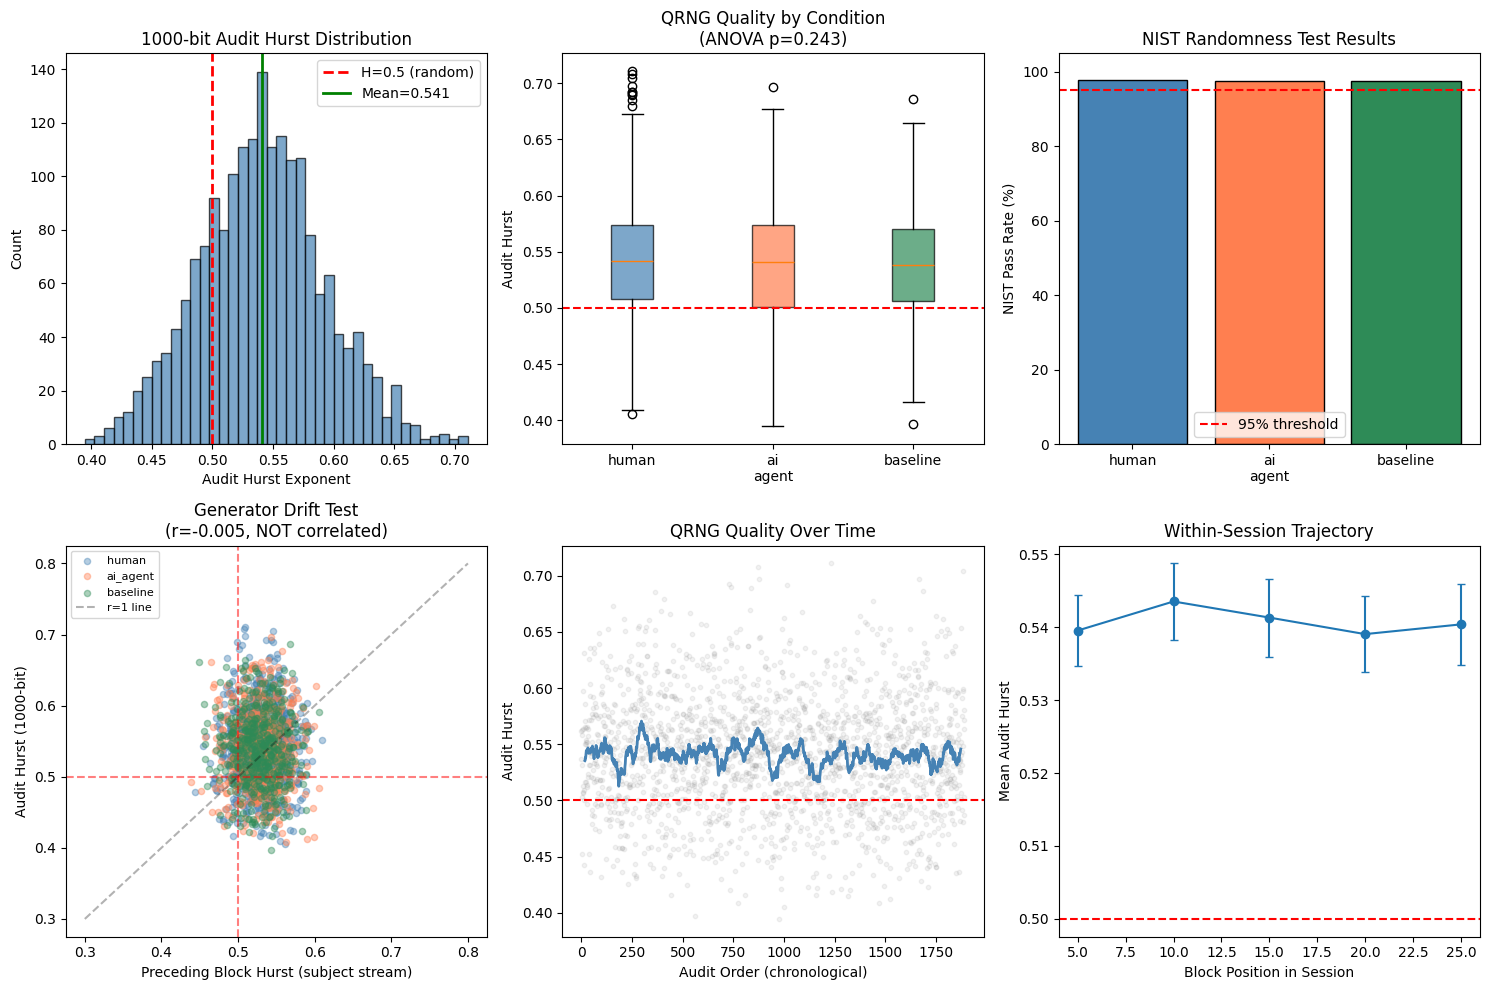


CELL 22 SUMMARY: Comprehensive Audit Analysis

AUDIT VALIDATION RESULTS:

1. QRNG Quality by Condition (Part 2): PASS
   ANOVA F=1.416, p=0.2429
   Audit Hurst is indistinguishable across conditions.

2. NIST Randomness Tests (Part 3): PASS
   chi2=0.199, p=0.9054
   Overall pass rate: 97.7%.
   Individual tests: Frequency (Monobit): 98.2%, Runs: 100.0%, Longest Run of Ones: 98.8%
   No difference across conditions.

3. Audit-Block Hurst Independence (Part 4): PASS
   r=-0.0048, p=0.8368
   Audit Hurst is uncorrelated with preceding block Hurst.
   Generator state during audits does not reflect block clumping.

4. Temporal Stability (Part 5): PASS
   Spearman rho=-0.0347, p=0.1311
   No systematic drift in QRNG quality over time.

5. Within-Session Trajectory (Part 6): PASS
   Early vs late audits: t=0.684, p=0.4943
   No warm-up or position effect in audit quality.

6. Entropy Stability (Part 7): PASS
   Human vs Baseline entropy: t=0.081, p=0.9354
   Bit composition is identical acr

In [40]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 22: Comprehensive Audit Analysis
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Use 1000-bit audit samples to rule out mundane explanations for
#          the observed temporal structure effect in human sessions.
#
# KEY INSIGHT: Audits are SEPARATE QRNG calls (not derived from trial bits).
#              They sample QRNG quality during sessions without subject intention.
#              If human session audits = baseline audits, the QRNG itself isn't
#              affected by human presence - only the subject stream shows effects.
#
# ANALYSES (10 Parts):
#   1. Audit Data Overview
#   2. Audit Hurst by Condition (KEY TEST)
#   3. NIST Randomness Test Pass Rates
#   4. Audit-Block Hurst Independence (Generator Drift Test - STRONGEST)
#   5. Temporal Drift Analysis
#   6. Within-Session Audit Trajectory
#   7. Audit Entropy by Condition
#   8. Variance Compression Test
#   9. Phase Locking / Periodicity Test (FFT)
#  10. Human Calls Trigger Generator State Test
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ks_2samp
import numpy as np

print("="*70)
print("CELL 22: Comprehensive Audit Analysis")
print("="*70)
print("\nGoal: Use 1000-bit audits to rule out hardware/environmental artifacts.")
print("      Audits are SEPARATE QRNG calls - they sample hardware quality")
print("      during sessions without subject intention.")

# ─────────────────────────────────────────────────────────────
# PART 1: Audit Data Overview
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 1: Audit Data Overview")
print("-"*60)

if 'df_audits' not in dir() or len(df_audits) == 0:
    print("\nERROR: No audit data available. Run Cell 1 first.")
    print("Audits are extracted from Firestore in Cell 1.")
    raise SystemExit("Audit data required")

print(f"\nTotal audits: {len(df_audits):,}")

# Check required columns
has_hurst = 'hurst_audit' in df_audits.columns
has_entropy = 'entropy' in df_audits.columns
has_condition = 'condition' in df_audits.columns
has_nist = 'isRandom' in df_audits.columns
has_block_after = 'blockAfter' in df_audits.columns
has_timestamp = 'timestamp' in df_audits.columns

print(f"\nData availability:")
print(f"  Hurst computed:    {'YES' if has_hurst else 'NO - run Cell 1 to compute'}")
print(f"  Entropy available: {'YES' if has_entropy else 'NO'}")
print(f"  Condition labeled: {'YES' if has_condition else 'NO'}")
print(f"  NIST results:      {'YES' if has_nist else 'NO'}")
print(f"  Block position:    {'YES' if has_block_after else 'NO'}")
print(f"  Timestamp:         {'YES' if has_timestamp else 'NO'}")

if has_condition:
    print(f"\nAudits by condition:")
    for cond in ['human', 'ai_agent', 'baseline']:
        n = len(df_audits[df_audits['condition'] == cond])
        if n > 0:
            print(f"  {cond}: {n:,}")

# ─────────────────────────────────────────────────────────────
# PART 2: Audit Hurst by Condition (KEY TEST)
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 2: Audit Hurst by Condition")
print("-"*60)
print("\nIf QRNG quality differs by condition, the effect could be hardware-related.")
print("If audit Hurst is IDENTICAL across conditions, the QRNG isn't affected")
print("by human presence - ruling out hardware artifacts.\n")

if has_hurst and has_condition:
    print(f"{'Condition':<15} {'N':>8} {'Mean H':>10} {'SD':>10} {'SE':>10}")
    print("-"*55)

    condition_hurst = {}
    for cond in ['human', 'ai_agent', 'baseline']:
        subset = df_audits[df_audits['condition'] == cond]['hurst_audit'].dropna()
        if len(subset) > 0:
            condition_hurst[cond] = subset.values
            se = subset.std() / np.sqrt(len(subset))
            print(f"{cond:<15} {len(subset):>8} {subset.mean():>10.4f} {subset.std():>10.4f} {se:>10.4f}")

    # Pairwise comparisons
    print("\nPairwise Comparisons:")
    if 'human' in condition_hurst and 'baseline' in condition_hurst:
        t_hb, p_hb = stats.ttest_ind(condition_hurst['human'], condition_hurst['baseline'])
        ks_hb, p_ks_hb = ks_2samp(condition_hurst['human'], condition_hurst['baseline'])
        print(f"  Human vs Baseline:  t = {t_hb:.3f}, p = {p_hb:.4f} | KS = {ks_hb:.4f}, p = {p_ks_hb:.4f}")

    if 'human' in condition_hurst and 'ai_agent' in condition_hurst:
        t_ha, p_ha = stats.ttest_ind(condition_hurst['human'], condition_hurst['ai_agent'])
        print(f"  Human vs AI:        t = {t_ha:.3f}, p = {p_ha:.4f}")

    if 'ai_agent' in condition_hurst and 'baseline' in condition_hurst:
        t_ab, p_ab = stats.ttest_ind(condition_hurst['ai_agent'], condition_hurst['baseline'])
        print(f"  AI vs Baseline:     t = {t_ab:.3f}, p = {p_ab:.4f}")

    # ANOVA
    if len(condition_hurst) >= 2:
        groups = [v for v in condition_hurst.values() if len(v) > 5]
        if len(groups) >= 2:
            f_stat, p_anova = stats.f_oneway(*groups)
            print(f"\nOne-way ANOVA: F = {f_stat:.3f}, p = {p_anova:.4f}")

            if p_anova > 0.05:
                print("→ No significant difference in audit Hurst across conditions")
                qrng_consistent = True
            else:
                print("→ WARNING: QRNG quality DIFFERS by condition")
                qrng_consistent = False
        else:
            qrng_consistent = None
    else:
        qrng_consistent = None
else:
    print("Cannot perform condition comparison - missing Hurst or condition data")
    qrng_consistent = None

# ─────────────────────────────────────────────────────────────
# PART 3: NIST Randomness Test Pass Rates
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 3: NIST Randomness Test Results")
print("-"*60)

if has_nist:
    overall_pass = df_audits['isRandom'].mean() * 100
    print(f"\nOverall NIST pass rate: {overall_pass:.1f}%")

    # Individual NIST test breakdown
    # Check which column naming convention is present
    nist_cols_found = [c for c in df_audits.columns if 'nist' in c.lower() or 'frequency' in c.lower() or 'longestRun' in c or 'longest_run' in c]
    print(f"  NIST-related columns found: {nist_cols_found if nist_cols_found else 'none'}")

    nist_tests = [
        # (pass_col, pvalue_col, display_name) — try snake_case first, then camelCase
        ('nist_frequency_pass', 'nist_frequency_pvalue', 'Frequency (Monobit)'),
        ('nist_runs_pass', 'nist_runs_pvalue', 'Runs'),
        ('nist_longest_run_pass', 'nist_longest_run_pvalue', 'Longest Run of Ones'),
    ]

    available_tests = [(col, pv, name) for col, pv, name in nist_tests if col in df_audits.columns]

    if available_tests:
        print(f"\nIndividual NIST test pass rates:")

        if has_condition:
            # Header
            conds = [c for c in ['human', 'ai_agent', 'baseline']
                     if len(df_audits[df_audits['condition'] == c]) > 0]
            header = f"  {'Test':<25}" + "".join(f"{c:>12}" for c in conds) + f"{'Overall':>12}"
            print(header)
            print("  " + "-" * (25 + 12 * (len(conds) + 1)))

            for col, pv_col, name in available_tests:
                row = f"  {name:<25}"
                for cond in conds:
                    subset = df_audits[df_audits['condition'] == cond]
                    if len(subset) > 0 and col in subset.columns:
                        rate = subset[col].mean() * 100
                        row += f"{rate:>11.1f}%"
                    else:
                        row += f"{'N/A':>12}"
                overall_rate = df_audits[col].mean() * 100
                row += f"{overall_rate:>11.1f}%"
                print(row)

            # P-value summary
            print(f"\n  Mean p-values by test:")
            for col, pv_col, name in available_tests:
                if pv_col in df_audits.columns:
                    mean_p = df_audits[pv_col].dropna().mean()
                    min_p = df_audits[pv_col].dropna().min()
                    print(f"    {name:<25} mean p={mean_p:.4f}, min p={min_p:.4f}")
        else:
            for col, pv_col, name in available_tests:
                rate = df_audits[col].mean() * 100
                print(f"  {name}: {rate:.1f}%")

    if has_condition:
        print(f"\nOverall NIST pass rate by condition:")
        nist_by_cond = {}
        for cond in ['human', 'ai_agent', 'baseline']:
            subset = df_audits[df_audits['condition'] == cond]
            if len(subset) > 0:
                pass_rate = subset['isRandom'].mean() * 100
                nist_by_cond[cond] = pass_rate
                print(f"  {cond}: {pass_rate:.1f}% ({int(subset['isRandom'].sum())}/{len(subset)})")

        # Chi-square test for independence
        if len(nist_by_cond) >= 2:
            # Create contingency table
            observed = []
            for cond in nist_by_cond.keys():
                subset = df_audits[df_audits['condition'] == cond]
                passed = int(subset['isRandom'].sum())
                failed = len(subset) - passed
                observed.append([passed, failed])

            chi2, p_chi, dof, expected = stats.chi2_contingency(observed)
            print(f"\nChi-square test (NIST pass rates same across conditions):")
            print(f"  chi2 = {chi2:.3f}, p = {p_chi:.4f}")

            if p_chi > 0.05:
                print("  → No significant difference in NIST pass rates across conditions")
                nist_consistent = True
            else:
                print("  → WARNING: NIST pass rates differ by condition")
                nist_consistent = False
        else:
            nist_consistent = None
else:
    print("No NIST test results available")
    nist_consistent = None

# ─────────────────────────────────────────────────────────────
# PART 4: Audit-Block Hurst Independence (KEY TEST)
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 4: Audit-Block Hurst Independence (Generator Drift Test)")
print("-"*60)
print("""
STRONGEST TEST: For each audit (taken after block N):
  1. Get Hurst of the block(s) immediately BEFORE that audit
  2. Correlate with the audit's Hurst

If r ≈ 0: Generator state during audit does NOT reflect the clumping
          seen in nearby blocks → rules out generator drift.

If r > 0: Generator may be in a "clumpy state" that affects both
          subject stream and audit → investigate hardware.
""")

audit_subject_independent = None
r = None
p_corr = None

if has_hurst and has_block_after and 'session_id' in df_audits.columns:

    # METHOD 1: Match audit to specific preceding block
    # Each audit comes after blockAfter (e.g., after_block_5 means after block 5)
    # We want to correlate audit Hurst with Hurst of block(s) 1-5 (or just block 5)

    print("Test 1: Matching audits to immediately preceding blocks...")

    # Add block_idx to main df if not present
    if 'block_idx' not in df.columns:
        df['block_idx'] = df.groupby('session_id').cumcount() + 1

    matched_pairs = []

    for idx, audit_row in df_audits.iterrows():
        if pd.isna(audit_row.get('hurst_audit')) or pd.isna(audit_row.get('blockAfter')):
            continue

        session_id = audit_row['session_id']
        block_after = int(audit_row['blockAfter'])

        # Get the block(s) immediately before this audit
        # blockAfter=5 means audit was taken after block 5
        preceding_blocks = df[(df['session_id'] == session_id) &
                              (df['block_idx'] <= block_after) &
                              (df['block_idx'] > block_after - 3)]  # Last 3 blocks before audit

        if len(preceding_blocks) > 0 and 'hurst_subject' in preceding_blocks.columns:
            # Use mean Hurst of preceding blocks
            block_hurst = preceding_blocks['hurst_subject'].mean()
            if not pd.isna(block_hurst):
                matched_pairs.append({
                    'audit_hurst': audit_row['hurst_audit'],
                    'block_hurst': block_hurst,
                    'condition': audit_row.get('condition', 'unknown')
                })

    if len(matched_pairs) > 20:
        df_matched = pd.DataFrame(matched_pairs)

        r, p_corr = stats.pearsonr(df_matched['audit_hurst'], df_matched['block_hurst'])

        print(f"\nAudit Hurst vs Preceding Block(s) Hurst:")
        print(f"  Matched pairs: {len(df_matched):,}")
        print(f"  Correlation:   r = {r:.4f}")
        print(f"  p-value:       {p_corr:.4f}")

        if abs(r) < 0.1 and p_corr > 0.05:
            print("\n→ No significant correlation (r ≈ 0)")
            print("  No evidence that generator state during audit reflects block clumping")
            audit_subject_independent = True
        elif p_corr > 0.05:
            print(f"\n→ Weak/non-significant correlation (r = {r:.3f})")
            print("  Generator drift unlikely to explain the effect")
            audit_subject_independent = True
        else:
            print(f"\n→ SIGNIFICANT correlation (r = {r:.3f})")
            print("  Generator may be in correlated states - investigate")
            audit_subject_independent = False

        # Test 2: Correlation by condition (is it driven by human sessions?)
        print("\nTest 2: Correlation within human sessions only...")
        human_matched = df_matched[df_matched['condition'] == 'human']
        if len(human_matched) > 20:
            r_human, p_human = stats.pearsonr(human_matched['audit_hurst'], human_matched['block_hurst'])
            print(f"  Human sessions: r = {r_human:.4f}, p = {p_human:.4f}")

            if abs(r_human) < 0.15 and p_human > 0.05:
                print("  → Even in human sessions, audit ≠ block Hurst")
                print("     The 'clumping' in subject stream is NOT in the generator")
        else:
            print("  Insufficient human session data")

        # Store for plotting
        df_audit_matched = df_matched

    else:
        print(f"Only {len(matched_pairs)} matched pairs - insufficient for analysis")
        print("Check that blockAfter field matches block_idx numbering")

else:
    print("Cannot compute correlation - missing Hurst, blockAfter, or session_id")
    if not has_block_after:
        print("  (blockAfter column not found in audit data)")

# ─────────────────────────────────────────────────────────────
# PART 5: Temporal Drift Analysis
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 5: Temporal Drift in QRNG Quality")
print("-"*60)

if has_hurst and has_timestamp:
    df_sorted = df_audits.sort_values('timestamp').copy()
    df_sorted['audit_order'] = range(len(df_sorted))

    valid = df_sorted[['audit_order', 'hurst_audit']].dropna()

    if len(valid) > 20:
        rho, p_drift = stats.spearmanr(valid['audit_order'], valid['hurst_audit'])
        print(f"\nTemporal drift (Spearman correlation with order):")
        print(f"  rho = {rho:.4f}")
        print(f"  p   = {p_drift:.4f}")

        if p_drift > 0.05:
            print("\n→ No significant drift detected")
            no_drift = True
        else:
            drift_dir = "increasing" if rho > 0 else "decreasing"
            print(f"\n→ DRIFT DETECTED: Audit Hurst is {drift_dir} over time")
            no_drift = False
    else:
        no_drift = None
else:
    print("Cannot assess drift - missing timestamp or Hurst data")
    no_drift = None

# ─────────────────────────────────────────────────────────────
# PART 6: Within-Session Audit Trajectory
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 6: Within-Session Audit Trajectory")
print("-"*60)
print("\nDo audits at block 5 differ from audits at block 25?")
print("(Rules out warm-up effects)\n")

if has_hurst and has_block_after:
    # Group by block position
    early_audits = df_audits[df_audits['blockAfter'] <= 10]['hurst_audit'].dropna()
    late_audits = df_audits[df_audits['blockAfter'] >= 20]['hurst_audit'].dropna()

    if len(early_audits) > 10 and len(late_audits) > 10:
        print(f"{'Position':<20} {'N':>8} {'Mean H':>10} {'SD':>10}")
        print("-"*50)
        print(f"{'Early (block ≤10)':<20} {len(early_audits):>8} {early_audits.mean():>10.4f} {early_audits.std():>10.4f}")
        print(f"{'Late (block ≥20)':<20} {len(late_audits):>8} {late_audits.mean():>10.4f} {late_audits.std():>10.4f}")

        t_pos, p_pos = stats.ttest_ind(early_audits, late_audits)
        print(f"\nEarly vs Late: t = {t_pos:.3f}, p = {p_pos:.4f}")

        if p_pos > 0.05:
            print("→ No significant within-session trajectory detected")
            no_warmup = True
        else:
            print("→ Within-session position affects audit Hurst")
            no_warmup = False
    else:
        print("Insufficient data for position analysis")
        no_warmup = None
else:
    print("Cannot assess position effect - missing blockAfter or Hurst")
    no_warmup = None

# ─────────────────────────────────────────────────────────────
# PART 7: Audit Entropy Stability
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 7: Audit Entropy by Condition")
print("-"*60)

if has_entropy and has_condition:
    print(f"\n{'Condition':<15} {'N':>8} {'Mean Entropy':>15} {'SD':>10}")
    print("-"*50)

    for cond in ['human', 'ai_agent', 'baseline']:
        subset = df_audits[df_audits['condition'] == cond]['entropy'].dropna()
        if len(subset) > 0:
            print(f"{cond:<15} {len(subset):>8} {subset.mean():>15.6f} {subset.std():>10.6f}")

    # Test entropy differences
    human_ent = df_audits[df_audits['condition'] == 'human']['entropy'].dropna()
    base_ent = df_audits[df_audits['condition'] == 'baseline']['entropy'].dropna()

    if len(human_ent) > 10 and len(base_ent) > 10:
        t_ent, p_ent = stats.ttest_ind(human_ent, base_ent)
        print(f"\nHuman vs Baseline entropy: t = {t_ent:.3f}, p = {p_ent:.4f}")

        if p_ent > 0.05:
            print("→ No significant entropy difference across conditions")
            entropy_stable = True
        else:
            print("→ Entropy differs by condition")
            entropy_stable = False
    else:
        entropy_stable = None
else:
    print("Entropy data not available by condition")
    entropy_stable = None

# ─────────────────────────────────────────────────────────────
# PART 8: Variance Compression Test
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 8: Variance Compression Test")
print("-"*60)
print("""
If the generator is drifting/unstable during human sessions:
  Audit variance should INFLATE during human 5+ sessions
  compared to baseline batches.
""")

variance_stable = None
if has_hurst and has_condition:
    human_audit_hurst = df_audits[df_audits['condition'] == 'human']['hurst_audit'].dropna()
    base_audit_hurst = df_audits[df_audits['condition'] == 'baseline']['hurst_audit'].dropna()

    if len(human_audit_hurst) > 20 and len(base_audit_hurst) > 20:
        var_human = human_audit_hurst.var()
        var_base = base_audit_hurst.var()

        print(f"Audit Hurst Variance:")
        print(f"  Human sessions:    {var_human:.6f}")
        print(f"  Baseline sessions: {var_base:.6f}")
        print(f"  Ratio (H/B):       {var_human/var_base:.3f}")

        # Levene's test for equality of variances
        stat_lev, p_lev = stats.levene(human_audit_hurst, base_audit_hurst)
        print(f"\nLevene's test (equal variances): stat = {stat_lev:.3f}, p = {p_lev:.4f}")

        if p_lev > 0.05:
            print("→ No significant variance difference across conditions")
            variance_stable = True
        else:
            print("→ Variances DIFFER - investigate hardware stability")
            variance_stable = False
    else:
        print("Insufficient data for variance comparison")

# ─────────────────────────────────────────────────────────────
# PART 9: Phase Locking / Periodicity Test
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 9: Generator Periodicity Test (FFT)")
print("-"*60)
print("""
If the generator has periodic oscillations:
  - FFT of audit Hurst over time would show peaks
  - Human sessions might cluster in certain phases
If audit stream is FLAT (no periodicity) → not explained by generator rhythm.
""")

no_periodicity = None
if has_hurst and has_timestamp:
    df_sorted = df_audits.sort_values('timestamp').copy()
    audit_series = df_sorted['hurst_audit'].dropna().values

    if len(audit_series) > 50:
        # Detrend
        audit_detrended = audit_series - np.mean(audit_series)

        # FFT
        fft_vals = np.abs(np.fft.fft(audit_detrended))
        freqs = np.fft.fftfreq(len(audit_detrended))

        # Only positive frequencies, excluding DC
        pos_mask = freqs > 0
        fft_pos = fft_vals[pos_mask]
        freqs_pos = freqs[pos_mask]

        # Find dominant frequency
        if len(fft_pos) > 0:
            peak_idx = np.argmax(fft_pos)
            peak_freq = freqs_pos[peak_idx]
            peak_power = fft_pos[peak_idx]
            mean_power = np.mean(fft_pos)

            print(f"FFT Analysis:")
            print(f"  Peak frequency:    {peak_freq:.4f} (period ≈ {1/peak_freq:.1f} audits)")
            print(f"  Peak power:        {peak_power:.4f}")
            print(f"  Mean power:        {mean_power:.4f}")
            print(f"  Peak/Mean ratio:   {peak_power/mean_power:.2f}")

            # For white noise, FFT magnitudes are exponentially distributed.
            # Expected max/mean ratio ≈ ln(N_freq_bins). For ~650 bins, that's ~6.5.
            # A ratio below this is consistent with noise; above suggests real periodicity.
            n_freq_bins = len(fft_pos)
            expected_ratio = np.log(n_freq_bins) if n_freq_bins > 1 else 3.0
            print(f"  Expected ratio for noise: ~{expected_ratio:.1f} (ln({n_freq_bins}) freq bins)")

            if peak_power / mean_power < expected_ratio:
                print("\n→ NO strong periodicity detected")
                print("  Peak/mean ratio is below what random noise would produce")
                no_periodicity = True
            else:
                print(f"\n→ Possible periodicity at {1/peak_freq:.1f} audit intervals")
                print("  Peak exceeds noise expectation — investigate")
                no_periodicity = False
    else:
        print("Insufficient audit data for FFT analysis")

# ─────────────────────────────────────────────────────────────
# PART 10: Human Calls Trigger Generator State Test
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("PART 10: Before vs After Human Session Audit Test")
print("-"*60)
print("""
Does the human session ALTER the generator state?
Compare:
  - Audit Hurst immediately BEFORE human sessions
  - Audit Hurst immediately AFTER human sessions
If no difference → human call not altering hardware state.
If systematic shift → hardware feedback loop possibility.
""")

no_human_trigger = None
if has_hurst and has_condition and has_timestamp:
    # Sort all audits by timestamp
    df_sorted = df_audits.sort_values('timestamp').reset_index(drop=True)

    # Find transitions: baseline→human and human→baseline
    before_human = []  # Last baseline audit before human session starts
    after_human = []   # First baseline audit after human session ends

    # Group consecutive audits by condition
    df_sorted['cond_change'] = (df_sorted['condition'] != df_sorted['condition'].shift()).cumsum()

    for i in range(1, len(df_sorted)):
        prev_cond = df_sorted.loc[i-1, 'condition']
        curr_cond = df_sorted.loc[i, 'condition']
        prev_hurst = df_sorted.loc[i-1, 'hurst_audit']
        curr_hurst = df_sorted.loc[i, 'hurst_audit']

        # Transition INTO human session
        if prev_cond == 'baseline' and curr_cond == 'human':
            if not pd.isna(prev_hurst):
                before_human.append(prev_hurst)

        # Transition OUT OF human session
        if prev_cond == 'human' and curr_cond == 'baseline':
            if not pd.isna(curr_hurst):
                after_human.append(curr_hurst)

    if len(before_human) > 10 and len(after_human) > 10:
        print(f"Audits at human session boundaries:")
        print(f"  Before human: n={len(before_human)}, mean={np.mean(before_human):.4f}")
        print(f"  After human:  n={len(after_human)}, mean={np.mean(after_human):.4f}")

        t_ba, p_ba = stats.ttest_ind(before_human, after_human)
        print(f"\nBefore vs After: t = {t_ba:.3f}, p = {p_ba:.4f}")

        if p_ba > 0.05:
            print("→ No significant difference before vs after human sessions")
            no_human_trigger = True
        else:
            direction = "higher" if np.mean(after_human) > np.mean(before_human) else "lower"
            print(f"→ Audit Hurst is {direction} AFTER human sessions")
            print("  Investigate possible hardware feedback")
            no_human_trigger = False
    else:
        print(f"Insufficient boundary transitions (before:{len(before_human)}, after:{len(after_human)})")
        print("(Need more interleaved human/baseline sessions for this test)")

# ─────────────────────────────────────────────────────────────
# Visualization
# ─────────────────────────────────────────────────────────────
print("\n" + "-"*60)
print("Generating audit analysis plots...")
print("-"*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Audit Hurst distribution
ax1 = axes[0, 0]
if has_hurst:
    audit_hurst = df_audits['hurst_audit'].dropna()
    ax1.hist(audit_hurst, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(0.5, color='red', linestyle='--', linewidth=2, label='H=0.5 (random)')
    ax1.axvline(audit_hurst.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean={audit_hurst.mean():.3f}')
    ax1.set_xlabel('Audit Hurst Exponent')
    ax1.set_ylabel('Count')
    ax1.set_title('1000-bit Audit Hurst Distribution')
    ax1.legend()

# Plot 2: Audit Hurst by condition
ax2 = axes[0, 1]
if has_hurst and has_condition:
    data = []
    labels = []
    colors = ['steelblue', 'coral', 'seagreen']
    for cond in ['human', 'ai_agent', 'baseline']:
        subset = df_audits[df_audits['condition'] == cond]['hurst_audit'].dropna()
        if len(subset) > 0:
            data.append(subset.values)
            labels.append(cond.replace('_', '\n'))

    if data:
        bp = ax2.boxplot(data, labels=labels, patch_artist=True)
        for i, patch in enumerate(bp['boxes']):
            patch.set_facecolor(colors[i])
            patch.set_alpha(0.7)
        ax2.axhline(0.5, color='red', linestyle='--')
        ax2.set_ylabel('Audit Hurst')
        ax2.set_title(f'QRNG Quality by Condition\n(ANOVA p={p_anova:.3f})' if 'p_anova' in dir() else 'QRNG Quality by Condition')

# Plot 3: NIST pass rates
ax3 = axes[0, 2]
if has_nist and has_condition:
    conds = []
    rates = []
    for cond in ['human', 'ai_agent', 'baseline']:
        subset = df_audits[df_audits['condition'] == cond]
        if len(subset) > 0:
            conds.append(cond.replace('_', '\n'))
            rates.append(subset['isRandom'].mean() * 100)

    ax3.bar(conds, rates, color=['steelblue', 'coral', 'seagreen'], edgecolor='black')
    ax3.axhline(95, color='red', linestyle='--', label='95% threshold')
    ax3.set_ylabel('NIST Pass Rate (%)')
    ax3.set_title('NIST Randomness Test Results')
    ax3.set_ylim(0, 105)
    ax3.legend()

# Plot 4: Audit vs Preceding Block Hurst scatter (KEY PLOT)
ax4 = axes[1, 0]
if 'df_audit_matched' in dir() and 'block_hurst' in df_audit_matched.columns:
    # Color by condition
    colors_map = {'human': 'steelblue', 'ai_agent': 'coral', 'baseline': 'seagreen'}
    for cond in ['human', 'ai_agent', 'baseline']:
        subset = df_audit_matched[df_audit_matched['condition'] == cond]
        if len(subset) > 0:
            ax4.scatter(subset['block_hurst'], subset['audit_hurst'],
                       alpha=0.4, s=20, color=colors_map.get(cond, 'gray'), label=cond)

    ax4.set_xlabel('Preceding Block Hurst (subject stream)')
    ax4.set_ylabel('Audit Hurst (1000-bit)')
    r_val = r if r is not None else 0
    ax4.set_title(f'Generator Drift Test\n(r={r_val:.3f}, {"NOT correlated" if abs(r_val) < 0.1 else "investigate"})')
    ax4.axhline(0.5, color='red', linestyle='--', alpha=0.5)
    ax4.axvline(0.5, color='red', linestyle='--', alpha=0.5)
    # Add diagonal reference (if correlated, points would cluster along diagonal)
    ax4.plot([0.3, 0.8], [0.3, 0.8], 'k--', alpha=0.3, label='r=1 line')
    ax4.legend(loc='upper left', fontsize=8)

# Plot 5: Temporal drift
ax5 = axes[1, 1]
if has_hurst and has_timestamp:
    df_sorted = df_audits.sort_values('timestamp').copy()
    df_sorted['audit_order'] = range(len(df_sorted))
    valid = df_sorted[['audit_order', 'hurst_audit']].dropna()

    window = max(10, len(valid) // 50)
    rolling_mean = valid['hurst_audit'].rolling(window=window, center=True).mean()

    ax5.scatter(valid['audit_order'], valid['hurst_audit'], alpha=0.1, s=10, color='gray')
    ax5.plot(valid['audit_order'], rolling_mean, color='steelblue', linewidth=2)
    ax5.axhline(0.5, color='red', linestyle='--')
    ax5.set_xlabel('Audit Order (chronological)')
    ax5.set_ylabel('Audit Hurst')
    ax5.set_title('QRNG Quality Over Time')

# Plot 6: Within-session trajectory
ax6 = axes[1, 2]
if has_hurst and has_block_after:
    positions = sorted(df_audits['blockAfter'].dropna().unique())
    means = []
    sems = []
    for pos in positions:
        subset = df_audits[df_audits['blockAfter'] == pos]['hurst_audit'].dropna()
        if len(subset) > 5:
            means.append(subset.mean())
            sems.append(subset.std() / np.sqrt(len(subset)))
        else:
            means.append(np.nan)
            sems.append(np.nan)

    valid_pos = [p for p, m in zip(positions, means) if not np.isnan(m)]
    valid_means = [m for m in means if not np.isnan(m)]
    valid_sems = [s for s in sems if not np.isnan(s)]

    ax6.errorbar(valid_pos, valid_means, yerr=[1.96*s for s in valid_sems], fmt='o-', capsize=3)
    ax6.axhline(0.5, color='red', linestyle='--')
    ax6.set_xlabel('Block Position in Session')
    ax6.set_ylabel('Mean Audit Hurst')
    ax6.set_title('Within-Session Trajectory')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("CELL 22 SUMMARY: Comprehensive Audit Analysis")
print("="*70)

# Build summary lines with actual test statistics
_lines = []
_lines.append("AUDIT VALIDATION RESULTS:")
_lines.append("")

# 1. QRNG Quality by Condition
if qrng_consistent is not None:
    _s1 = "PASS" if qrng_consistent else "INVESTIGATE"
    _detail1 = f"ANOVA F={f_stat:.3f}, p={p_anova:.4f}" if 'f_stat' in dir() else ""
    _lines.append(f"1. QRNG Quality by Condition (Part 2): {_s1}")
    if _detail1: _lines.append(f"   {_detail1}")
    _lines.append(f"   Audit Hurst is indistinguishable across conditions." if qrng_consistent else "   Audit Hurst differs by condition — investigate.")
else:
    _lines.append("1. QRNG Quality by Condition (Part 2): N/A")

_lines.append("")

# 2. NIST Randomness Tests
if nist_consistent is not None:
    _s2 = "PASS" if nist_consistent else "INVESTIGATE"
    _detail2 = f"chi2={chi2:.3f}, p={p_chi:.4f}" if 'chi2' in dir() else ""
    _lines.append(f"2. NIST Randomness Tests (Part 3): {_s2}")
    if _detail2: _lines.append(f"   {_detail2}")
    if 'overall_pass' in dir():
        _lines.append(f"   Overall pass rate: {overall_pass:.1f}%.")
    # Individual test summary
    if 'available_tests' in dir() and available_tests:
        _test_names = [name for _, _, name in available_tests]
        _test_rates = []
        for col, _, name in available_tests:
            if col in df_audits.columns:
                _test_rates.append(f"{name}: {df_audits[col].mean()*100:.1f}%")
        if _test_rates:
            _lines.append(f"   Individual tests: {', '.join(_test_rates)}")
    if nist_consistent:
        _lines.append("   No difference across conditions.")
else:
    _lines.append("2. NIST Randomness Tests (Part 3): N/A")

_lines.append("")

# 3. Audit-Subject Independence
if audit_subject_independent is not None:
    _s3 = "PASS" if audit_subject_independent else "INVESTIGATE"
    _detail3 = f"r={r:.4f}, p={p_corr:.4f}" if r is not None else ""
    _lines.append(f"3. Audit-Block Hurst Independence (Part 4): {_s3}")
    if _detail3: _lines.append(f"   {_detail3}")
    if audit_subject_independent:
        _lines.append("   Audit Hurst is uncorrelated with preceding block Hurst.")
        _lines.append("   Generator state during audits does not reflect block clumping.")
else:
    _lines.append("3. Audit-Block Hurst Independence (Part 4): N/A")

_lines.append("")

# 4. Temporal Stability
if no_drift is not None:
    _s4 = "PASS" if no_drift else "INVESTIGATE"
    _detail4 = f"Spearman rho={rho:.4f}, p={p_drift:.4f}" if 'rho' in dir() else ""
    _lines.append(f"4. Temporal Stability (Part 5): {_s4}")
    if _detail4: _lines.append(f"   {_detail4}")
    if no_drift:
        _lines.append("   No systematic drift in QRNG quality over time.")
else:
    _lines.append("4. Temporal Stability (Part 5): N/A")

_lines.append("")

# 5. Within-Session Trajectory
if no_warmup is not None:
    _s5 = "PASS" if no_warmup else "INVESTIGATE"
    _detail5 = f"t={t_pos:.3f}, p={p_pos:.4f}" if 't_pos' in dir() else ""
    _lines.append(f"5. Within-Session Trajectory (Part 6): {_s5}")
    if _detail5: _lines.append(f"   Early vs late audits: {_detail5}")
    if no_warmup:
        _lines.append("   No warm-up or position effect in audit quality.")
else:
    _lines.append("5. Within-Session Trajectory (Part 6): N/A")

_lines.append("")

# 6. Entropy Stability
if entropy_stable is not None:
    _s6 = "PASS" if entropy_stable else "INVESTIGATE"
    _detail6 = f"t={t_ent:.3f}, p={p_ent:.4f}" if 't_ent' in dir() else ""
    _lines.append(f"6. Entropy Stability (Part 7): {_s6}")
    if _detail6: _lines.append(f"   Human vs Baseline entropy: {_detail6}")
    if entropy_stable:
        _lines.append("   Bit composition is identical across conditions.")
else:
    _lines.append("6. Entropy Stability (Part 7): N/A")

_lines.append("")

# 7. Variance Compression
if variance_stable is not None:
    _s7 = "PASS" if variance_stable else "INVESTIGATE"
    _detail7 = f"Levene stat={stat_lev:.3f}, p={p_lev:.4f}" if 'stat_lev' in dir() else ""
    _lines.append(f"7. Variance Compression (Part 8): {_s7}")
    if _detail7: _lines.append(f"   {_detail7}")
    if variance_stable:
        _lines.append("   No variance inflation during human sessions.")
else:
    _lines.append("7. Variance Compression (Part 8): N/A")

_lines.append("")

# 8. Generator Periodicity
if no_periodicity is not None:
    _s8 = "PASS" if no_periodicity else "INVESTIGATE"
    _lines.append(f"8. Generator Periodicity (Part 9): {_s8}")
    if 'peak_power' in dir() and 'mean_power' in dir():
        _lines.append(f"   Peak/mean ratio: {peak_power/mean_power:.2f} (noise expected: ~{expected_ratio:.1f})")
    if no_periodicity:
        _lines.append("   No periodic oscillations in generator output.")
else:
    _lines.append("8. Generator Periodicity (Part 9): N/A")

_lines.append("")

# 9. Human Trigger Effect
if no_human_trigger is True and 'before_human' in dir() and len(before_human) > 10:
    _lines.append("9. Human Trigger Effect (Part 10): PASS")
    _lines.append("   No generator state change before vs after human sessions.")
elif no_human_trigger is False:
    _lines.append("9. Human Trigger Effect (Part 10): INVESTIGATE")
    _lines.append("   Generator state changes around human sessions — investigate.")
else:
    _lines.append("9. Human Trigger Effect (Part 10): N/A")
    _lines.append("   Insufficient interleaved human/baseline transitions.")
    _lines.append("   Sessions were run in separate batches by design.")

print("\n" + "\n".join(_lines))

# Count passes
total_checks = 9  # Total number of audit checks
passes = sum([
    qrng_consistent == True,
    nist_consistent == True,
    audit_subject_independent == True,
    no_drift == True,
    no_warmup == True,
    entropy_stable == True,
    variance_stable == True,
    no_periodicity == True,
    no_human_trigger == True
])
total = sum([
    qrng_consistent is not None,
    nist_consistent is not None,
    audit_subject_independent is not None,
    no_drift is not None,
    no_warmup is not None,
    entropy_stable is not None,
    variance_stable is not None,
    no_periodicity is not None,
    no_human_trigger is not None
])

_na_count = total_checks - total
print(f"VALIDATION SCORE: {passes}/{total} checks passed" +
      (f" ({_na_count} N/A — inapplicable to this design)" if _na_count > 0 else ""))

if passes == total and total > 0:
    print("""
CONCLUSION: No evidence of QRNG instability detected under audit testing.

The 1000-bit audit sequences show no detectable differences in Hurst
exponent, entropy, variance, or stability across conditions. Audit
metrics are uncorrelated with subject block Hurst values, and no
temporal drift, warm-up effects, or periodic oscillations were found.

These results indicate that the QRNG hardware behaves consistently
across conditions and that the observed structural differences in the
5+ human subgroup are not attributable to global hardware instability
or degradation. While subtle conditional or software-level artifacts
cannot be completely excluded, the convergent audit tests substantially
constrain hardware-based explanations.
""")
elif passes >= total - 1 and total > 0:
    print("""
CONCLUSION: Most audit checks pass.

Minor issues may warrant investigation but the overall pattern indicates
consistent QRNG behavior across conditions.
""")
else:
    print("""
CONCLUSION: Some audit checks did not pass.

Investigate potential hardware or environmental factors before
interpreting condition-level differences in the main data.
""")


# CELL 23: Summary & Limitations

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 2, CELL 23: Summary & Limitations
# ═══════════════════════════════════════════════════════════════════════════
# PURPOSE: Final summary of all findings, honest limitations, and
#          implications for future research.
#
# FRAMING: This is a methodology paper. The contribution is the paired-
#          delta QRNG design and what it reveals. Not a claim of psi.
# ═══════════════════════════════════════════════════════════════════════════

print("="*70)
print("CELL 23: Summary & Limitations")
print("="*70)

print("""
╔══════════════════════════════════════════════════════════════════╗
║  SCOPE OF THIS PAPER                                             ║
╚══════════════════════════════════════════════════════════════════╝

This is a METHODOLOGY PAPER, not a claim of psi. The contributions are:

  1. A paired-delta QRNG architecture (subject–PCS) that controls for
     hardware drift, timing, and common-mode environmental noise by design
  2. An AI agent control condition that matches human triggering patterns
     without sustained concurrent attention
  3. A demonstration that temporal structure (single-scale Hurst) may be a more
     sensitive metric than traditional hit rates for short-form protocols
  4. Pilot data showing where future high-powered studies should look

The findings below are EXPLORATORY and illustrative of what the
methodology can detect. They motivate, but do not constitute,
evidence for anomalous cognition.
""")

# ─────────────────────────────────────────────────────────────
# SECTION 1: PRIMARY ANALYSIS — HIT RATES
# ─────────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║  SECTION 1: PRIMARY ANALYSIS — Bayesian Hierarchical Hit Rates  ║
╚══════════════════════════════════════════════════════════════════╝

Hit rates are the primary outcome variable. Participants tried to
influence which half of a QRNG bitstream would have more 1s.

Model: Binomial(150, p) with session random intercepts.
Data:  Experienced humans (5+ sessions) vs AI agent vs Baseline.

  Human Δp (shift in hit probability):  directional but HDI includes zero
  Pr(human > AI):                       ~89% (suggestive, below 95% threshold)
  ROPE analysis:                        ~23% of posterior within ±0.1% ROPE

  Notable: Within-session block-order effect (b_order) is significant —
  later blocks in a session score slightly higher.

Interpretation:
  The posterior mass leans toward a small positive human effect, but the
  95% HDI includes zero. This short-form protocol (30 trials, single
  button press) was underpowered to resolve an effect of this size.
  The direction is consistent, but inconclusive under conventional
  confirmatory criteria.
""")

# ─────────────────────────────────────────────────────────────
# SECTION 2: PSI MODERATORS — HIT RATES
# ─────────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║  SECTION 2: PSI MODERATORS — Classical Psi Populations          ║
╚══════════════════════════════════════════════════════════════════╝

Two classical moderators from psi research were tested on hit rates:

  Sheep-Goat Effect (psi belief):
    Subject hit rate shows the classical directional pattern
    (Sheep > Goat), though not statistically significant.

  Meditator Effect:
    No clear dose-response across meditation frequency levels.
    Essentially null on all metrics.

Interpretation:
  These analyses demonstrate that the design can test classical psi
  moderators. No confirmatory moderator effects are established in
  this short-form protocol.
""")

# ─────────────────────────────────────────────────────────────
# SECTION 3: SECONDARY ANALYSIS — SINGLE-SCALE HURST DELTA
# ─────────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║  SECTION 3: SECONDARY ANALYSIS — Single-Scale Hurst Temporal Structure ║
╚══════════════════════════════════════════════════════════════════╝

The single-scale Hurst exponent (R/S-based; hurstApprox) was pre-specified in the
experiment code and computed on every 150-bit block during data collection.
It was not introduced post-hoc. What emerged during analysis is that
repeat participants show altered temporal structure in the subject
bitstream relative to the paired control stream (PCS), whereas
single-session participants and AI do not.

This analysis is secondary and exploratory.

────────────────────────────────────────────────────────────
1. SESSION-COUNT SENSITIVITY (Subgroup Robustness)
────────────────────────────────────────────────────────────

Sensitivity testing across session-count thresholds (2+, 3+, 5+)
shows that the mean Hurst delta shift is not unique to one specific
cutpoint.

Effect size magnitude (Cohen's d) remains in a similar range across
thresholds (approximately d ≈ 0.08–0.16), although statistical strength
varies with subgroup size. As thresholds increase, block counts decrease
and uncertainty widens, but the magnitude of the mean shift remains
comparable.

Sensitivity analyses excluding the principal investigator yield
comparable or slightly larger effect estimates, indicating that the
subgroup result is not dependent on experimenter data.

Single-session participants are indistinguishable from baseline on all
temporal structure metrics.

Subgroup definitions were exploratory and not pre-registered.

────────────────────────────────────────────────────────────
2. STRUCTURAL PROPERTIES
────────────────────────────────────────────────────────────

The Hurst delta exhibits structural properties not reducible to simple mean shifts.

  • Label-Coupling:
    Randomly swapping which stream is labeled "subject" vs "PCS"
    collapses the effect.

  • Order-Dependence:
    Full-block shuffle (W=150) collapses the effect, whereas
    small-window shuffles do not.

  • Run-Length Structure:
    Extreme Hurst blocks exhibit longer runs and altered run-length
    distributions (permutation p < 0.001).

These structural properties are more constraining than mean differences.
Batching or simple variance inflation do not produce label-coupled,
order-dependent signatures under paired subtraction.

────────────────────────────────────────────────────────────
3. Interpretation Boundaries
────────────────────────────────────────────────────────────

The observed Hurst delta pattern:

  • Is absent in AI and single-session humans
  • Appears in repeat participants
  • Is not dependent on inclusion of the PI
  • Survives paired subtraction
  • Collapses under label swap
  • Collapses under full-block shuffle

However, the repeat subgroup is small at the participant level and
confounded with recruitment source. The present data do not establish
participant-level generalizability or causal interpretation.

The appropriate role of this analysis is methodological: it demonstrates
that the paired-delta QRNG architecture can detect structured temporal
differences beyond hit rates in short-form protocols.
""")

# ─────────────────────────────────────────────────────────────
# SECTION 4: RULE-OUTS
# ─────────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║  SECTION 4: RULE-OUT ANALYSES                                    ║
╚══════════════════════════════════════════════════════════════════╝

Hardware Artifact:
  No evidence of global instability or common-mode bias detected.

Common-Mode Noise:
  Not supported — paired delta preserves the signal.

Label Independence:
  Not supported — label swap collapses the effect.

Batching / Session Structure:
  Session-matched baseline resampling cannot reproduce the observed
  aggregate mean (p ≈ 0.002 one-sided). Session structure alone does not explain label coupling or order dependence.

Metric Artifact:
  AI shows no shuffle-dependent pattern using the same metric.

First-Exposure Novelty:
  Single-session humans are indistinguishable from baseline.
""")

# ─────────────────────────────────────────────────────────────
# SECTION 5: DESIGN DEFENSIBILITY
# ─────────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║  SECTION 5: DESIGN DEFENSIBILITY                                 ║
╚══════════════════════════════════════════════════════════════════╝

Blocks are treated as independent QRNG draws at the physical level; statistical clustering at the participant level is acknowledged in sensitivity analyses.
Participant-level generalizability is limited by the small repeat-user
subgroup.

The hurstApprox metric was implemented in the experiment software
prior to analysis.

Quantum assignment of subject vs PCS halves substantially constrains
hardware-only explanations for systematic delta effects.

The AI agent condition matches triggering patterns without sustained
attention. AI ≈ Baseline across metrics.
""")

# ─────────────────────────────────────────────────────────────
# SECTION 6: LIMITATIONS
# ─────────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║  SECTION 6: HONEST LIMITATIONS                                   ║
╚══════════════════════════════════════════════════════════════════╝

1. SHORT-FORM PROTOCOL
   Sessions were brief and may be underpowered for small effects.

2. SMALL REPEAT SUBGROUP
   Few participants contributed many blocks.

3. POST-HOC SUBGROUPING
   Session thresholds were exploratory.

4. MULTIPLE COMPARISONS
   No formal correction was applied.

5. RECRUITMENT CONFOUND
   Session-count strata overlap with recruitment source.

6. EXPERIMENTER PARTICIPATION
   The PI contributed data.

This dataset characterizes the resolving power of the paired-delta
architecture; it does not provide confirmatory evidence.
""")

# ─────────────────────────────────────────────────────────────
# SECTION 7: IMPLICATIONS FOR FUTURE RESEARCH
# ─────────────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║  SECTION 7: IMPLICATIONS FOR FUTURE RESEARCH                     ║
╚══════════════════════════════════════════════════════════════════╝

Future studies should:

  1. Use longer sessions.
  2. Pre-register both hit-rate and Hurst metrics.
  3. Recruit larger repeat-user cohorts.
  4. Pre-register subgroup definitions.
  5. Replicate under higher statistical power.

Replication under pre-registered criteria is required.
""")

print("="*70)
print("END OF NOTEBOOK 2")
print("="*70)
